In [ ]:
# ============================================
# 1. SEMANTIC POST-PROCESSING — GENAI ONLY
# ============================================

import pandas as pd
import re
import unicodedata
from pathlib import Path

# --------------------------------------------
# CONFIG
# --------------------------------------------
INPUT_FILE = "treatment_partial.csv"
OUTPUT_FILE = "openalex_semantic_classified_v2.csv"
SUMMARY_FILE = "semantic_classification_summary_v2.csv"

# November 2022 is treated as the final pre-intervention month.
# December 2022 is the first complete post-intervention month.
FIRST_POST_DATE = pd.Timestamp("2022-12-01")

# --------------------------------------------
# TEXT HELPERS
# --------------------------------------------
def strip_accents(text: str) -> str:
    """Remove accents while preserving the underlying characters."""
    if pd.isna(text):
        return ""

    return "".join(
        character
        for character in unicodedata.normalize("NFKD", str(text))
        if not unicodedata.combining(character)
    )


def normalize_text(text: str) -> str:
    """Normalize text for rule-based semantic classification."""
    text = strip_accents(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\-\./]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def safe_text(value) -> str:
    """Convert missing values to empty strings."""
    if pd.isna(value):
        return ""

    return str(value).strip()


def combine_text(row: pd.Series) -> str:
    """
    Combine textual metadata while avoiding duplication when
    title and display_name contain the same normalized text.
    """
    title = safe_text(row.get("title", ""))
    display_name = safe_text(row.get("display_name", ""))

    title_normalized = normalize_text(title)
    display_name_normalized = normalize_text(display_name)

    parts = []

    if title_normalized:
        parts.append(title)

    if (
        display_name_normalized
        and display_name_normalized != title_normalized
    ):
        parts.append(display_name)

    parts.extend(
        [
            safe_text(row.get("abstract", "")),
            safe_text(row.get("keywords", "")),
            safe_text(row.get("concepts", "")),
            safe_text(row.get("topics", "")),
            safe_text(row.get("fields", "")),
        ]
    )

    return normalize_text(" ".join(parts))


# --------------------------------------------
# GenAI REGEX RULES
# --------------------------------------------

# High-specificity lexical dictionary.
GENAI_STRICT_PATTERNS = [
    r"\bchatgpt\b",
    r"\blarge language model\b",
    r"\blarge language models\b",
    r"\bfoundation model\b",
    r"\bfoundation models\b",
    r"\bgenerative artificial intelligence\b",
]

# Expanded lexical dictionary.
GENAI_BROAD_PATTERNS = GENAI_STRICT_PATTERNS + [
    r"\bgenerative ai\b",
    r"\bllm\b",
    r"\bllms\b",
    r"\bgpt[- ]?3(?:\.5)?\b",
    r"\bgpt[- ]?4\b",
    r"\bgpt[- ]?4o\b",
    r"\btransformer\b",
    r"\btransformers\b",
    r"\bretrieval[- ]augmented generation\b",
    r"\brag\b",
    r"\bfine[- ]tuning\b",
    r"\binstruction tuning\b",
    r"\bpredictive prompting\b",
    r"\bprompt engineering\b",
]

# These terms override a possible legal-context ambiguity.
UNAMBIGUOUS_GENAI_PATTERNS = [
    r"\bchatgpt\b",
    r"\bgenerative ai\b",
    r"\bgenerative artificial intelligence\b",
    r"\blarge language model\b",
    r"\blarge language models\b",
    r"\bfoundation model\b",
    r"\bfoundation models\b",
    r"\bgpt[- ]?3(?:\.5)?\b",
    r"\bgpt[- ]?4\b",
    r"\bgpt[- ]?4o\b",
    r"\bretrieval[- ]augmented generation\b",
    r"\bprompt engineering\b",
]

LEGAL_CONTEXT_PATTERNS = [
    r"\bmaster of laws\b",
    r"\blegal studies\b",
]

LLM_ACRONYM_PATTERN = r"\bllms?\b"


def count_pattern_hits(text: str, patterns: list[str]) -> int:
    """
    Count matched regex rules.

    Repeated occurrences of the same term still count as one hit.
    """
    return sum(
        bool(re.search(pattern, text))
        for pattern in patterns
    )


def has_any(text: str, patterns: list[str]) -> bool:
    """Return True when at least one pattern is present."""
    return any(
        re.search(pattern, text)
        for pattern in patterns
    )


def identify_ambiguous_legal_llm(text: str) -> bool:
    """
    Exclude only ambiguous uses of LLM in a legal context.

    Exclusion requires all three conditions:
    1. LLM or LLMs appears;
    2. a legal-context expression appears;
    3. no unambiguous GenAI expression appears.
    """
    text = "" if pd.isna(text) else str(text)

    has_llm_acronym = bool(
        re.search(LLM_ACRONYM_PATTERN, text)
    )

    has_legal_context = has_any(
        text,
        LEGAL_CONTEXT_PATTERNS
    )

    has_unambiguous_genai = has_any(
        text,
        UNAMBIGUOUS_GENAI_PATTERNS
    )

    return (
        has_llm_acronym
        and has_legal_context
        and not has_unambiguous_genai
    )


# --------------------------------------------
# LOAD DATA
# --------------------------------------------
input_path = Path(INPUT_FILE)

if not input_path.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo: {INPUT_FILE}"
    )

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

print(f"Registros cargados: {len(df):,}")

# --------------------------------------------
# DEDUPLICATION
# --------------------------------------------
if "openalex_id" in df.columns:
    duplicated_records = df["openalex_id"].duplicated(
        keep="first"
    ).sum()

    df = (
        df.drop_duplicates(
            subset=["openalex_id"],
            keep="first"
        )
        .copy()
    )

    print(
        "Duplicados eliminados por openalex_id: "
        f"{duplicated_records:,}"
    )
else:
    print(
        "Advertencia: no se encontró la columna openalex_id."
    )

print(
    "Registros después de la deduplicación: "
    f"{len(df):,}"
)

# --------------------------------------------
# CONSOLIDATED TEXT
# --------------------------------------------
df["text_full"] = df.apply(
    combine_text,
    axis=1
)

# --------------------------------------------
# CONTEXTUAL LEGAL EXCLUSION
# --------------------------------------------
df["has_exclusion"] = df["text_full"].apply(
    identify_ambiguous_legal_llm
)

# --------------------------------------------
# SEMANTIC CLASSIFICATION
# --------------------------------------------
df["genai_hits_strict"] = df["text_full"].apply(
    lambda text: count_pattern_hits(
        text,
        GENAI_STRICT_PATTERNS
    )
)

df["genai_hits_broad"] = df["text_full"].apply(
    lambda text: count_pattern_hits(
        text,
        GENAI_BROAD_PATTERNS
    )
)

df["is_genai_strict"] = (
    (df["genai_hits_strict"] >= 1)
    & (~df["has_exclusion"])
)

# Broad requires at least two distinct patterns unless the record
# explicitly mentions ChatGPT or large language model(s).
explicit_broad_override = df["text_full"].str.contains(
    r"\bchatgpt\b|\blarge language models?\b",
    regex=True,
    na=False,
)

df["is_genai_broad"] = (
    (
        (df["genai_hits_broad"] >= 2)
        | explicit_broad_override
    )
    & (~df["has_exclusion"])
)

# --------------------------------------------
# MUTUALLY EXCLUSIVE FINAL LABEL
# --------------------------------------------
def assign_semantic_label(row: pd.Series) -> str:
    if bool(row["is_genai_strict"]):
        return "treatment_strict"

    if bool(row["is_genai_broad"]):
        return "treatment_broad"

    return "other"


df["semantic_label"] = df.apply(
    assign_semantic_label,
    axis=1
)

# --------------------------------------------
# TEMPORAL VARIABLES
# --------------------------------------------
df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce",
)

df["publication_month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df["post_chatgpt"] = (
    df["publication_month"] >= FIRST_POST_DATE
).astype("Int64")

# --------------------------------------------
# SUMMARY
# --------------------------------------------
classification_summary = (
    df["semantic_label"]
    .value_counts(dropna=False)
    .rename_axis("semantic_label")
    .reset_index(name="n")
)

classification_summary["percentage"] = (
    classification_summary["n"]
    / len(df)
    * 100
)

classification_summary.to_csv(
    SUMMARY_FILE,
    index=False,
)

print("\n=== CLASIFICACIÓN SEMÁNTICA REVISADA ===")

print("\nConteos por etiqueta:")
print(
    df["semantic_label"]
    .value_counts(dropna=False)
)

print("\nPorcentajes por etiqueta:")
print(
    df["semantic_label"]
    .value_counts(
        normalize=True,
        dropna=False,
    )
    .mul(100)
    .round(4)
)

print("\nIndicadores GenAI:")
print(
    df[
        [
            "is_genai_strict",
            "is_genai_broad",
        ]
    ].sum()
)

print(
    "\nExclusiones jurídicas contextuales: "
    f"{int(df['has_exclusion'].sum()):,}"
)

print(
    "Fechas de publicación no válidas o ausentes: "
    f"{int(df['publication_date'].isna().sum()):,}"
)

# --------------------------------------------
# SAVE
# --------------------------------------------
df.to_csv(
    OUTPUT_FILE,
    index=False,
)

print("\nArchivos guardados:")
print(f"- {OUTPUT_FILE}")
print(f"- {SUMMARY_FILE}")

Registros cargados: 487,753
Duplicados eliminados por openalex_id: 0
Registros después de la deduplicación: 487,753

=== CLASIFICACIÓN SEMÁNTICA REVISADA ===

Conteos por etiqueta:
semantic_label
other               338956
treatment_strict    139272
treatment_broad       9525
Name: count, dtype: int64

Porcentajes por etiqueta:
semantic_label
other               69.4934
treatment_strict    28.5538
treatment_broad      1.9528
Name: proportion, dtype: float64

Indicadores GenAI:
is_genai_strict    139272
is_genai_broad     137060
dtype: int64

Exclusiones jurídicas contextuales: 26
Fechas de publicación no válidas o ausentes: 0

Archivos guardados:
- openalex_semantic_classified_v2.csv
- semantic_classification_summary_v2.csv


In [ ]:
# ============================================================
# AUDITORÍA DEL UNIVERSO DE REGISTROS
# Objetivo: explicar la diferencia entre 487,753 y 452,988
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

INPUT_FILE = "treatment_partial.csv"
OUTPUT_SUMMARY = "corpus_audit_summary.csv"
OUTPUT_TYPES = "corpus_audit_types.csv"
OUTPUT_DATE = "corpus_audit_date.csv"

START_DATE = pd.Timestamp("2019-08-02")
END_DATE = pd.Timestamp("2026-03-30")

df_audit = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

print("=== AUDITORÍA DEL CORPUS ===")
print(f"Registros iniciales: {len(df_audit):,}")

# ------------------------------------------------------------
# 1. COLUMNAS DISPONIBLES
# ------------------------------------------------------------
print("\nColumnas disponibles:")
print(df_audit.columns.tolist())

# ------------------------------------------------------------
# 2. DUPLICADOS
# ------------------------------------------------------------
duplicate_openalex = np.nan
duplicate_doi = np.nan

if "openalex_id" in df_audit.columns:
    duplicate_openalex = int(
        df_audit["openalex_id"]
        .duplicated(keep="first")
        .sum()
    )

if "doi" in df_audit.columns:
    doi_normalized = (
        df_audit["doi"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"^https?://(?:dx\.)?doi\.org/",
            "",
            regex=True
        )
    )

    valid_doi = doi_normalized.ne("")

    duplicate_doi = int(
        doi_normalized.loc[valid_doi]
        .duplicated(keep="first")
        .sum()
    )

print("\nDuplicados:")
print(f"- Por openalex_id: {duplicate_openalex:,}")
print(f"- Por DOI no vacío: {duplicate_doi:,}")

# ------------------------------------------------------------
# 3. FECHAS
# ------------------------------------------------------------
if "publication_date" not in df_audit.columns:
    raise ValueError(
        "No existe la columna publication_date."
    )

df_audit["publication_date_parsed"] = pd.to_datetime(
    df_audit["publication_date"],
    errors="coerce"
)

missing_dates = int(
    df_audit["publication_date_parsed"].isna().sum()
)

before_start = int(
    (
        df_audit["publication_date_parsed"] < START_DATE
    ).sum()
)

after_end = int(
    (
        df_audit["publication_date_parsed"] > END_DATE
    ).sum()
)

within_period = (
    df_audit["publication_date_parsed"]
    .between(
        START_DATE,
        END_DATE,
        inclusive="both"
    )
)

print("\nFechas:")
print(f"- Fechas ausentes o inválidas: {missing_dates:,}")
print(f"- Antes de {START_DATE.date()}: {before_start:,}")
print(f"- Después de {END_DATE.date()}: {after_end:,}")
print(
    f"- Dentro del periodo: "
    f"{int(within_period.sum()):,}"
)

# ------------------------------------------------------------
# 4. TIPOS DOCUMENTALES
# ------------------------------------------------------------
possible_type_columns = [
    "type",
    "work_type",
    "document_type",
    "publication_type",
    "type_crossref",
]

type_column = next(
    (
        column
        for column in possible_type_columns
        if column in df_audit.columns
    ),
    None
)

if type_column:
    type_summary = (
        df_audit[type_column]
        .fillna("[missing]")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis(type_column)
        .reset_index(name="n")
    )

    type_summary["percentage"] = (
        type_summary["n"]
        / len(df_audit)
        * 100
    )

    print(
        f"\nTipos documentales según '{type_column}':"
    )
    print(type_summary.to_string(index=False))

    type_summary.to_csv(
        OUTPUT_TYPES,
        index=False
    )
else:
    type_summary = pd.DataFrame()
    print(
        "\nNo se identificó automáticamente una "
        "columna de tipo documental."
    )

# ------------------------------------------------------------
# 5. RETRACCIONES Y PARATEXTOS
# ------------------------------------------------------------
possible_retraction_columns = [
    "is_retracted",
    "retracted",
]

retraction_column = next(
    (
        column
        for column in possible_retraction_columns
        if column in df_audit.columns
    ),
    None
)

retracted_count = np.nan

if retraction_column:
    retracted_values = (
        df_audit[retraction_column]
        .fillna(False)
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )

    retracted_count = int(
        retracted_values.sum()
    )

    print(
        f"\nRegistros retraídos según "
        f"'{retraction_column}': "
        f"{retracted_count:,}"
    )
else:
    print(
        "\nNo se identificó una columna de retracción."
    )

# ------------------------------------------------------------
# 6. SIMULACIÓN DE ELEGIBILIDAD
# Solo se ejecuta si existe una columna de tipo documental.
# ------------------------------------------------------------
eligible_type = pd.Series(
    True,
    index=df_audit.index
)

if type_column:
    normalized_type = (
        df_audit[type_column]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    article_values = {
        "article",
        "journal-article",
        "research article",
    }

    review_values = {
        "review",
        "review article",
        "systematic review",
    }

    eligible_type = normalized_type.isin(
        article_values | review_values
    )

if retraction_column:
    eligible_retraction = ~retracted_values
else:
    eligible_retraction = pd.Series(
        True,
        index=df_audit.index
    )

eligible_preliminary = (
    within_period
    & eligible_type
    & eligible_retraction
)

print("\nSimulación preliminar de elegibilidad:")
print(
    f"- Fecha + tipo article/review + no retraído: "
    f"{int(eligible_preliminary.sum()):,}"
)

# ------------------------------------------------------------
# 7. RESUMEN COMPACTO
# ------------------------------------------------------------
summary = pd.DataFrame([
    {
        "metric": "initial_records",
        "value": len(df_audit),
    },
    {
        "metric": "duplicate_openalex_id",
        "value": duplicate_openalex,
    },
    {
        "metric": "duplicate_nonempty_doi",
        "value": duplicate_doi,
    },
    {
        "metric": "missing_invalid_dates",
        "value": missing_dates,
    },
    {
        "metric": "before_start_date",
        "value": before_start,
    },
    {
        "metric": "after_end_date",
        "value": after_end,
    },
    {
        "metric": "within_date_range",
        "value": int(within_period.sum()),
    },
    {
        "metric": "retracted_records",
        "value": retracted_count,
    },
    {
        "metric": "preliminary_eligible_records",
        "value": int(
            eligible_preliminary.sum()
        ),
    },
    {
        "metric": "manuscript_reported_records",
        "value": 452_988,
    },
    {
        "metric": "difference_initial_vs_manuscript",
        "value": len(df_audit) - 452_988,
    },
])

summary.to_csv(
    OUTPUT_SUMMARY,
    index=False
)

date_summary = (
    df_audit["publication_date_parsed"]
    .dt.to_period("Y")
    .astype(str)
    .value_counts()
    .sort_index()
    .rename_axis("publication_year")
    .reset_index(name="n")
)

date_summary.to_csv(
    OUTPUT_DATE,
    index=False
)

print("\nResumen:")
print(summary.to_string(index=False))

print("\nArchivos guardados:")
print(f"- {OUTPUT_SUMMARY}")
print(f"- {OUTPUT_DATE}")

if type_column:
    print(f"- {OUTPUT_TYPES}")

=== AUDITORÍA DEL CORPUS ===
Registros iniciales: 487,753

Columnas disponibles:
['series', 'openalex_id', 'doi', 'pmid', 'pmcid', 'title', 'display_name', 'publication_date', 'publication_year', 'type', 'language', 'cited_by_count', 'is_oa', 'oa_status', 'journal', 'journal_type', 'publisher_or_host_org', 'best_oa_source', 'landing_page_url', 'pdf_url', 'authors', 'institutions', 'countries', 'topics', 'fields', 'domains', 'concepts', 'keywords', 'abstract']

Duplicados:
- Por openalex_id: 0
- Por DOI no vacío: 0

Fechas:
- Fechas ausentes o inválidas: 0
- Antes de 2019-08-02: 0
- Después de 2026-03-30: 0
- Dentro del periodo: 487,753

Tipos documentales según 'type':
   type      n  percentage
article 465135   95.362817
 review  22618    4.637183

No se identificó una columna de retracción.

Simulación preliminar de elegibilidad:
- Fecha + tipo article/review + no retraído: 487,753

Resumen:
                          metric    value
                 initial_records 487753.0
         

In [ ]:
# ============================================================
# 2. STRICT VS EXPANDED-ONLY BEFORE AND AFTER THE INFLECTION
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2_contingency

INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_CROSSTAB = "strictness_crosstab_v2.csv"
OUTPUT_MODEL = "strictness_logistic_model_v2.csv"
OUTPUT_SUMMARY = "strictness_summary_v2.csv"

FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df["publication_month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df["post_chatgpt"] = (
    df["publication_month"] >= FIRST_POST_MONTH
).astype(int)

# ------------------------------------------------------------
# SELECT GenAI-CLASSIFIED RECORDS
# ------------------------------------------------------------
genai_df = df[
    df["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

genai_df["strict_indicator"] = (
    genai_df["semantic_label"]
    .eq("treatment_strict")
    .astype(int)
)

print("=== STRICTNESS ANALYSIS ===")
print(f"Total corpus: {len(df):,}")
print(f"GenAI-classified records: {len(genai_df):,}")

# ------------------------------------------------------------
# OVERALL STRICT PROBABILITY
# ------------------------------------------------------------
overall_strict_probability = (
    genai_df["strict_indicator"].mean()
)

print(
    "\nOverall probability of strict classification: "
    f"{overall_strict_probability:.6f}"
)

# ------------------------------------------------------------
# DESCRIPTIVE TABLE
# ------------------------------------------------------------
period_summary = (
    genai_df
    .groupby("post_chatgpt")
    .agg(
        total_n=("strict_indicator", "size"),
        strict_n=("strict_indicator", "sum"),
    )
    .reset_index()
)

period_summary["broad_only_n"] = (
    period_summary["total_n"]
    - period_summary["strict_n"]
)

period_summary["strict_percentage"] = (
    period_summary["strict_n"]
    / period_summary["total_n"]
    * 100
)

period_summary["period"] = (
    period_summary["post_chatgpt"]
    .map(
        {
            0: "Pre-inflection",
            1: "Post-inflection",
        }
    )
)

period_summary = period_summary[
    [
        "period",
        "broad_only_n",
        "strict_n",
        "total_n",
        "strict_percentage",
    ]
]

print("\nDistribution by period:")
print(
    period_summary.to_string(
        index=False
    )
)

period_summary.to_csv(
    OUTPUT_SUMMARY,
    index=False
)

# ------------------------------------------------------------
# PEARSON CHI-SQUARE
# ------------------------------------------------------------
contingency = pd.crosstab(
    genai_df["post_chatgpt"],
    genai_df["strict_indicator"]
)

chi2, chi2_p, chi2_dof, expected = (
    chi2_contingency(contingency)
)

n_chi = contingency.to_numpy().sum()

# For a 2 x 2 table, Cramér's V equals phi.
cramers_v = np.sqrt(
    chi2 / n_chi
)

print("\nContingency table:")
print(contingency)

print(
    "\nPearson chi-square: "
    f"chi2({chi2_dof}) = {chi2:.6f}; "
    f"p = {chi2_p:.6g}"
)

print(
    f"Cramér's V = {cramers_v:.6f}"
)

contingency_export = (
    contingency
    .rename(
        index={
            0: "Pre-inflection",
            1: "Post-inflection",
        },
        columns={
            0: "Expanded-only",
            1: "Strict",
        },
    )
    .reset_index()
)

contingency_export.to_csv(
    OUTPUT_CROSSTAB,
    index=False
)

# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------
X = sm.add_constant(
    genai_df[["post_chatgpt"]],
    has_constant="add"
)

y = genai_df["strict_indicator"]

logit_model = sm.Logit(
    y,
    X
).fit(
    disp=False
)

conf_int = logit_model.conf_int()

model_table = pd.DataFrame(
    {
        "variable": logit_model.params.index,
        "beta": logit_model.params.values,
        "se": logit_model.bse.values,
        "z": logit_model.tvalues.values,
        "p": logit_model.pvalues.values,
        "ci_beta_low": conf_int.iloc[:, 0].values,
        "ci_beta_high": conf_int.iloc[:, 1].values,
    }
)

model_table["odds_ratio"] = np.exp(
    model_table["beta"]
)

model_table["ci_or_low"] = np.exp(
    model_table["ci_beta_low"]
)

model_table["ci_or_high"] = np.exp(
    model_table["ci_beta_high"]
)

model_table.to_csv(
    OUTPUT_MODEL,
    index=False
)

print("\nLogistic regression:")
print(model_table.to_string(index=False))

print("\nFiles saved:")
print(f"- {OUTPUT_SUMMARY}")
print(f"- {OUTPUT_CROSSTAB}")
print(f"- {OUTPUT_MODEL}")

=== STRICTNESS ANALYSIS ===
Total corpus: 487,753
GenAI-classified records: 148,797

Overall probability of strict classification: 0.935987

Distribution by period:
         period  broad_only_n  strict_n  total_n  strict_percentage
 Pre-inflection           104       675      779          86.649551
Post-inflection          9421    138597   148018          93.635234

Contingency table:
strict_indicator     0       1
post_chatgpt                  
0                  104     675
1                 9421  138597

Pearson chi-square: chi2(1) = 61.954830; p = 3.51427e-15
Cramér's V = 0.020405

Logistic regression:
    variable     beta       se         z            p  ci_beta_low  ci_beta_high  odds_ratio  ci_or_low  ci_or_high
       const 1.870322 0.105342 17.754815 1.581899e-70     1.663856      2.076788    6.490385   5.279630    7.978797
post_chatgpt 0.818307 0.105878  7.728750 1.086074e-14     0.610790      1.025825    2.266660   1.841885    2.789396

Files saved:
- strictness_summary_v2

In [ ]:
# ============================================================
# ITS PARAMETERIZATION AUDIT
# Original uncentered model vs intervention-centered model
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

# --------------------------------------------
# CONFIG
# --------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_ESTIMATES = "its_parameterization_estimates.csv"
OUTPUT_COMPARISON = "its_parameterization_comparison.csv"
OUTPUT_MONTHLY = "its_parameterization_fitted.csv"

SERIES_START = pd.Timestamp("2019-08-01")
SERIES_END = pd.Timestamp("2026-03-01")

# November 2022 is the final pre-intervention month.
# December 2022 is the first complete post-intervention month.
FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

HAC_MAXLAGS = 3

# --------------------------------------------
# LOAD DATA
# --------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

# Primary ITS series: high-specificity/strict classification.
strict_df = df.loc[
    df["semantic_label"].eq("treatment_strict")
    & df["publication_date"].notna()
].copy()

strict_df["month"] = (
    strict_df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# --------------------------------------------
# COMPLETE MONTHLY SERIES
# --------------------------------------------
observed_counts = (
    strict_df
    .groupby("month")
    .size()
    .rename("count")
)

complete_months = pd.date_range(
    start=SERIES_START,
    end=SERIES_END,
    freq="MS"
)

monthly = (
    observed_counts
    .reindex(
        complete_months,
        fill_value=0
    )
    .rename_axis("month")
    .reset_index()
)

monthly["time"] = np.arange(
    len(monthly),
    dtype=float
)

monthly["post"] = (
    monthly["month"] >= FIRST_POST_MONTH
).astype(int)

first_post_index = int(
    monthly.index[
        monthly["post"].eq(1)
    ].min()
)

# --------------------------------------------
# ORIGINAL PARAMETERIZATION
# --------------------------------------------
# In this version, beta_post is not directly the immediate
# level change at December 2022.
monthly["time_post_original"] = (
    monthly["time"]
    * monthly["post"]
)

# --------------------------------------------
# CENTERED PARAMETERIZATION
# --------------------------------------------
# time_after equals zero:
# - throughout the pre-intervention period;
# - during the first post-intervention month.
monthly["time_after"] = np.where(
    monthly["post"].eq(1),
    monthly["time"] - first_post_index,
    0.0
)

print("=== ITS SERIES ===")
print(f"Monthly observations: {len(monthly)}")
print(
    f"Period: {monthly['month'].min().date()} "
    f"to {monthly['month'].max().date()}"
)
print(f"First post month: {FIRST_POST_MONTH.date()}")
print(f"First post time index: {first_post_index}")
print(
    f"Total strict publications in monthly series: "
    f"{monthly['count'].sum():,}"
)

if len(monthly) != 80:
    raise ValueError(
        f"Expected 80 monthly observations; found {len(monthly)}."
    )

# --------------------------------------------
# DESIGN MATRICES
# --------------------------------------------
X_original = sm.add_constant(
    monthly[
        [
            "time",
            "post",
            "time_post_original",
        ]
    ],
    has_constant="add"
)

X_centered = sm.add_constant(
    monthly[
        [
            "time",
            "post",
            "time_after",
        ]
    ],
    has_constant="add"
)

y = monthly["count"]

# --------------------------------------------
# POISSON MODELS
# --------------------------------------------
poisson_original = sm.GLM(
    y,
    X_original,
    family=sm.families.Poisson()
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": HAC_MAXLAGS,
        "kernel": "bartlett",
    },
    use_t=False
)

poisson_centered = sm.GLM(
    y,
    X_centered,
    family=sm.families.Poisson()
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": HAC_MAXLAGS,
        "kernel": "bartlett",
    },
    use_t=False
)

# --------------------------------------------
# NEGATIVE BINOMIAL NB2 MODELS
# Dispersion alpha estimated from the data.
# --------------------------------------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    nb_original = sm.NegativeBinomial(
        y,
        X_original,
        loglike_method="nb2"
    ).fit(
        method="bfgs",
        maxiter=1000,
        disp=False,
        cov_type="HAC",
        cov_kwds={
            "maxlags": HAC_MAXLAGS,
            "kernel": "bartlett",
        },
        use_t=False
    )

    nb_centered = sm.NegativeBinomial(
        y,
        X_centered,
        loglike_method="nb2"
    ).fit(
        method="bfgs",
        maxiter=1000,
        disp=False,
        cov_type="HAC",
        cov_kwds={
            "maxlags": HAC_MAXLAGS,
            "kernel": "bartlett",
        },
        use_t=False
    )

# --------------------------------------------
# FITTED VALUES
# --------------------------------------------
monthly["poisson_original_fitted"] = (
    poisson_original.predict(X_original)
)

monthly["poisson_centered_fitted"] = (
    poisson_centered.predict(X_centered)
)

monthly["nb_original_fitted"] = (
    nb_original.predict(X_original)
)

monthly["nb_centered_fitted"] = (
    nb_centered.predict(X_centered)
)

poisson_max_difference = np.max(
    np.abs(
        monthly["poisson_original_fitted"]
        - monthly["poisson_centered_fitted"]
    )
)

nb_max_difference = np.max(
    np.abs(
        monthly["nb_original_fitted"]
        - monthly["nb_centered_fitted"]
    )
)

# --------------------------------------------
# ALGEBRAIC TRANSFORMATION
# --------------------------------------------
# Under equivalent parameterizations:
#
# beta_post_centered =
# beta_post_original
# + first_post_index * beta_time_post_original
#
# beta_time_after =
# beta_time_post_original

transformed_nb_post = (
    nb_original.params["post"]
    + first_post_index
    * nb_original.params["time_post_original"]
)

transformed_poisson_post = (
    poisson_original.params["post"]
    + first_post_index
    * poisson_original.params["time_post_original"]
)

# --------------------------------------------
# TABLE EXTRACTION
# --------------------------------------------
def extract_model_table(
    result,
    model_name,
    parameterization
):
    confidence = result.conf_int()

    table = pd.DataFrame(
        {
            "model": model_name,
            "parameterization": parameterization,
            "variable": result.params.index,
            "beta": result.params.values,
            "se": result.bse.values,
            "z": result.tvalues.values,
            "p": result.pvalues.values,
            "ci_beta_low": confidence.iloc[:, 0].values,
            "ci_beta_high": confidence.iloc[:, 1].values,
        }
    )

    table["irr"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["beta"])
    )

    table["ci_irr_low"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_low"])
    )

    table["ci_irr_high"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_high"])
    )

    return table


estimates = pd.concat(
    [
        extract_model_table(
            poisson_original,
            "Poisson",
            "Original uncentered"
        ),
        extract_model_table(
            poisson_centered,
            "Poisson",
            "Centered at intervention"
        ),
        extract_model_table(
            nb_original,
            "Negative binomial NB2",
            "Original uncentered"
        ),
        extract_model_table(
            nb_centered,
            "Negative binomial NB2",
            "Centered at intervention"
        ),
    ],
    ignore_index=True
)

# --------------------------------------------
# MODEL COMPARISON
# --------------------------------------------
comparison = pd.DataFrame(
    [
        {
            "model": "Poisson",
            "original_log_likelihood": poisson_original.llf,
            "centered_log_likelihood": poisson_centered.llf,
            "original_aic": poisson_original.aic,
            "centered_aic": poisson_centered.aic,
            "max_absolute_fitted_difference": (
                poisson_max_difference
            ),
            "original_post_beta": (
                poisson_original.params["post"]
            ),
            "transformed_original_post_beta": (
                transformed_poisson_post
            ),
            "centered_post_beta": (
                poisson_centered.params["post"]
            ),
            "slope_change_original": (
                poisson_original.params[
                    "time_post_original"
                ]
            ),
            "slope_change_centered": (
                poisson_centered.params["time_after"]
            ),
            "alpha": np.nan,
        },
        {
            "model": "Negative binomial NB2",
            "original_log_likelihood": nb_original.llf,
            "centered_log_likelihood": nb_centered.llf,
            "original_aic": nb_original.aic,
            "centered_aic": nb_centered.aic,
            "max_absolute_fitted_difference": (
                nb_max_difference
            ),
            "original_post_beta": (
                nb_original.params["post"]
            ),
            "transformed_original_post_beta": (
                transformed_nb_post
            ),
            "centered_post_beta": (
                nb_centered.params["post"]
            ),
            "slope_change_original": (
                nb_original.params[
                    "time_post_original"
                ]
            ),
            "slope_change_centered": (
                nb_centered.params["time_after"]
            ),
            "alpha": nb_centered.params.get(
                "alpha",
                np.nan
            ),
        },
    ]
)

# --------------------------------------------
# DIAGNOSTICS
# --------------------------------------------
poisson_dispersion_original = (
    poisson_original.pearson_chi2
    / poisson_original.df_resid
)

poisson_dispersion_centered = (
    poisson_centered.pearson_chi2
    / poisson_centered.df_resid
)

print("\n=== ORIGINAL NB2 MODEL ===")
print(nb_original.summary())

print("\n=== CENTERED NB2 MODEL ===")
print(nb_centered.summary())

print("\n=== PARAMETERIZATION COMPARISON ===")
print(comparison.to_string(index=False))

print(
    "\nPoisson Pearson dispersion — original: "
    f"{poisson_dispersion_original:.4f}"
)

print(
    "Poisson Pearson dispersion — centered: "
    f"{poisson_dispersion_centered:.4f}"
)

print(
    "\nMaximum absolute fitted-value difference, Poisson: "
    f"{poisson_max_difference:.12f}"
)

print(
    "Maximum absolute fitted-value difference, NB2: "
    f"{nb_max_difference:.12f}"
)

# --------------------------------------------
# SAVE
# --------------------------------------------
estimates.to_csv(
    OUTPUT_ESTIMATES,
    index=False
)

comparison.to_csv(
    OUTPUT_COMPARISON,
    index=False
)

monthly.to_csv(
    OUTPUT_MONTHLY,
    index=False
)

print("\nFiles saved:")
print(f"- {OUTPUT_ESTIMATES}")
print(f"- {OUTPUT_COMPARISON}")
print(f"- {OUTPUT_MONTHLY}")

=== ITS SERIES ===
Monthly observations: 80
Period: 2019-08-01 to 2026-03-01
First post month: 2022-12-01
First post time index: 40
Total strict publications in monthly series: 139,272

=== ORIGINAL NB2 MODEL ===
                     NegativeBinomial Regression Results                      
Dep. Variable:                  count   No. Observations:                   80
Model:               NegativeBinomial   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1812
Time:                        14:55:57   Log-Likelihood:                -492.84
converged:                       True   LL-Null:                       -601.91
Covariance Type:                  HAC   LLR p-value:                 5.067e-47
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [ ]:
# ============================================================
# ITS ROBUSTNESS WITH CENTERED POST-INTERVENTION TIME
# September 2022, December 2022, and February 2023
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_ESTIMATES = "its_robustness_centered_estimates.csv"
OUTPUT_SUMMARY = "its_robustness_centered_summary.csv"
OUTPUT_DIAGNOSTICS = "its_robustness_centered_diagnostics.csv"
OUTPUT_FITTED = "its_robustness_centered_fitted.csv"

SERIES_START = pd.Timestamp("2019-08-01")
SERIES_END = pd.Timestamp("2026-03-01")

HAC_MAXLAGS = 3
HAC_KERNEL = "bartlett"

INTERVENTION_DATES = {
    "September 2022": pd.Timestamp("2022-09-01"),
    "December 2022 — main model": pd.Timestamp("2022-12-01"),
    "February 2023": pd.Timestamp("2023-02-01"),
}

# ------------------------------------------------------------
# LOAD AND PREPARE STRICT SERIES
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "publication_date",
    "semantic_label",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: {sorted(missing_columns)}"
    )

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce",
)

strict_df = df.loc[
    df["semantic_label"].eq("treatment_strict")
    & df["publication_date"].notna()
].copy()

strict_df["month"] = (
    strict_df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_counts = (
    strict_df
    .groupby("month")
    .size()
    .rename("count")
)

complete_months = pd.date_range(
    start=SERIES_START,
    end=SERIES_END,
    freq="MS",
)

monthly_base = (
    monthly_counts
    .reindex(
        complete_months,
        fill_value=0,
    )
    .rename_axis("month")
    .reset_index()
)

monthly_base["time"] = np.arange(
    len(monthly_base),
    dtype=float,
)

if len(monthly_base) != 80:
    raise ValueError(
        "La serie debería contener 80 meses, "
        f"pero contiene {len(monthly_base)}."
    )

print("=== BASE SERIES ===")
print(f"Monthly observations: {len(monthly_base)}")
print(
    f"Period: {monthly_base['month'].min().date()} "
    f"to {monthly_base['month'].max().date()}"
)
print(
    "Total strict publications: "
    f"{int(monthly_base['count'].sum()):,}"
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def build_centered_design(
    base_data: pd.DataFrame,
    first_post_month: pd.Timestamp,
):
    """
    Build a centered segmented-regression design.

    post:
        0 before the first post month and 1 from that month onward.

    time_after:
        0 before the intervention and in the first post month;
        1 in the second post month, 2 in the third, and so forth.

    Under this parameterization:
    - beta_post is the immediate level change;
    - beta_time_after is the change in slope.
    """
    data = base_data.copy()

    data["post"] = (
        data["month"] >= first_post_month
    ).astype(int)

    post_rows = data.index[
        data["post"].eq(1)
    ]

    if len(post_rows) == 0:
        raise ValueError(
            "La fecha de intervención está fuera de la serie."
        )

    first_post_index = int(post_rows.min())

    data["time_after"] = np.where(
        data["post"].eq(1),
        data["time"] - first_post_index,
        0.0,
    )

    return data, first_post_index


def extract_estimates(
    result,
    intervention_label: str,
    intervention_month: pd.Timestamp,
):
    confidence = result.conf_int()

    table = pd.DataFrame(
        {
            "intervention": intervention_label,
            "first_post_month": intervention_month,
            "variable": result.params.index,
            "beta": result.params.values,
            "se": result.bse.values,
            "z": result.tvalues.values,
            "p": result.pvalues.values,
            "ci_beta_low": confidence.iloc[:, 0].values,
            "ci_beta_high": confidence.iloc[:, 1].values,
        }
    )

    table["irr"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["beta"]),
    )

    table["ci_irr_low"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_low"]),
    )

    table["ci_irr_high"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_high"]),
    )

    return table


def fit_centered_nb2(
    base_data: pd.DataFrame,
    intervention_label: str,
    first_post_month: pd.Timestamp,
):
    data, first_post_index = build_centered_design(
        base_data,
        first_post_month,
    )

    X = sm.add_constant(
        data[
            [
                "time",
                "post",
                "time_after",
            ]
        ],
        has_constant="add",
    )

    y = data["count"]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        model = sm.NegativeBinomial(
            y,
            X,
            loglike_method="nb2",
        )

        result = model.fit(
            method="bfgs",
            maxiter=2000,
            disp=False,
            cov_type="HAC",
            cov_kwds={
                "maxlags": HAC_MAXLAGS,
                "kernel": HAC_KERNEL,
            },
            use_t=False,
        )

    converged = bool(
        result.mle_retvals.get(
            "converged",
            False,
        )
    )

    data["intervention"] = intervention_label
    data["first_post_month"] = first_post_month
    data["first_post_index"] = first_post_index
    data["fitted_count"] = result.predict(X)
    data["residual"] = y - data["fitted_count"]

    estimates = extract_estimates(
        result,
        intervention_label,
        first_post_month,
    )

    return {
        "result": result,
        "data": data,
        "estimates": estimates,
        "first_post_index": first_post_index,
        "converged": converged,
    }


# ------------------------------------------------------------
# ESTIMATE ALL THREE SPECIFICATIONS
# ------------------------------------------------------------
results = {}
estimate_frames = []
fitted_frames = []
summary_rows = []
diagnostic_rows = []

for intervention_label, first_post_month in INTERVENTION_DATES.items():

    print("\n" + "=" * 78)
    print(intervention_label)
    print("=" * 78)

    try:
        fitted = fit_centered_nb2(
            monthly_base,
            intervention_label,
            first_post_month,
        )

        result = fitted["result"]
        results[intervention_label] = fitted

        estimate_frames.append(
            fitted["estimates"]
        )

        fitted_frames.append(
            fitted["data"]
        )

        print(result.summary())

        summary_rows.append(
            {
                "intervention": intervention_label,
                "first_post_month": first_post_month,
                "first_post_index": fitted["first_post_index"],
                "convergence": (
                    "Yes"
                    if fitted["converged"]
                    else "No"
                ),
                "beta_time": result.params.get(
                    "time",
                    np.nan,
                ),
                "se_time": result.bse.get(
                    "time",
                    np.nan,
                ),
                "p_time": result.pvalues.get(
                    "time",
                    np.nan,
                ),
                "beta_post": result.params.get(
                    "post",
                    np.nan,
                ),
                "se_post": result.bse.get(
                    "post",
                    np.nan,
                ),
                "p_post": result.pvalues.get(
                    "post",
                    np.nan,
                ),
                "irr_post": np.exp(
                    result.params.get(
                        "post",
                        np.nan,
                    )
                ),
                "beta_time_after": result.params.get(
                    "time_after",
                    np.nan,
                ),
                "se_time_after": result.bse.get(
                    "time_after",
                    np.nan,
                ),
                "p_time_after": result.pvalues.get(
                    "time_after",
                    np.nan,
                ),
                "alpha": result.params.get(
                    "alpha",
                    np.nan,
                ),
                "log_likelihood": result.llf,
                "aic": result.aic,
                "bic": result.bic,
            }
        )

        diagnostic_rows.append(
            {
                "intervention": intervention_label,
                "converged": fitted["converged"],
                "iterations": result.mle_retvals.get(
                    "iterations",
                    np.nan,
                ),
                "warnflag": result.mle_retvals.get(
                    "warnflag",
                    np.nan,
                ),
                "gradient_norm": np.linalg.norm(
                    result.mle_retvals.get(
                        "gopt",
                        np.array([np.nan]),
                    )
                ),
                "hac_maxlags": HAC_MAXLAGS,
                "hac_kernel": HAC_KERNEL,
                "n_months": int(result.nobs),
                "df_model": result.df_model,
                "df_resid": result.df_resid,
            }
        )

    except Exception as error:

        print(
            f"Model failed: "
            f"{type(error).__name__}: {error}"
        )

        summary_rows.append(
            {
                "intervention": intervention_label,
                "first_post_month": first_post_month,
                "convergence": "No",
                "error": (
                    f"{type(error).__name__}: {error}"
                ),
            }
        )

        diagnostic_rows.append(
            {
                "intervention": intervention_label,
                "converged": False,
                "error": (
                    f"{type(error).__name__}: {error}"
                ),
                "hac_maxlags": HAC_MAXLAGS,
                "hac_kernel": HAC_KERNEL,
                "n_months": len(monthly_base),
            }
        )

# ------------------------------------------------------------
# COMBINE AND SAVE
# ------------------------------------------------------------
estimates_table = (
    pd.concat(
        estimate_frames,
        ignore_index=True,
    )
    if estimate_frames
    else pd.DataFrame()
)

summary_table = pd.DataFrame(
    summary_rows
)

diagnostics_table = pd.DataFrame(
    diagnostic_rows
)

fitted_table = (
    pd.concat(
        fitted_frames,
        ignore_index=True,
    )
    if fitted_frames
    else pd.DataFrame()
)

estimates_table.to_csv(
    OUTPUT_ESTIMATES,
    index=False,
)

summary_table.to_csv(
    OUTPUT_SUMMARY,
    index=False,
)

diagnostics_table.to_csv(
    OUTPUT_DIAGNOSTICS,
    index=False,
)

fitted_table.to_csv(
    OUTPUT_FITTED,
    index=False,
)

# ------------------------------------------------------------
# COMPACT COMPARISON
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("CENTERED ITS ROBUSTNESS SUMMARY")
print("=" * 78)

display_columns = [
    "intervention",
    "convergence",
    "beta_time",
    "p_time",
    "beta_post",
    "p_post",
    "irr_post",
    "beta_time_after",
    "p_time_after",
    "alpha",
    "log_likelihood",
    "aic",
]

available_display_columns = [
    column
    for column in display_columns
    if column in summary_table.columns
]

print(
    summary_table[
        available_display_columns
    ].to_string(
        index=False
    )
)

print("\nFiles saved:")
print(f"- {OUTPUT_ESTIMATES}")
print(f"- {OUTPUT_SUMMARY}")
print(f"- {OUTPUT_DIAGNOSTICS}")
print(f"- {OUTPUT_FITTED}")

=== BASE SERIES ===
Monthly observations: 80
Period: 2019-08-01 to 2026-03-01
Total strict publications: 139,272

September 2022
                     NegativeBinomial Regression Results                      
Dep. Variable:                  count   No. Observations:                   80
Model:               NegativeBinomial   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1629
Time:                        15:02:10   Log-Likelihood:                -503.88
converged:                      False   LL-Null:                       -601.91
Covariance Type:                  HAC   LLR p-value:                 2.996e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8080      0.276      6.559      0.000       1.268       2.348
ti

In [ ]:
# ============================================================
# OPTIMIZER AND HAC AUDIT FOR ALTERNATIVE ITS DATES
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.sandwich_covariance import (
    cov_hac,
    weights_bartlett,
)
from scipy.stats import norm

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_OPTIMIZERS = "its_optimizer_audit.csv"
OUTPUT_FINAL = "its_alternative_dates_final.csv"

SERIES_START = pd.Timestamp("2019-08-01")
SERIES_END = pd.Timestamp("2026-03-01")

HAC_MAXLAGS = 3

INTERVENTION_DATES = {
    "September 2022": pd.Timestamp("2022-09-01"),
    "December 2022 — main model": pd.Timestamp("2022-12-01"),
    "February 2023": pd.Timestamp("2023-02-01"),
}

OPTIMIZERS = [
    {
        "method": "newton",
        "maxiter": 2000,
    },
    {
        "method": "bfgs",
        "maxiter": 2000,
    },
    {
        "method": "lbfgs",
        "maxiter": 2000,
    },
    {
        "method": "nm",
        "maxiter": 5000,
    },
]

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce",
)

strict_df = df.loc[
    df["semantic_label"].eq("treatment_strict")
    & df["publication_date"].notna()
].copy()

strict_df["month"] = (
    strict_df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_counts = (
    strict_df
    .groupby("month")
    .size()
    .rename("count")
)

complete_months = pd.date_range(
    start=SERIES_START,
    end=SERIES_END,
    freq="MS",
)

monthly_base = (
    monthly_counts
    .reindex(
        complete_months,
        fill_value=0,
    )
    .rename_axis("month")
    .reset_index()
)

monthly_base["time"] = np.arange(
    len(monthly_base),
    dtype=float,
)

if len(monthly_base) != 80:
    raise ValueError(
        f"Se esperaban 80 meses y se encontraron "
        f"{len(monthly_base)}."
    )

print("=== BASE SERIES ===")
print(f"Months: {len(monthly_base)}")
print(
    f"Strict publications: "
    f"{int(monthly_base['count'].sum()):,}"
)

# ------------------------------------------------------------
# DESIGN MATRIX
# ------------------------------------------------------------
def build_design(
    base_data,
    first_post_month,
):
    data = base_data.copy()

    data["post"] = (
        data["month"] >= first_post_month
    ).astype(int)

    first_post_rows = data.index[
        data["post"].eq(1)
    ]

    if len(first_post_rows) == 0:
        raise ValueError(
            "Intervention date outside series."
        )

    first_post_index = int(
        first_post_rows.min()
    )

    data["time_after"] = np.where(
        data["post"].eq(1),
        data["time"] - first_post_index,
        0.0,
    )

    X = sm.add_constant(
        data[
            [
                "time",
                "post",
                "time_after",
            ]
        ],
        has_constant="add",
    )

    y = data["count"]

    return data, X, y, first_post_index


# ------------------------------------------------------------
# CONVERGENCE HELPERS
# ------------------------------------------------------------
def read_convergence(result):
    mle_retvals = getattr(
        result,
        "mle_retvals",
        {},
    )

    converged = mle_retvals.get(
        "converged",
        None,
    )

    if converged is None:
        warnflag = mle_retvals.get(
            "warnflag",
            None,
        )

        if warnflag is not None:
            converged = warnflag == 0

    return bool(converged)


def gradient_norm(result):
    mle_retvals = getattr(
        result,
        "mle_retvals",
        {},
    )

    gradient = mle_retvals.get(
        "gopt",
        None,
    )

    if gradient is None:
        return np.nan

    gradient = np.asarray(
        gradient,
        dtype=float,
    )

    return float(
        np.linalg.norm(gradient)
    )


# ------------------------------------------------------------
# FIT ALL OPTIMIZERS
# ------------------------------------------------------------
optimizer_rows = []
successful_models = {}

for label, intervention_month in INTERVENTION_DATES.items():

    data, X, y, first_post_index = build_design(
        monthly_base,
        intervention_month,
    )

    successful_models[label] = []

    print("\n" + "=" * 78)
    print(label)
    print("=" * 78)

    for optimizer in OPTIMIZERS:

        method = optimizer["method"]
        maxiter = optimizer["maxiter"]

        try:
            with warnings.catch_warnings(
                record=True
            ) as caught_warnings:

                warnings.simplefilter("always")

                model = sm.NegativeBinomial(
                    y,
                    X,
                    loglike_method="nb2",
                )

                result = model.fit(
                    method=method,
                    maxiter=maxiter,
                    disp=False,
                    use_t=False,
                )

            converged = read_convergence(
                result
            )

            warning_text = " | ".join(
                str(item.message)
                for item in caught_warnings
            )

            row = {
                "intervention": label,
                "first_post_month": intervention_month,
                "first_post_index": first_post_index,
                "optimizer": method,
                "converged": converged,
                "log_likelihood": result.llf,
                "aic": result.aic,
                "gradient_norm": gradient_norm(
                    result
                ),
                "beta_time": result.params.get(
                    "time",
                    np.nan,
                ),
                "beta_post": result.params.get(
                    "post",
                    np.nan,
                ),
                "beta_time_after": result.params.get(
                    "time_after",
                    np.nan,
                ),
                "alpha": result.params.get(
                    "alpha",
                    np.nan,
                ),
                "warning": warning_text,
                "error": "",
            }

            optimizer_rows.append(row)

            if converged:
                successful_models[label].append(
                    {
                        "method": method,
                        "result": result,
                        "X": X,
                        "y": y,
                        "data": data,
                    }
                )

            print(
                f"{method:>7} | "
                f"converged={converged} | "
                f"LL={result.llf:.6f} | "
                f"AIC={result.aic:.6f} | "
                f"alpha={result.params.get('alpha', np.nan):.6f}"
            )

        except Exception as error:

            optimizer_rows.append(
                {
                    "intervention": label,
                    "first_post_month": intervention_month,
                    "first_post_index": first_post_index,
                    "optimizer": method,
                    "converged": False,
                    "log_likelihood": np.nan,
                    "aic": np.nan,
                    "gradient_norm": np.nan,
                    "beta_time": np.nan,
                    "beta_post": np.nan,
                    "beta_time_after": np.nan,
                    "alpha": np.nan,
                    "warning": "",
                    "error": (
                        f"{type(error).__name__}: "
                        f"{error}"
                    ),
                }
            )

            print(
                f"{method:>7} | FAILED | "
                f"{type(error).__name__}: {error}"
            )

optimizer_audit = pd.DataFrame(
    optimizer_rows
)

optimizer_audit.to_csv(
    OUTPUT_OPTIMIZERS,
    index=False,
)

# ------------------------------------------------------------
# SELECT BEST CONVERGED MODEL
# ------------------------------------------------------------
# ============================================================
# SELECT BEST FINITE AND CONVERGED MODEL
# Corrects false convergence with NaN likelihood/parameters
# ============================================================

from statsmodels.stats.sandwich_covariance import (
    cov_hac,
    weights_bartlett,
)
from scipy.stats import norm

final_rows = []


def is_finite_valid_solution(candidate):
    """
    A valid MLE solution must:
    1. report convergence;
    2. have finite parameters;
    3. have finite log-likelihood and AIC;
    4. have a finite and positive alpha.
    """
    result = candidate["result"]

    params = np.asarray(
        result.params,
        dtype=float,
    )

    alpha = result.params.get(
        "alpha",
        np.nan,
    )

    return bool(
        np.all(np.isfinite(params))
        and np.isfinite(result.llf)
        and np.isfinite(result.aic)
        and np.isfinite(alpha)
        and alpha > 0
    )


for label, candidates in successful_models.items():

    # Remove solutions such as Newton's false convergence with NaNs.
    valid_candidates = [
        candidate
        for candidate in candidates
        if is_finite_valid_solution(candidate)
    ]

    if not valid_candidates:
        final_rows.append(
            {
                "intervention": label,
                "selected_optimizer": np.nan,
                "converged_mle": False,
                "hac_estimable": False,
                "parameter": np.nan,
                "beta": np.nan,
                "hac_se": np.nan,
                "z": np.nan,
                "p": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "irr": np.nan,
                "log_likelihood": np.nan,
                "aic": np.nan,
                "alpha": np.nan,
                "hac_condition_number": np.nan,
                "minimum_hac_eigenvalue": np.nan,
                "hac_error": "",
                "status": (
                    "No optimizer produced a finite, "
                    "valid, converged MLE solution."
                ),
            }
        )

        continue

    # Select primarily by highest finite log-likelihood.
    # When several solutions are effectively tied, prefer:
    # BFGS, then L-BFGS, then Nelder–Mead, then Newton.
    optimizer_priority = {
        "bfgs": 0,
        "lbfgs": 1,
        "nm": 2,
        "newton": 3,
    }

    maximum_ll = max(
        candidate["result"].llf
        for candidate in valid_candidates
    )

    ll_tolerance = 1e-6

    tied_candidates = [
        candidate
        for candidate in valid_candidates
        if abs(
            candidate["result"].llf
            - maximum_ll
        ) <= ll_tolerance
    ]

    best = min(
        tied_candidates,
        key=lambda candidate: optimizer_priority.get(
            candidate["method"],
            99,
        ),
    )

    result = best["result"]
    method = best["method"]

    hac_estimable = False
    hac_error = ""

    try:
        hac_covariance = cov_hac(
            result,
            nlags=HAC_MAXLAGS,
            weights_func=weights_bartlett,
            use_correction=False,
        )

        hac_covariance = np.asarray(
            hac_covariance,
            dtype=float,
        )

        hac_diagonal = np.diag(
            hac_covariance
        )

        # Allow very small negative values due to floating-point error,
        # but reject materially negative variances.
        tolerance = 1e-12

        if np.any(
            hac_diagonal < -tolerance
        ):
            raise ValueError(
                "HAC covariance contains negative "
                "variance estimates."
            )

        hac_diagonal = np.clip(
            hac_diagonal,
            a_min=0,
            a_max=None,
        )

        hac_se = np.sqrt(
            hac_diagonal
        )

        hac_eigenvalues = np.linalg.eigvalsh(
            hac_covariance
        )

        hac_condition_number = np.linalg.cond(
            hac_covariance
        )

        hac_estimable = bool(
            np.all(np.isfinite(hac_covariance))
            and np.all(np.isfinite(hac_se))
        )

    except Exception as error:

        hac_error = (
            f"{type(error).__name__}: {error}"
        )

        hac_se = np.full(
            len(result.params),
            np.nan,
        )

        hac_eigenvalues = np.array(
            [np.nan]
        )

        hac_condition_number = np.nan

    parameter_names = list(
        result.params.index
    )

    for parameter_index, parameter in enumerate(
        parameter_names
    ):
        beta = float(
            result.params.iloc[
                parameter_index
            ]
        )

        se = float(
            hac_se[
                parameter_index
            ]
        )

        if (
            np.isfinite(se)
            and se > 0
        ):
            z_value = beta / se

            p_value = 2 * norm.sf(
                abs(z_value)
            )

            ci_low = beta - 1.96 * se
            ci_high = beta + 1.96 * se

        else:
            z_value = np.nan
            p_value = np.nan
            ci_low = np.nan
            ci_high = np.nan

        final_rows.append(
            {
                "intervention": label,
                "selected_optimizer": method,
                "converged_mle": True,
                "hac_estimable": hac_estimable,
                "parameter": parameter,
                "beta": beta,
                "hac_se": se,
                "z": z_value,
                "p": p_value,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "irr": (
                    np.exp(beta)
                    if parameter != "alpha"
                    else np.nan
                ),
                "log_likelihood": result.llf,
                "aic": result.aic,
                "alpha": result.params.get(
                    "alpha",
                    np.nan,
                ),
                "hac_condition_number": (
                    hac_condition_number
                ),
                "minimum_hac_eigenvalue": (
                    np.min(hac_eigenvalues)
                    if np.all(
                        np.isfinite(
                            hac_eigenvalues
                        )
                    )
                    else np.nan
                ),
                "hac_error": hac_error,
                "status": (
                    "Finite MLE solution and HAC covariance estimated."
                    if hac_estimable
                    else (
                        "Finite MLE solution obtained, "
                        "but HAC covariance could not be estimated."
                    )
                ),
            }
        )

final_results = pd.DataFrame(
    final_rows
)

final_results.to_csv(
    OUTPUT_FINAL,
    index=False,
)

print("\n" + "=" * 78)
print("CORRECTED FINAL MLE + HAC RESULTS")
print("=" * 78)

display_columns = [
    "intervention",
    "selected_optimizer",
    "converged_mle",
    "hac_estimable",
    "parameter",
    "beta",
    "hac_se",
    "p",
    "log_likelihood",
    "aic",
    "alpha",
    "hac_condition_number",
    "minimum_hac_eigenvalue",
    "status",
]

print(
    final_results[
        display_columns
    ].to_string(
        index=False
    )
)

print(
    f"\nCorrected results saved: {OUTPUT_FINAL}"
)

=== BASE SERIES ===
Months: 80
Strict publications: 139,272

September 2022
 newton | converged=True | LL=nan | AIC=nan | alpha=nan
   bfgs | converged=False | LL=-503.881536 | AIC=1017.763072 | alpha=0.576147
  lbfgs | converged=True | LL=-503.881536 | AIC=1017.763072 | alpha=0.576136
     nm | converged=True | LL=-503.881536 | AIC=1017.763072 | alpha=0.576139

December 2022 — main model
 newton | converged=False | LL=-1655.120683 | AIC=3320.241365 | alpha=6298333.204897
   bfgs | converged=True | LL=-492.841288 | AIC=995.682576 | alpha=0.444101
  lbfgs | converged=True | LL=-492.841288 | AIC=995.682576 | alpha=0.444092
     nm | converged=True | LL=-492.841288 | AIC=995.682576 | alpha=0.444105

February 2023
 newton | converged=False | LL=-1655.334727 | AIC=3320.669454 | alpha=6315207.159751
   bfgs | converged=False | LL=nan | AIC=nan | alpha=inf
  lbfgs | converged=False | LL=nan | AIC=nan | alpha=inf


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


     nm | converged=False | LL=nan | AIC=nan | alpha=inf

CORRECTED FINAL MLE + HAC RESULTS
              intervention selected_optimizer  converged_mle  hac_estimable  parameter     beta   hac_se            p  log_likelihood         aic    alpha  hac_condition_number  minimum_hac_eigenvalue                                                         status
            September 2022              lbfgs           True           True      const 1.808003 0.275641 5.407580e-11     -503.881536 1017.763072 0.576136         194603.690652                0.000002              Finite MLE solution and HAC covariance estimated.
            September 2022              lbfgs           True           True       time 0.046710 0.018152 1.007483e-02     -503.881536 1017.763072 0.576136         194603.690652                0.000002              Finite MLE solution and HAC covariance estimated.
            September 2022              lbfgs           True           True       post 2.447848 0.562141 1.333662e-0

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


In [ ]:
# ============================================================
# CITATION DATA AUDIT
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_GROUP_SUMMARY = "citation_audit_by_group.csv"
OUTPUT_PERIOD_SUMMARY = "citation_audit_by_period.csv"
OUTPUT_AGE_SUMMARY = "citation_audit_by_age.csv"
OUTPUT_GENERAL = "citation_audit_general.csv"

EXTRACTION_DATE = pd.Timestamp("2026-03-30")
FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "publication_date",
    "cited_by_count",
    "semantic_label",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: {sorted(missing_columns)}"
    )

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce",
)

df["cited_by_count"] = pd.to_numeric(
    df["cited_by_count"],
    errors="coerce",
)

# ------------------------------------------------------------
# VALIDITY CHECKS
# ------------------------------------------------------------
missing_dates = int(
    df["publication_date"].isna().sum()
)

missing_citations = int(
    df["cited_by_count"].isna().sum()
)

negative_citations = int(
    df["cited_by_count"].lt(0).sum()
)

noninteger_citations = int(
    (
        df["cited_by_count"].notna()
        & (
            df["cited_by_count"]
            != np.floor(df["cited_by_count"])
        )
    ).sum()
)

after_extraction = int(
    (
        df["publication_date"] > EXTRACTION_DATE
    ).sum()
)

# ------------------------------------------------------------
# CITATION AGE
# ------------------------------------------------------------
# Exact elapsed time expressed approximately in months.
df["citation_age_days"] = (
    EXTRACTION_DATE
    - df["publication_date"]
).dt.days

df["citation_age_months"] = (
    df["citation_age_days"] / 30.4375
)

negative_age = int(
    df["citation_age_months"].lt(0).sum()
)

# Stable transformation for later citation models.
df["log_citation_age"] = np.log1p(
    df["citation_age_months"].clip(lower=0)
)

# ------------------------------------------------------------
# ANALYTICAL GROUPS
# ------------------------------------------------------------
group_map = {
    "treatment_strict": "Strict",
    "treatment_broad": "Expanded-only",
    "other": "Classifier-negative retrieved records",
}

df["citation_group"] = (
    df["semantic_label"]
    .map(group_map)
    .fillna("Unclassified")
)

df["genai_indicator"] = (
    df["semantic_label"]
    .isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
    .astype(int)
)

df["strict_indicator"] = (
    df["semantic_label"]
    .eq("treatment_strict")
    .astype(int)
)

df["publication_month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df["post_chatgpt"] = (
    df["publication_month"] >= FIRST_POST_MONTH
).astype(int)

# ------------------------------------------------------------
# ANALYTICAL SAMPLE
# ------------------------------------------------------------
valid = df[
    df["publication_date"].notna()
    & df["cited_by_count"].notna()
    & df["cited_by_count"].ge(0)
    & df["citation_age_months"].ge(0)
].copy()

# ------------------------------------------------------------
# SUMMARY FUNCTION
# ------------------------------------------------------------
def citation_summary(data, grouping_columns):
    summary = (
        data
        .groupby(
            grouping_columns,
            dropna=False,
        )
        .agg(
            n=("cited_by_count", "size"),
            citations_sum=("cited_by_count", "sum"),
            mean=("cited_by_count", "mean"),
            median=("cited_by_count", "median"),
            std=("cited_by_count", "std"),
            minimum=("cited_by_count", "min"),
            maximum=("cited_by_count", "max"),
            zero_citations=(
                "cited_by_count",
                lambda values: int(
                    values.eq(0).sum()
                ),
            ),
            mean_age_months=(
                "citation_age_months",
                "mean",
            ),
            median_age_months=(
                "citation_age_months",
                "median",
            ),
        )
        .reset_index()
    )

    summary["zero_percentage"] = (
        summary["zero_citations"]
        / summary["n"]
        * 100
    )

    return summary

# ------------------------------------------------------------
# GROUP SUMMARIES
# ------------------------------------------------------------
group_summary = citation_summary(
    valid,
    ["citation_group"],
)

period_summary = citation_summary(
    valid,
    [
        "post_chatgpt",
        "citation_group",
    ],
)

period_summary["period"] = (
    period_summary["post_chatgpt"]
    .map(
        {
            0: "Pre-inflection",
            1: "Post-inflection",
        }
    )
)

# ------------------------------------------------------------
# AGE BANDS
# ------------------------------------------------------------
age_bins = [
    0,
    3,
    6,
    12,
    24,
    36,
    48,
    60,
    72,
    84,
]

age_labels = [
    "0–<3",
    "3–<6",
    "6–<12",
    "12–<24",
    "24–<36",
    "36–<48",
    "48–<60",
    "60–<72",
    "72–84",
]

valid["age_band_months"] = pd.cut(
    valid["citation_age_months"],
    bins=age_bins,
    labels=age_labels,
    right=False,
    include_lowest=True,
)

age_summary = citation_summary(
    valid,
    [
        "age_band_months",
        "citation_group",
    ],
)

# ------------------------------------------------------------
# GENERAL DIAGNOSTICS
# ------------------------------------------------------------
general_summary = pd.DataFrame(
    [
        {
            "metric": "total_records",
            "value": len(df),
        },
        {
            "metric": "valid_citation_records",
            "value": len(valid),
        },
        {
            "metric": "missing_publication_dates",
            "value": missing_dates,
        },
        {
            "metric": "missing_citation_counts",
            "value": missing_citations,
        },
        {
            "metric": "negative_citation_counts",
            "value": negative_citations,
        },
        {
            "metric": "noninteger_citation_counts",
            "value": noninteger_citations,
        },
        {
            "metric": "publication_after_extraction",
            "value": after_extraction,
        },
        {
            "metric": "negative_citation_age",
            "value": negative_age,
        },
        {
            "metric": "overall_zero_citations",
            "value": int(
                valid["cited_by_count"]
                .eq(0)
                .sum()
            ),
        },
        {
            "metric": "overall_zero_percentage",
            "value": (
                valid["cited_by_count"]
                .eq(0)
                .mean()
                * 100
            ),
        },
        {
            "metric": "overall_mean_citations",
            "value": valid[
                "cited_by_count"
            ].mean(),
        },
        {
            "metric": "overall_variance_citations",
            "value": valid[
                "cited_by_count"
            ].var(),
        },
        {
            "metric": "variance_to_mean_ratio",
            "value": (
                valid["cited_by_count"].var()
                / valid["cited_by_count"].mean()
            ),
        },
        {
            "metric": "minimum_age_months",
            "value": valid[
                "citation_age_months"
            ].min(),
        },
        {
            "metric": "maximum_age_months",
            "value": valid[
                "citation_age_months"
            ].max(),
        },
    ]
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("=== CITATION AUDIT ===")

print("\nGeneral diagnostics:")
print(
    general_summary.to_string(
        index=False
    )
)

print("\nCitation statistics by semantic group:")
print(
    group_summary.to_string(
        index=False
    )
)

print("\nCitation statistics by period and semantic group:")
print(
    period_summary[
        [
            "period",
            "citation_group",
            "n",
            "mean",
            "median",
            "std",
            "maximum",
            "zero_percentage",
            "mean_age_months",
        ]
    ].to_string(
        index=False
    )
)

print("\nCitation statistics by age band:")
print(
    age_summary.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
general_summary.to_csv(
    OUTPUT_GENERAL,
    index=False,
)

group_summary.to_csv(
    OUTPUT_GROUP_SUMMARY,
    index=False,
)

period_summary.to_csv(
    OUTPUT_PERIOD_SUMMARY,
    index=False,
)

age_summary.to_csv(
    OUTPUT_AGE_SUMMARY,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_GENERAL}")
print(f"- {OUTPUT_GROUP_SUMMARY}")
print(f"- {OUTPUT_PERIOD_SUMMARY}")
print(f"- {OUTPUT_AGE_SUMMARY}")

/tmp/ipykernel_23373/2382255882.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


=== CITATION AUDIT ===

General diagnostics:
                      metric         value
               total_records 487753.000000
      valid_citation_records 487753.000000
   missing_publication_dates      0.000000
     missing_citation_counts      0.000000
    negative_citation_counts      0.000000
  noninteger_citation_counts      0.000000
publication_after_extraction      0.000000
       negative_citation_age      0.000000
      overall_zero_citations 305972.000000
     overall_zero_percentage     62.730931
      overall_mean_citations      3.894660
  overall_variance_citations   1292.095888
      variance_to_mean_ratio    331.760912
          minimum_age_months      0.000000
          maximum_age_months     79.901437

Citation statistics by semantic group:
                       citation_group      n  citations_sum     mean  median       std  minimum  maximum  zero_citations  mean_age_months  median_age_months  zero_percentage
Classifier-negative retrieved records 338956        1

In [ ]:
# ============================================================
# CITATION MODELS — STABLE NB2 ESTIMATION
# Exact citation age, standardized splines, optimizer audit
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm
from statsmodels.stats.sandwich_covariance import cov_white_simple

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_MODEL_1 = "citation_model_strict_vs_expanded_nb2_v2.csv"
OUTPUT_MODEL_2 = "citation_model_genai_interaction_nb2_v2.csv"
OUTPUT_DIAGNOSTICS = "citation_models_nb2_diagnostics_v2.csv"
OUTPUT_OPTIMIZERS = "citation_models_optimizer_audit.csv"

EXTRACTION_DATE = pd.Timestamp("2026-03-30")
FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

AGE_SPLINE_DF = 4

OPTIMIZERS = [
    {
        "method": "bfgs",
        "maxiter": 2000,
    },
    {
        "method": "lbfgs",
        "maxiter": 2000,
    },
    {
        "method": "nm",
        "maxiter": 5000,
    },
]

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "publication_date",
    "cited_by_count",
    "semantic_label",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: {sorted(missing_columns)}"
    )

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce",
)

df["cited_by_count"] = pd.to_numeric(
    df["cited_by_count"],
    errors="coerce",
)

# ------------------------------------------------------------
# ANALYTICAL VARIABLES
# ------------------------------------------------------------
df["citation_age_days"] = (
    EXTRACTION_DATE
    - df["publication_date"]
).dt.days

df["citation_age_months"] = (
    df["citation_age_days"]
    / 30.4375
)

df["publication_month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df["post_chatgpt"] = (
    df["publication_month"]
    >= FIRST_POST_MONTH
).astype(int)

df["genai_indicator"] = (
    df["semantic_label"]
    .isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
    .astype(int)
)

df["strict_indicator"] = (
    df["semantic_label"]
    .eq("treatment_strict")
    .astype(int)
)

valid = df.loc[
    df["publication_date"].notna()
    & df["cited_by_count"].notna()
    & df["cited_by_count"].ge(0)
    & df["citation_age_months"].ge(0)
].copy()

print("=== CITATION MODEL SAMPLE ===")
print(f"Valid records: {len(valid):,}")

# ------------------------------------------------------------
# STANDARDIZED AGE SPLINE
# ------------------------------------------------------------
def create_standardized_age_spline(
    data: pd.DataFrame,
    df_spline: int = 4,
):
    """
    Construct a cubic B-spline without an intercept and standardize
    each basis column to improve numerical conditioning.
    """
    spline = dmatrix(
        (
            "0 + bs("
            "citation_age_months, "
            f"df={df_spline}, "
            "degree=3, "
            "include_intercept=False"
            ")"
        ),
        data=data,
        return_type="dataframe",
    )

    spline.columns = [
        f"age_spline_{index + 1}"
        for index in range(
            spline.shape[1]
        )
    ]

    spline.index = data.index

    means = spline.mean(axis=0)
    standard_deviations = spline.std(
        axis=0,
        ddof=0,
    )

    if (
        standard_deviations.eq(0)
        | standard_deviations.isna()
    ).any():
        problematic = standard_deviations[
            standard_deviations.eq(0)
            | standard_deviations.isna()
        ].index.tolist()

        raise ValueError(
            "Spline columns with zero or undefined variance: "
            f"{problematic}"
        )

    spline_standardized = (
        spline - means
    ) / standard_deviations

    return spline_standardized.astype(float)


# ------------------------------------------------------------
# CONVERGENCE HELPERS
# ------------------------------------------------------------
def read_convergence(result) -> bool:
    mle_retvals = getattr(
        result,
        "mle_retvals",
        {},
    )

    converged = mle_retvals.get(
        "converged",
        None,
    )

    if converged is None:
        warnflag = mle_retvals.get(
            "warnflag",
            None,
        )

        if warnflag is not None:
            converged = warnflag == 0

    return bool(converged)


def gradient_norm(result) -> float:
    mle_retvals = getattr(
        result,
        "mle_retvals",
        {},
    )

    gradient = mle_retvals.get(
        "gopt",
        None,
    )

    if gradient is None:
        return np.nan

    gradient = np.asarray(
        gradient,
        dtype=float,
    )

    return float(
        np.linalg.norm(gradient)
    )


def finite_nb2_solution(result) -> bool:
    """
    Reject false convergence with NaN likelihood, infinite alpha,
    or non-finite coefficients.
    """
    params = np.asarray(
        result.params,
        dtype=float,
    )

    alpha = result.params.get(
        "alpha",
        np.nan,
    )

    return bool(
        read_convergence(result)
        and np.all(np.isfinite(params))
        and np.isfinite(result.llf)
        and np.isfinite(result.aic)
        and np.isfinite(alpha)
        and alpha > 0
    )


# ------------------------------------------------------------
# START VALUES
# ------------------------------------------------------------
def obtain_start_params(
    y: pd.Series,
    X: pd.DataFrame,
):
    """
    Use Poisson coefficients as starting values for the NB2 mean
    structure and a method-of-moments estimate for alpha.
    """
    poisson = sm.GLM(
        y,
        X,
        family=sm.families.Poisson(),
    ).fit(
        maxiter=500,
        disp=False,
    )

    mu = np.clip(
        poisson.predict(X),
        1e-8,
        None,
    )

    numerator = np.sum(
        (np.asarray(y) - mu) ** 2
        - mu
    )

    denominator = np.sum(
        mu ** 2
    )

    alpha_start = (
        numerator / denominator
        if denominator > 0
        else 0.5
    )

    if (
        not np.isfinite(alpha_start)
        or alpha_start <= 0
    ):
        alpha_start = 0.5

    alpha_start = float(
        np.clip(
            alpha_start,
            1e-4,
            10.0,
        )
    )

    start_params = np.concatenate(
        [
            np.asarray(
                poisson.params,
                dtype=float,
            ),
            [alpha_start],
        ]
    )

    return start_params, alpha_start


# ------------------------------------------------------------
# STABLE NB2 ESTIMATION
# ------------------------------------------------------------
def fit_stable_nb2(
    y: pd.Series,
    X: pd.DataFrame,
    model_name: str,
):
    """
    Fit NB2 using multiple optimizers and select the best finite,
    converged solution according to log-likelihood.
    """
    X = sm.add_constant(
        X,
        has_constant="add",
    ).astype(float)

    y = y.astype(float)

    matrix_rank = np.linalg.matrix_rank(
        X.to_numpy()
    )

    if matrix_rank < X.shape[1]:
        raise ValueError(
            f"{model_name}: design matrix is rank deficient "
            f"({matrix_rank} < {X.shape[1]})."
        )

    start_params, alpha_start = obtain_start_params(
        y,
        X,
    )

    print(
        f"\n{model_name}: "
        f"starting alpha = {alpha_start:.6f}"
    )

    candidates = []
    audit_rows = []

    for optimizer in OPTIMIZERS:
        method = optimizer["method"]
        maxiter = optimizer["maxiter"]

        try:
            with warnings.catch_warnings(
                record=True
            ) as caught_warnings:

                warnings.simplefilter("always")

                model = sm.NegativeBinomial(
                    y,
                    X,
                    loglike_method="nb2",
                )

                result = model.fit(
                    start_params=start_params,
                    method=method,
                    maxiter=maxiter,
                    disp=False,
                    use_t=False,
                )

            warning_text = " | ".join(
                str(item.message)
                for item in caught_warnings
            )

            valid_solution = finite_nb2_solution(
                result
            )

            audit_rows.append(
                {
                    "model": model_name,
                    "optimizer": method,
                    "converged_flag": read_convergence(
                        result
                    ),
                    "finite_valid_solution": valid_solution,
                    "log_likelihood": result.llf,
                    "aic": result.aic,
                    "gradient_norm": gradient_norm(
                        result
                    ),
                    "alpha": result.params.get(
                        "alpha",
                        np.nan,
                    ),
                    "warning": warning_text,
                    "error": "",
                }
            )

            print(
                f"{method:>6} | "
                f"converged={read_convergence(result)} | "
                f"valid={valid_solution} | "
                f"LL={result.llf:.6f} | "
                f"AIC={result.aic:.6f} | "
                f"alpha={result.params.get('alpha', np.nan):.6f}"
            )

            if valid_solution:
                candidates.append(
                    {
                        "method": method,
                        "result": result,
                    }
                )

        except Exception as error:
            audit_rows.append(
                {
                    "model": model_name,
                    "optimizer": method,
                    "converged_flag": False,
                    "finite_valid_solution": False,
                    "log_likelihood": np.nan,
                    "aic": np.nan,
                    "gradient_norm": np.nan,
                    "alpha": np.nan,
                    "warning": "",
                    "error": (
                        f"{type(error).__name__}: {error}"
                    ),
                }
            )

            print(
                f"{method:>6} | FAILED | "
                f"{type(error).__name__}: {error}"
            )

    if not candidates:
        raise RuntimeError(
            f"{model_name}: ningún optimizador produjo una "
            "solución NB2 finita y convergente."
        )

    maximum_ll = max(
        candidate["result"].llf
        for candidate in candidates
    )

    ll_tolerance = 1e-5

    tied_candidates = [
        candidate
        for candidate in candidates
        if abs(
            candidate["result"].llf
            - maximum_ll
        ) <= ll_tolerance
    ]

    optimizer_priority = {
        "bfgs": 0,
        "lbfgs": 1,
        "nm": 2,
    }

    best = min(
        tied_candidates,
        key=lambda candidate: optimizer_priority.get(
            candidate["method"],
            99,
        ),
    )

    return (
        best["result"],
        X,
        best["method"],
        pd.DataFrame(audit_rows),
    )


# ------------------------------------------------------------
# HC1 ROBUST INFERENCE
# ------------------------------------------------------------
def robust_hc1_table(
    result,
    model_name: str,
    selected_optimizer: str,
):
    """
    Calculate heteroskedasticity-robust covariance after selecting
    the valid MLE solution.
    """
    covariance = cov_white_simple(
        result,
        use_correction=True,
    )

    covariance = np.asarray(
        covariance,
        dtype=float,
    )

    diagonal = np.diag(
        covariance
    )

    if np.any(
        diagonal < -1e-12
    ):
        raise ValueError(
            f"{model_name}: robust covariance contains "
            "negative variance estimates."
        )

    robust_se = np.sqrt(
        np.clip(
            diagonal,
            0,
            None,
        )
    )

    beta = np.asarray(
        result.params,
        dtype=float,
    )

    z = beta / robust_se

    p_values = 2 * norm.sf(
        np.abs(z)
    )

    ci_low = beta - 1.96 * robust_se
    ci_high = beta + 1.96 * robust_se

    table = pd.DataFrame(
        {
            "model": model_name,
            "selected_optimizer": selected_optimizer,
            "variable": result.params.index,
            "beta": beta,
            "robust_se_hc1": robust_se,
            "z": z,
            "p": p_values,
            "ci_beta_low": ci_low,
            "ci_beta_high": ci_high,
        }
    )

    table["irr"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["beta"]),
    )

    table["ci_irr_low"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_low"]),
    )

    table["ci_irr_high"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_high"]),
    )

    table["log_likelihood"] = result.llf
    table["aic"] = result.aic
    table["n"] = int(result.nobs)

    return table, covariance


# ------------------------------------------------------------
# ZERO DIAGNOSTIC
# ------------------------------------------------------------
def zero_probability_diagnostic(
    result,
    X,
    y,
    model_name,
):
    mu = np.asarray(
        result.predict(X),
        dtype=float,
    )

    alpha = float(
        result.params["alpha"]
    )

    predicted_zero_probability = (
        1
        / (
            1
            + alpha * mu
        )
    ) ** (
        1 / alpha
    )

    observed_zero_rate = float(
        np.mean(
            np.asarray(y) == 0
        )
    )

    predicted_zero_rate = float(
        np.mean(
            predicted_zero_probability
        )
    )

    return {
        "model": model_name,
        "n": len(y),
        "alpha": alpha,
        "log_likelihood": result.llf,
        "aic": result.aic,
        "observed_zero_percentage": (
            observed_zero_rate * 100
        ),
        "predicted_zero_percentage": (
            predicted_zero_rate * 100
        ),
        "zero_percentage_difference": (
            observed_zero_rate
            - predicted_zero_rate
        ) * 100,
        "observed_mean_citations": float(
            np.mean(y)
        ),
        "predicted_mean_citations": float(
            np.mean(mu)
        ),
    }


# ============================================================
# MODEL 1: STRICT VS EXPANDED-ONLY
# ============================================================
genai_sample = valid.loc[
    valid["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

age_spline_1 = create_standardized_age_spline(
    genai_sample,
    AGE_SPLINE_DF,
)

X_model_1 = pd.concat(
    [
        genai_sample[
            [
                "strict_indicator",
            ]
        ].astype(float),
        age_spline_1,
    ],
    axis=1,
)

y_model_1 = genai_sample[
    "cited_by_count"
]

(
    result_1,
    X_model_1_final,
    optimizer_1,
    audit_1,
) = fit_stable_nb2(
    y_model_1,
    X_model_1,
    "Strict versus expanded-only",
)

model_1_table, covariance_1 = robust_hc1_table(
    result_1,
    "Strict versus expanded-only",
    optimizer_1,
)

diagnostic_1 = zero_probability_diagnostic(
    result_1,
    X_model_1_final,
    y_model_1,
    "Strict versus expanded-only",
)

# ============================================================
# MODEL 2: GenAI × POST
# ============================================================
interaction_sample = valid.copy()

interaction_sample["genai_x_post"] = (
    interaction_sample["genai_indicator"]
    * interaction_sample["post_chatgpt"]
)

age_spline_2 = create_standardized_age_spline(
    interaction_sample,
    AGE_SPLINE_DF,
)

X_model_2 = pd.concat(
    [
        interaction_sample[
            [
                "genai_indicator",
                "post_chatgpt",
                "genai_x_post",
            ]
        ].astype(float),
        age_spline_2,
    ],
    axis=1,
)

y_model_2 = interaction_sample[
    "cited_by_count"
]

(
    result_2,
    X_model_2_final,
    optimizer_2,
    audit_2,
) = fit_stable_nb2(
    y_model_2,
    X_model_2,
    "GenAI classification × post-intervention",
)

model_2_table, covariance_2 = robust_hc1_table(
    result_2,
    "GenAI classification × post-intervention",
    optimizer_2,
)

diagnostic_2 = zero_probability_diagnostic(
    result_2,
    X_model_2_final,
    y_model_2,
    "GenAI classification × post-intervention",
)

# ------------------------------------------------------------
# COMBINE RESULTS
# ------------------------------------------------------------
optimizer_audit = pd.concat(
    [
        audit_1,
        audit_2,
    ],
    ignore_index=True,
)

diagnostics = pd.DataFrame(
    [
        diagnostic_1,
        diagnostic_2,
    ]
)

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("MODEL 1: STRICT VS EXPANDED-ONLY")
print("=" * 78)

print(
    model_1_table.loc[
        model_1_table["variable"].isin(
            [
                "strict_indicator",
                "alpha",
            ]
        )
    ].to_string(index=False)
)

print("\n" + "=" * 78)
print("MODEL 2: GenAI × POST-INTERVENTION")
print("=" * 78)

print(
    model_2_table.loc[
        model_2_table["variable"].isin(
            [
                "genai_indicator",
                "post_chatgpt",
                "genai_x_post",
                "alpha",
            ]
        )
    ].to_string(index=False)
)

print("\n" + "=" * 78)
print("ZERO-PROBABILITY DIAGNOSTICS")
print("=" * 78)

print(
    diagnostics.to_string(
        index=False
    )
)

print("\n" + "=" * 78)
print("OPTIMIZER AUDIT")
print("=" * 78)

print(
    optimizer_audit[
        [
            "model",
            "optimizer",
            "converged_flag",
            "finite_valid_solution",
            "log_likelihood",
            "aic",
            "gradient_norm",
            "alpha",
            "error",
        ]
    ].to_string(
        index=False
    )
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
model_1_table.to_csv(
    OUTPUT_MODEL_1,
    index=False,
)

model_2_table.to_csv(
    OUTPUT_MODEL_2,
    index=False,
)

diagnostics.to_csv(
    OUTPUT_DIAGNOSTICS,
    index=False,
)

optimizer_audit.to_csv(
    OUTPUT_OPTIMIZERS,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_MODEL_1}")
print(f"- {OUTPUT_MODEL_2}")
print(f"- {OUTPUT_DIAGNOSTICS}")
print(f"- {OUTPUT_OPTIMIZERS}")

=== CITATION MODEL SAMPLE ===
Valid records: 487,753

Strict versus expanded-only: starting alpha = 10.000000
  bfgs | converged=True | valid=True | LL=-248942.671977 | AIC=497899.343953 | alpha=3.794919
 lbfgs | converged=True | valid=True | LL=-248942.672163 | AIC=497899.344326 | alpha=3.795018
    nm | converged=True | valid=True | LL=-248942.671900 | AIC=497899.343800 | alpha=3.795030

GenAI classification × post-intervention: starting alpha = 10.000000
  bfgs | converged=True | valid=True | LL=-740503.639459 | AIC=1481025.278919 | alpha=3.611841
 lbfgs | converged=True | valid=True | LL=-740503.639484 | AIC=1481025.278968 | alpha=3.611814
    nm | converged=True | valid=True | LL=-740557.817132 | AIC=1481133.634264 | alpha=3.613457

MODEL 1: STRICT VS EXPANDED-ONLY
                      model selected_optimizer         variable     beta  robust_se_hc1          z            p  ci_beta_low  ci_beta_high      irr  ci_irr_low  ci_irr_high  log_likelihood         aic      n
Strict vers

In [ ]:
# ============================================================
# CITATION SENSITIVITY:
# PUBLICATION-MONTH FIXED EFFECTS + CLUSTERED STANDARD ERRORS
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm
from statsmodels.stats.sandwich_covariance import cov_cluster

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_MODEL_1 = (
    "citation_model_strict_month_fe_cluster.csv"
)

OUTPUT_MODEL_2 = (
    "citation_model_genai_interaction_month_fe_cluster.csv"
)

OUTPUT_SUMMARY = (
    "citation_models_month_fe_summary.csv"
)

EXTRACTION_DATE = pd.Timestamp("2026-03-30")
FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

# ------------------------------------------------------------
# LOAD AND PREPARE
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce",
)

df["cited_by_count"] = pd.to_numeric(
    df["cited_by_count"],
    errors="coerce",
)

df = df.loc[
    df["publication_date"].notna()
    & df["cited_by_count"].notna()
    & df["cited_by_count"].ge(0)
].copy()

df["publication_month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .astype(str)
)

df["post_chatgpt"] = (
    pd.to_datetime(
        df["publication_month"]
    )
    >= FIRST_POST_MONTH
).astype(int)

df["genai_indicator"] = (
    df["semantic_label"]
    .isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
    .astype(int)
)

df["strict_indicator"] = (
    df["semantic_label"]
    .eq("treatment_strict")
    .astype(int)
)

df["genai_x_post"] = (
    df["genai_indicator"]
    * df["post_chatgpt"]
)

# Integer cluster identifier for publication month.
df["month_cluster"] = pd.Categorical(
    df["publication_month"],
    ordered=True,
).codes

print("=== MONTH-FE CITATION SENSITIVITY ===")
print(f"Records: {len(df):,}")
print(
    "Publication-month clusters: "
    f"{df['month_cluster'].nunique()}"
)

# ------------------------------------------------------------
# MONTH FIXED-EFFECT MATRIX
# ------------------------------------------------------------
def create_month_fixed_effects(data):
    """
    Create publication-month indicators, omitting one reference month
    to avoid perfect collinearity with the intercept.
    """
    month_fe = pd.get_dummies(
        data["publication_month"],
        prefix="month",
        drop_first=True,
        dtype=float,
    )

    month_fe.index = data.index

    return month_fe


# ------------------------------------------------------------
# VALID NB2 FITTER
# ------------------------------------------------------------
def fit_nb2_bfgs(y, X, model_name):
    X = sm.add_constant(
        X,
        has_constant="add",
    ).astype(float)

    y = y.astype(float)

    poisson_start = sm.GLM(
        y,
        X,
        family=sm.families.Poisson(),
    ).fit(
        maxiter=500,
        disp=False,
    )

    mu = np.clip(
        poisson_start.predict(X),
        1e-8,
        None,
    )

    alpha_start = np.sum(
        (np.asarray(y) - mu) ** 2 - mu
    ) / np.sum(mu ** 2)

    if (
        not np.isfinite(alpha_start)
        or alpha_start <= 0
    ):
        alpha_start = 1.0

    alpha_start = float(
        np.clip(
            alpha_start,
            1e-4,
            10.0,
        )
    )

    start_params = np.concatenate(
        [
            np.asarray(
                poisson_start.params,
                dtype=float,
            ),
            [alpha_start],
        ]
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        model = sm.NegativeBinomial(
            y,
            X,
            loglike_method="nb2",
        )

        result = model.fit(
            start_params=start_params,
            method="bfgs",
            maxiter=3000,
            disp=False,
            use_t=False,
        )

    converged = bool(
        result.mle_retvals.get(
            "converged",
            False,
        )
    )

    finite = bool(
        np.all(np.isfinite(result.params))
        and np.isfinite(result.llf)
        and np.isfinite(result.aic)
        and np.isfinite(
            result.params.get(
                "alpha",
                np.nan,
            )
        )
    )

    if not converged or not finite:
        raise RuntimeError(
            f"{model_name} did not produce a finite "
            "converged NB2 solution."
        )

    return result, X


# ------------------------------------------------------------
# CLUSTER-ROBUST TABLE
# ------------------------------------------------------------
def cluster_robust_table(
    result,
    clusters,
    model_name,
):
    covariance = cov_cluster(
        result,
        clusters,
        use_correction=True,
    )

    covariance = np.asarray(
        covariance,
        dtype=float,
    )

    diagonal = np.diag(
        covariance
    )

    if np.any(diagonal < -1e-12):
        raise ValueError(
            f"{model_name}: cluster covariance contains "
            "negative variances."
        )

    cluster_se = np.sqrt(
        np.clip(
            diagonal,
            0,
            None,
        )
    )

    beta = np.asarray(
        result.params,
        dtype=float,
    )

    z = beta / cluster_se
    p = 2 * norm.sf(np.abs(z))

    ci_low = beta - 1.96 * cluster_se
    ci_high = beta + 1.96 * cluster_se

    table = pd.DataFrame(
        {
            "model": model_name,
            "variable": result.params.index,
            "beta": beta,
            "cluster_se": cluster_se,
            "z": z,
            "p": p,
            "ci_beta_low": ci_low,
            "ci_beta_high": ci_high,
        }
    )

    table["irr"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["beta"]),
    )

    table["ci_irr_low"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_low"]),
    )

    table["ci_irr_high"] = np.where(
        table["variable"].eq("alpha"),
        np.nan,
        np.exp(table["ci_beta_high"]),
    )

    table["log_likelihood"] = result.llf
    table["aic"] = result.aic
    table["alpha"] = result.params.get(
        "alpha",
        np.nan,
    )
    table["n"] = int(result.nobs)
    table["n_clusters"] = len(
        np.unique(clusters)
    )

    return table


# ============================================================
# MODEL 1: STRICT VS EXPANDED-ONLY
# ============================================================
sample_1 = df.loc[
    df["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

month_fe_1 = create_month_fixed_effects(
    sample_1
)

X_1 = pd.concat(
    [
        sample_1[
            ["strict_indicator"]
        ].astype(float),
        month_fe_1,
    ],
    axis=1,
)

y_1 = sample_1["cited_by_count"]

result_1, X_1_final = fit_nb2_bfgs(
    y_1,
    X_1,
    "Strict versus expanded-only — month FE",
)

table_1 = cluster_robust_table(
    result_1,
    sample_1["month_cluster"],
    "Strict versus expanded-only — month FE",
)

# ============================================================
# MODEL 2: GenAI × POST
# The post main effect is omitted because it is perfectly
# collinear with publication-month fixed effects.
# ============================================================
sample_2 = df.copy()

month_fe_2 = create_month_fixed_effects(
    sample_2
)

X_2 = pd.concat(
    [
        sample_2[
            [
                "genai_indicator",
                "genai_x_post",
            ]
        ].astype(float),
        month_fe_2,
    ],
    axis=1,
)

y_2 = sample_2["cited_by_count"]

result_2, X_2_final = fit_nb2_bfgs(
    y_2,
    X_2,
    "GenAI classification × post — month FE",
)

table_2 = cluster_robust_table(
    result_2,
    sample_2["month_cluster"],
    "GenAI classification × post — month FE",
)

# ------------------------------------------------------------
# COMPACT SUMMARY
# ------------------------------------------------------------
summary = pd.concat(
    [
        table_1.loc[
            table_1["variable"].isin(
                [
                    "strict_indicator",
                    "alpha",
                ]
            )
        ],
        table_2.loc[
            table_2["variable"].isin(
                [
                    "genai_indicator",
                    "genai_x_post",
                    "alpha",
                ]
            )
        ],
    ],
    ignore_index=True,
)

print("\n=== KEY MONTH-FE RESULTS ===")
print(
    summary.to_string(
        index=False
    )
)

table_1.to_csv(
    OUTPUT_MODEL_1,
    index=False,
)

table_2.to_csv(
    OUTPUT_MODEL_2,
    index=False,
)

summary.to_csv(
    OUTPUT_SUMMARY,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_MODEL_1}")
print(f"- {OUTPUT_MODEL_2}")
print(f"- {OUTPUT_SUMMARY}")

=== MONTH-FE CITATION SENSITIVITY ===
Records: 487,753
Publication-month clusters: 80

=== KEY MONTH-FE RESULTS ===
                                 model         variable      beta  cluster_se         z            p  ci_beta_low  ci_beta_high      irr  ci_irr_low  ci_irr_high  log_likelihood          aic    alpha      n  n_clusters
Strict versus expanded-only — month FE strict_indicator  0.321837    0.066232  4.859265 1.178221e-06     0.192023      0.451651 1.379660    1.211698     1.570903  -246951.799649 4.940676e+05 3.589445 148797          80
Strict versus expanded-only — month FE            alpha  3.589445    0.260879 13.759039 4.494624e-43     3.078122      4.100768      NaN         NaN          NaN  -246951.799649 4.940676e+05 3.589445 148797          80
GenAI classification × post — month FE  genai_indicator  0.703776    0.141312  4.980292 6.348835e-07     0.426804      0.980749 2.021372    1.532353     2.666451  -735514.878439 1.471196e+06 3.442861 487753          80
GenAI cl

In [ ]:
# ============================================================
# DISCIPLINARY DIFFUSION AUDIT — CORRECTED VERSION
# Publication–field assignments
# ============================================================

import ast
import json
import re
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_FIELD_COUNTS = "disciplinary_field_counts_v3.csv"
OUTPUT_FIELD_ASSIGNMENTS = "disciplinary_field_assignments_v3.csv"
OUTPUT_AUDIT = "disciplinary_field_audit_v3.csv"
OUTPUT_CHI2 = "disciplinary_field_chi2_naive_v3.csv"

MIN_FIELD_ASSIGNMENTS = 100

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "openalex_id",
    "fields",
    "semantic_label",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: "
        f"{sorted(missing_columns)}"
    )

print("=== DISCIPLINARY DIFFUSION AUDIT ===")
print(f"Corpus records: {len(df):,}")

# ------------------------------------------------------------
# SEMANTIC VARIABLES
# ------------------------------------------------------------
df["genai_indicator"] = (
    df["semantic_label"]
    .isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
    .astype(int)
)

df["strict_indicator"] = (
    df["semantic_label"]
    .eq("treatment_strict")
    .astype(int)
)

df["expanded_only_indicator"] = (
    df["semantic_label"]
    .eq("treatment_broad")
    .astype(int)
)

# ------------------------------------------------------------
# FIELD-NAME NORMALIZATION
# ------------------------------------------------------------
def normalize_field_name(value):
    """
    Normalize one OpenAlex field label without splitting
    valid labels that contain commas.
    """
    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    # Remove only surrounding quotation marks.
    value = value.strip("\"'").strip()

    # Normalize internal whitespace.
    value = re.sub(
        r"\s+",
        " ",
        value,
    )

    return value or None


def extract_field_from_object(item):
    """
    Extract a field label from strings or dictionary-like objects.
    """
    if item is None:
        return None

    if isinstance(item, str):
        return normalize_field_name(item)

    if isinstance(item, dict):
        possible_keys = [
            "display_name",
            "name",
            "field",
            "field_name",
        ]

        for key in possible_keys:
            if key in item:
                return normalize_field_name(
                    item[key]
                )

        return None

    return normalize_field_name(item)


# ------------------------------------------------------------
# ROBUST FIELD PARSER
# ------------------------------------------------------------
def parse_fields(value):
    """
    Parse OpenAlex field values while preserving commas inside
    official field names.

    Supported forms:
    - Python lists;
    - JSON lists;
    - lists of dictionaries;
    - semicolon-separated strings;
    - pipe-separated strings;
    - scalar field names.

    Important:
    commas are never used as delimiters because valid OpenAlex
    field names may contain commas.
    """
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        parsed = value

    elif isinstance(value, dict):
        parsed = [value]

    else:
        text = str(value).strip()

        if (
            not text
            or text.lower() in {
                "nan",
                "none",
                "null",
                "[]",
                "{}",
            }
        ):
            return []

        parsed = None

        # Try JSON syntax.
        try:
            candidate = json.loads(text)

            if isinstance(candidate, list):
                parsed = candidate
            else:
                parsed = [candidate]

        except (
            json.JSONDecodeError,
            TypeError,
        ):
            pass

        # Try Python literal syntax.
        if parsed is None:
            try:
                candidate = ast.literal_eval(text)

                if isinstance(candidate, list):
                    parsed = candidate
                else:
                    parsed = [candidate]

            except (
                ValueError,
                SyntaxError,
            ):
                pass

        # Split only on separators that should not occur
        # inside official field names.
        if parsed is None:
            if "|" in text:
                parsed = text.split("|")

            elif ";" in text:
                parsed = text.split(";")

            else:
                # Preserve commas inside scalar field names.
                parsed = [text]

    fields = []

    for item in parsed:
        field_name = extract_field_from_object(
            item
        )

        if field_name:
            fields.append(field_name)

    # Remove duplicates within the same publication
    # while preserving order.
    return list(
        dict.fromkeys(fields)
    )


# ------------------------------------------------------------
# PARSE FIELD LISTS
# ------------------------------------------------------------
df["field_list"] = df["fields"].apply(
    parse_fields
)

df["n_fields"] = df["field_list"].apply(
    len
)

documents_without_field = int(
    df["n_fields"].eq(0).sum()
)

documents_with_field = int(
    df["n_fields"].gt(0).sum()
)

multiple_field_documents = int(
    df["n_fields"].gt(1).sum()
)

maximum_fields = int(
    df["n_fields"].max()
)

mean_fields = float(
    df["n_fields"].mean()
)

median_fields = float(
    df["n_fields"].median()
)

print("\nDocument-level field coverage:")
print(
    f"- Documents with at least one field: "
    f"{documents_with_field:,}"
)
print(
    f"- Documents without field: "
    f"{documents_without_field:,}"
)
print(
    f"- Documents with multiple fields: "
    f"{multiple_field_documents:,}"
)
print(
    f"- Maximum fields in one document: "
    f"{maximum_fields:,}"
)
print(
    f"- Mean fields per document: "
    f"{mean_fields:.4f}"
)
print(
    f"- Median fields per document: "
    f"{median_fields:.1f}"
)

print("\nDistribution of fields per document:")
print(
    df["n_fields"]
    .value_counts()
    .sort_index()
    .to_string()
)

# ------------------------------------------------------------
# PUBLICATION–FIELD DATASET
# ------------------------------------------------------------
assignments = (
    df[
        [
            "openalex_id",
            "semantic_label",
            "genai_indicator",
            "strict_indicator",
            "expanded_only_indicator",
            "field_list",
        ]
    ]
    .explode(
        "field_list"
    )
    .rename(
        columns={
            "field_list": "field",
        }
    )
)

assignments = assignments.loc[
    assignments["field"].notna()
    & assignments["field"].ne("")
].copy()

assignments["field"] = (
    assignments["field"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# DUPLICATE PUBLICATION–FIELD PAIRS
# ------------------------------------------------------------
duplicate_document_field_pairs = int(
    assignments.duplicated(
        subset=[
            "openalex_id",
            "field",
        ]
    ).sum()
)

if duplicate_document_field_pairs > 0:
    assignments = (
        assignments
        .drop_duplicates(
            subset=[
                "openalex_id",
                "field",
            ],
            keep="first",
        )
        .copy()
    )

total_assignments = len(assignments)

unique_field_labels = int(
    assignments["field"].nunique()
)

print("\nPublication–field assignments:")
print(
    f"- Total unique assignments: "
    f"{total_assignments:,}"
)
print(
    f"- Duplicate publication–field pairs detected: "
    f"{duplicate_document_field_pairs:,}"
)
print(
    f"- Unique field labels: "
    f"{unique_field_labels:,}"
)

# ------------------------------------------------------------
# FIELD-LEVEL COUNTS AND SHARES
# ------------------------------------------------------------
field_summary = (
    assignments
    .groupby(
        "field",
        dropna=False,
    )
    .agg(
        total_assignments=(
            "openalex_id",
            "size",
        ),
        genai_assignments=(
            "genai_indicator",
            "sum",
        ),
        strict_assignments=(
            "strict_indicator",
            "sum",
        ),
        expanded_only_assignments=(
            "expanded_only_indicator",
            "sum",
        ),
        unique_documents=(
            "openalex_id",
            "nunique",
        ),
    )
    .reset_index()
)

field_summary[
    "classifier_negative_assignments"
] = (
    field_summary["total_assignments"]
    - field_summary["genai_assignments"]
)

field_summary["genai_share"] = (
    field_summary["genai_assignments"]
    / field_summary["total_assignments"]
)

field_summary["genai_percentage"] = (
    field_summary["genai_share"]
    * 100
)

field_summary["strict_share_within_genai"] = (
    field_summary["strict_assignments"]
    / field_summary[
        "genai_assignments"
    ].replace(0, np.nan)
)

field_summary["strict_percentage_within_genai"] = (
    field_summary[
        "strict_share_within_genai"
    ]
    * 100
)

field_summary = field_summary.sort_values(
    [
        "genai_percentage",
        "total_assignments",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

# ------------------------------------------------------------
# FIELD-LABEL QUALITY CONTROL
# ------------------------------------------------------------
suspected_fragment_labels = [
    "Business",
    "Management and Accounting",
    "Biochemistry",
    "Genetics and Molecular Biology",
    "Economics",
    "Econometrics and Finance",
    "Pharmacology",
    "Toxicology and Pharmaceutics",
]

detected_fragments = sorted(
    set(
        field_summary["field"]
    ).intersection(
        suspected_fragment_labels
    )
)

print("\nPotential fragments detected:")
print(
    detected_fragments
    if detected_fragments
    else "None"
)

print("\nAll unique field labels:")
print(
    field_summary["field"]
    .sort_values()
    .to_list()
)

# ------------------------------------------------------------
# ELIGIBLE FIELDS
# ------------------------------------------------------------
eligible_fields = field_summary.loc[
    field_summary[
        "total_assignments"
    ] >= MIN_FIELD_ASSIGNMENTS
].copy()

print(
    f"\nFields with at least "
    f"{MIN_FIELD_ASSIGNMENTS} assignments: "
    f"{len(eligible_fields):,}"
)

print("\nTop fields by GenAI percentage:")
print(
    eligible_fields[
        [
            "field",
            "total_assignments",
            "genai_assignments",
            "strict_assignments",
            "expanded_only_assignments",
            "classifier_negative_assignments",
            "genai_percentage",
            "strict_percentage_within_genai",
        ]
    ]
    .head(30)
    .to_string(
        index=False
    )
)

# ------------------------------------------------------------
# NAIVE CHI-SQUARE REPRODUCTION
# ------------------------------------------------------------
# This test is calculated only for descriptive reproduction.
# It assumes independence among publication–field assignments,
# although one publication may contribute to multiple fields.
eligible_field_names = set(
    eligible_fields["field"]
)

chi_assignments = assignments.loc[
    assignments["field"].isin(
        eligible_field_names
    )
].copy()

contingency = pd.crosstab(
    chi_assignments["field"],
    chi_assignments["genai_indicator"],
)

contingency = contingency.reindex(
    columns=[
        0,
        1,
    ],
    fill_value=0,
)

chi2, chi2_p, chi2_dof, expected = (
    chi2_contingency(
        contingency
    )
)

chi_n = int(
    contingency.to_numpy().sum()
)

minimum_dimension = min(
    contingency.shape[0] - 1,
    contingency.shape[1] - 1,
)

if minimum_dimension <= 0:
    cramers_v = np.nan
else:
    cramers_v = np.sqrt(
        chi2
        / (
            chi_n
            * minimum_dimension
        )
    )

minimum_expected = float(
    expected.min()
)

print("\nNaive publication–field chi-square:")
print(
    f"- chi2({chi2_dof}) = "
    f"{chi2:,.6f}"
)
print(
    f"- p = {chi2_p:.6g}"
)
print(
    f"- Cramér's V = "
    f"{cramers_v:.6f}"
)
print(
    f"- Assignment-level N = "
    f"{chi_n:,}"
)
print(
    f"- Minimum expected cell count = "
    f"{minimum_expected:.4f}"
)

print(
    "\nCAUTION: this chi-square treats publication–field "
    "assignments as independent observations, although one "
    "publication may contribute to multiple fields."
)

# ------------------------------------------------------------
# AUDIT SUMMARY
# ------------------------------------------------------------
audit_summary = pd.DataFrame(
    [
        {
            "metric": "corpus_records",
            "value": len(df),
        },
        {
            "metric": "documents_with_field",
            "value": documents_with_field,
        },
        {
            "metric": "documents_without_field",
            "value": documents_without_field,
        },
        {
            "metric": "documents_with_multiple_fields",
            "value": multiple_field_documents,
        },
        {
            "metric": "mean_fields_per_document",
            "value": mean_fields,
        },
        {
            "metric": "median_fields_per_document",
            "value": median_fields,
        },
        {
            "metric": "maximum_fields_per_document",
            "value": maximum_fields,
        },
        {
            "metric": "total_unique_assignments",
            "value": total_assignments,
        },
        {
            "metric": "duplicate_document_field_pairs",
            "value": duplicate_document_field_pairs,
        },
        {
            "metric": "unique_field_labels",
            "value": unique_field_labels,
        },
        {
            "metric": "eligible_fields_min_100",
            "value": len(
                eligible_fields
            ),
        },
        {
            "metric": "potential_fragment_labels_detected",
            "value": len(
                detected_fragments
            ),
        },
        {
            "metric": "naive_chi2",
            "value": chi2,
        },
        {
            "metric": "naive_chi2_df",
            "value": chi2_dof,
        },
        {
            "metric": "naive_chi2_p",
            "value": chi2_p,
        },
        {
            "metric": "naive_cramers_v",
            "value": cramers_v,
        },
        {
            "metric": "naive_chi2_assignment_n",
            "value": chi_n,
        },
        {
            "metric": "minimum_expected_cell_count",
            "value": minimum_expected,
        },
    ]
)

chi2_summary = pd.DataFrame(
    [
        {
            "chi2": chi2,
            "df": chi2_dof,
            "p": chi2_p,
            "cramers_v": cramers_v,
            "assignment_n": chi_n,
            "minimum_expected_count": (
                minimum_expected
            ),
            "independence_caveat": (
                "A publication may contribute to "
                "multiple field assignments."
            ),
        }
    ]
)

# ------------------------------------------------------------
# SAVE OUTPUTS
# ------------------------------------------------------------
field_summary.to_csv(
    OUTPUT_FIELD_COUNTS,
    index=False,
)

assignments[
    [
        "openalex_id",
        "semantic_label",
        "genai_indicator",
        "strict_indicator",
        "expanded_only_indicator",
        "field",
    ]
].to_csv(
    OUTPUT_FIELD_ASSIGNMENTS,
    index=False,
)

audit_summary.to_csv(
    OUTPUT_AUDIT,
    index=False,
)

chi2_summary.to_csv(
    OUTPUT_CHI2,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_FIELD_COUNTS}")
print(f"- {OUTPUT_FIELD_ASSIGNMENTS}")
print(f"- {OUTPUT_AUDIT}")
print(f"- {OUTPUT_CHI2}")

=== DISCIPLINARY DIFFUSION AUDIT ===
Corpus records: 487,753

Document-level field coverage:
- Documents with at least one field: 487,438
- Documents without field: 315
- Documents with multiple fields: 293,504
- Maximum fields in one document: 3
- Mean fields per document: 1.7737
- Median fields per document: 2.0

Distribution of fields per document:
n_fields
0       315
1    193934
2    209323
3     84181

Publication–field assignments:
- Total unique assignments: 865,123
- Duplicate publication–field pairs detected: 0
- Unique field labels: 26

Potential fragments detected:
None

All unique field labels:
['Agricultural and Biological Sciences', 'Arts and Humanities', 'Biochemistry, Genetics and Molecular Biology', 'Business, Management and Accounting', 'Chemical Engineering', 'Chemistry', 'Computer Science', 'Decision Sciences', 'Dentistry', 'Earth and Planetary Sciences', 'Economics, Econometrics and Finance', 'Energy', 'Engineering', 'Environmental Science', 'Health Professions', 

In [ ]:
# ============================================================
# DISCIPLINARY DIFFUSION:
# CLUSTER-ROBUST LOGISTIC MODEL BY PUBLICATION
# ============================================================

import ast
import json
import re
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.special import expit

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_FIELD_ESTIMATES = (
    "disciplinary_field_cluster_robust_estimates.csv"
)

OUTPUT_OMNIBUS_TEST = (
    "disciplinary_field_cluster_robust_omnibus.csv"
)

OUTPUT_MODEL_DIAGNOSTICS = (
    "disciplinary_field_cluster_robust_diagnostics.csv"
)

MIN_FIELD_ASSIGNMENTS = 100
REFERENCE_FIELD = "Computer Science"

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "openalex_id",
    "fields",
    "semantic_label",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: "
        f"{sorted(missing_columns)}"
    )

print("=== CLUSTER-ROBUST DISCIPLINARY MODEL ===")
print(f"Corpus records: {len(df):,}")

# ------------------------------------------------------------
# CLASSIFICATION OUTCOME
# ------------------------------------------------------------
df["genai_indicator"] = (
    df["semantic_label"]
    .isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
    .astype(int)
)

# ------------------------------------------------------------
# FIELD PARSER
# ------------------------------------------------------------
def normalize_field_name(value):
    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    value = value.strip("\"'").strip()
    value = re.sub(r"\s+", " ", value)

    return value or None


def extract_field_from_object(item):
    if item is None:
        return None

    if isinstance(item, str):
        return normalize_field_name(item)

    if isinstance(item, dict):
        for key in [
            "display_name",
            "name",
            "field",
            "field_name",
        ]:
            if key in item:
                return normalize_field_name(
                    item[key]
                )

        return None

    return normalize_field_name(item)


def parse_fields(value):
    """
    Parse fields without treating commas as delimiters.
    """
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        parsed = value

    elif isinstance(value, dict):
        parsed = [value]

    else:
        text = str(value).strip()

        if (
            not text
            or text.lower() in {
                "nan",
                "none",
                "null",
                "[]",
                "{}",
            }
        ):
            return []

        parsed = None

        try:
            candidate = json.loads(text)

            parsed = (
                candidate
                if isinstance(candidate, list)
                else [candidate]
            )

        except (
            json.JSONDecodeError,
            TypeError,
        ):
            pass

        if parsed is None:
            try:
                candidate = ast.literal_eval(text)

                parsed = (
                    candidate
                    if isinstance(candidate, list)
                    else [candidate]
                )

            except (
                ValueError,
                SyntaxError,
            ):
                pass

        if parsed is None:
            if "|" in text:
                parsed = text.split("|")

            elif ";" in text:
                parsed = text.split(";")

            else:
                parsed = [text]

    fields = []

    for item in parsed:
        field_name = extract_field_from_object(
            item
        )

        if field_name:
            fields.append(field_name)

    return list(dict.fromkeys(fields))


# ------------------------------------------------------------
# PUBLICATION–FIELD ASSIGNMENTS
# ------------------------------------------------------------
df["field_list"] = df["fields"].apply(
    parse_fields
)

assignments = (
    df[
        [
            "openalex_id",
            "genai_indicator",
            "field_list",
        ]
    ]
    .explode("field_list")
    .rename(
        columns={
            "field_list": "field",
        }
    )
)

assignments = assignments.loc[
    assignments["field"].notna()
    & assignments["field"].ne("")
].copy()

assignments["field"] = (
    assignments["field"]
    .astype(str)
    .str.strip()
)

assignments = assignments.drop_duplicates(
    subset=[
        "openalex_id",
        "field",
    ],
    keep="first",
)

# ------------------------------------------------------------
# ELIGIBLE FIELDS
# ------------------------------------------------------------
field_counts = (
    assignments["field"]
    .value_counts()
)

eligible_field_names = field_counts.loc[
    field_counts >= MIN_FIELD_ASSIGNMENTS
].index.tolist()

assignments = assignments.loc[
    assignments["field"].isin(
        eligible_field_names
    )
].copy()

if REFERENCE_FIELD not in eligible_field_names:
    raise ValueError(
        f"El campo de referencia '{REFERENCE_FIELD}' "
        "no está disponible."
    )

print(
    f"Eligible fields: "
    f"{len(eligible_field_names):,}"
)

print(
    f"Publication–field assignments: "
    f"{len(assignments):,}"
)

print(
    f"Unique publications represented: "
    f"{assignments['openalex_id'].nunique():,}"
)

# ------------------------------------------------------------
# DESIGN MATRIX
# No intercept: each coefficient is the logit associated
# directly with one field.
# ------------------------------------------------------------
field_order = sorted(
    eligible_field_names
)

X = pd.get_dummies(
    assignments["field"],
    dtype=float,
)

X = X.reindex(
    columns=field_order,
    fill_value=0.0,
)

y = assignments["genai_indicator"].astype(float)

# Integer cluster identifier reduces memory use.
cluster_codes = pd.Categorical(
    assignments["openalex_id"]
).codes

matrix_rank = np.linalg.matrix_rank(
    X.to_numpy()
)

if matrix_rank != X.shape[1]:
    raise ValueError(
        "La matriz de diseño no tiene rango completo: "
        f"{matrix_rank} < {X.shape[1]}."
    )

# ------------------------------------------------------------
# BINOMIAL MODEL WITH PUBLICATION-CLUSTERED SE
# ------------------------------------------------------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
    )

    result = model.fit(
        maxiter=500,
        disp=False,
        cov_type="cluster",
        cov_kwds={
            "groups": cluster_codes,
            "use_correction": True,
        },
        use_t=False,
    )

print("\nModel converged:")
print(result.converged)

# ------------------------------------------------------------
# FIELD-SPECIFIC PROBABILITIES
# Coefficients are field-specific logits because there is no
# intercept and all field indicators are included.
# ------------------------------------------------------------
beta = result.params
se_beta = result.bse

ci_logit_low = beta - 1.96 * se_beta
ci_logit_high = beta + 1.96 * se_beta

estimated_probability = expit(beta)
ci_probability_low = expit(ci_logit_low)
ci_probability_high = expit(ci_logit_high)

field_estimates = pd.DataFrame(
    {
        "field": beta.index,
        "logit": beta.values,
        "cluster_se": se_beta.values,
        "z": result.tvalues.values,
        "p_logit_vs_zero": result.pvalues.values,
        "ci_logit_low": ci_logit_low.values,
        "ci_logit_high": ci_logit_high.values,
        "estimated_genai_probability": (
            estimated_probability.values
        ),
        "ci_probability_low": (
            ci_probability_low.values
        ),
        "ci_probability_high": (
            ci_probability_high.values
        ),
    }
)

# Add observed counts for traceability.
observed_summary = (
    assignments
    .groupby("field")
    .agg(
        total_assignments=(
            "openalex_id",
            "size",
        ),
        genai_assignments=(
            "genai_indicator",
            "sum",
        ),
        unique_documents=(
            "openalex_id",
            "nunique",
        ),
    )
    .reset_index()
)

observed_summary["observed_genai_probability"] = (
    observed_summary["genai_assignments"]
    / observed_summary["total_assignments"]
)

field_estimates = field_estimates.merge(
    observed_summary,
    on="field",
    how="left",
)

field_estimates["estimated_genai_percentage"] = (
    field_estimates[
        "estimated_genai_probability"
    ]
    * 100
)

field_estimates["ci_percentage_low"] = (
    field_estimates[
        "ci_probability_low"
    ]
    * 100
)

field_estimates["ci_percentage_high"] = (
    field_estimates[
        "ci_probability_high"
    ]
    * 100
)

field_estimates = field_estimates.sort_values(
    "estimated_genai_probability",
    ascending=False,
).reset_index(drop=True)

# ------------------------------------------------------------
# OMNIBUS WALD TEST
# H0: all field logits equal the Computer Science logit.
# This is equivalent to testing whether field is jointly
# associated with GenAI classification.
# ------------------------------------------------------------
parameter_names = list(
    result.params.index
)

reference_index = parameter_names.index(
    REFERENCE_FIELD
)

contrast_rows = []

for index, field in enumerate(
    parameter_names
):
    if field == REFERENCE_FIELD:
        continue

    row = np.zeros(
        len(parameter_names)
    )

    row[index] = 1.0
    row[reference_index] = -1.0

    contrast_rows.append(row)

R = np.vstack(
    contrast_rows
)

wald_result = result.wald_test(
    R,
    scalar=True,
)

wald_statistic = float(
    np.asarray(
        wald_result.statistic
    ).squeeze()
)

wald_p = float(
    np.asarray(
        wald_result.pvalue
    ).squeeze()
)

wald_df = int(
    R.shape[0]
)

omnibus_summary = pd.DataFrame(
    [
        {
            "test": (
                "Cluster-robust Wald test "
                "for equality across fields"
            ),
            "reference_field": REFERENCE_FIELD,
            "wald_chi2": wald_statistic,
            "df": wald_df,
            "p": wald_p,
            "n_assignments": len(assignments),
            "n_publications": (
                assignments[
                    "openalex_id"
                ].nunique()
            ),
            "n_clusters": (
                len(
                    np.unique(
                        cluster_codes
                    )
                )
            ),
            "n_fields": len(
                parameter_names
            ),
        }
    ]
)

# ------------------------------------------------------------
# MODEL DIAGNOSTICS
# ------------------------------------------------------------
predicted_probability = result.predict(
    X
)

diagnostics = pd.DataFrame(
    [
        {
            "model_converged": bool(
                result.converged
            ),
            "n_assignments": int(
                result.nobs
            ),
            "n_publications": (
                assignments[
                    "openalex_id"
                ].nunique()
            ),
            "n_clusters": len(
                np.unique(
                    cluster_codes
                )
            ),
            "n_fields": X.shape[1],
            "matrix_rank": matrix_rank,
            "log_likelihood": result.llf,
            "deviance": result.deviance,
            "pearson_chi2": result.pearson_chi2,
            "mean_observed_probability": (
                y.mean()
            ),
            "mean_predicted_probability": (
                predicted_probability.mean()
            ),
            "covariance_type": "cluster",
            "cluster_variable": "openalex_id",
        }
    ]
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\nField-specific cluster-robust estimates:")
print(
    field_estimates[
        [
            "field",
            "total_assignments",
            "genai_assignments",
            "estimated_genai_percentage",
            "ci_percentage_low",
            "ci_percentage_high",
        ]
    ].to_string(
        index=False
    )
)

print("\nCluster-robust omnibus Wald test:")
print(
    omnibus_summary.to_string(
        index=False
    )
)

print("\nModel diagnostics:")
print(
    diagnostics.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
field_estimates.to_csv(
    OUTPUT_FIELD_ESTIMATES,
    index=False,
)

omnibus_summary.to_csv(
    OUTPUT_OMNIBUS_TEST,
    index=False,
)

diagnostics.to_csv(
    OUTPUT_MODEL_DIAGNOSTICS,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_FIELD_ESTIMATES}")
print(f"- {OUTPUT_OMNIBUS_TEST}")
print(f"- {OUTPUT_MODEL_DIAGNOSTICS}")

=== CLUSTER-ROBUST DISCIPLINARY MODEL ===
Corpus records: 487,753
Eligible fields: 26
Publication–field assignments: 865,123
Unique publications represented: 487,438

Model converged:
True

Field-specific cluster-robust estimates:
                                       field  total_assignments  genai_assignments  estimated_genai_percentage  ci_percentage_low  ci_percentage_high
                            Computer Science             213479             105494                   49.416570          49.204489           49.628672
                           Decision Sciences              26822              10346                   38.572813          37.991918           39.156982
                           Materials Science               9817               3009                   30.650912          29.746516           31.570448
                                 Engineering              65055              17988                   27.650450          27.308063           27.995475
                   

In [ ]:
# ============================================================
# SEMANTIC TERM REPRESENTATION AUDIT
# Keywords and concepts in GenAI-classified publications
# ============================================================

import ast
import json
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_AUDIT = "semantic_terms_audit.csv"
OUTPUT_FREQUENCIES = "semantic_terms_document_frequency_audit.csv"
OUTPUT_SAMPLE = "semantic_terms_parsing_sample.csv"

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "openalex_id",
    "semantic_label",
    "keywords",
    "concepts",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: "
        f"{sorted(missing_columns)}"
    )

genai_df = df.loc[
    df["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

print("=== SEMANTIC TERM AUDIT ===")
print(f"Corpus records: {len(df):,}")
print(
    f"GenAI-classified records: "
    f"{len(genai_df):,}"
)

# ------------------------------------------------------------
# TERM NORMALIZATION
# ------------------------------------------------------------
def normalize_term(value):
    """
    Normalize one keyword or concept label without altering
    its substantive wording.
    """
    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    value = value.strip("\"'").strip()
    value = re.sub(r"\s+", " ", value)

    if value.lower() in {
        "nan",
        "none",
        "null",
        "[]",
        "{}",
    }:
        return None

    return value or None


def extract_term_from_object(item):
    """
    Extract a term from strings or dictionary-like OpenAlex objects.
    """
    if item is None:
        return None

    if isinstance(item, str):
        return normalize_term(item)

    if isinstance(item, dict):
        possible_keys = [
            "display_name",
            "name",
            "keyword",
            "concept",
            "term",
        ]

        for key in possible_keys:
            if key in item:
                return normalize_term(
                    item[key]
                )

        return None

    return normalize_term(item)


# ------------------------------------------------------------
# ROBUST TERM PARSER
# ------------------------------------------------------------
def parse_terms(value):
    """
    Parse keywords or concepts stored as:
    - JSON lists;
    - Python lists;
    - lists of dictionaries;
    - semicolon-separated strings;
    - pipe-separated strings;
    - scalar strings.

    Commas are not treated as delimiters because legitimate
    scholarly terms may contain commas.
    """
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        parsed = value

    elif isinstance(value, dict):
        parsed = [value]

    else:
        text = str(value).strip()

        if (
            not text
            or text.lower() in {
                "nan",
                "none",
                "null",
                "[]",
                "{}",
            }
        ):
            return []

        parsed = None

        try:
            candidate = json.loads(text)

            parsed = (
                candidate
                if isinstance(candidate, list)
                else [candidate]
            )

        except (
            json.JSONDecodeError,
            TypeError,
        ):
            pass

        if parsed is None:
            try:
                candidate = ast.literal_eval(text)

                parsed = (
                    candidate
                    if isinstance(candidate, list)
                    else [candidate]
                )

            except (
                ValueError,
                SyntaxError,
            ):
                pass

        if parsed is None:
            if "|" in text:
                parsed = text.split("|")

            elif ";" in text:
                parsed = text.split(";")

            else:
                parsed = [text]

    terms = []

    for item in parsed:
        term = extract_term_from_object(
            item
        )

        if term:
            terms.append(term)

    # Document frequency requires one occurrence per document.
    return list(
        dict.fromkeys(terms)
    )


# ------------------------------------------------------------
# PARSE KEYWORDS AND CONCEPTS
# ------------------------------------------------------------
genai_df["keyword_list"] = (
    genai_df["keywords"]
    .apply(parse_terms)
)

genai_df["concept_list"] = (
    genai_df["concepts"]
    .apply(parse_terms)
)

genai_df["n_keywords"] = (
    genai_df["keyword_list"]
    .apply(len)
)

genai_df["n_concepts"] = (
    genai_df["concept_list"]
    .apply(len)
)

# Union within each publication.
genai_df["combined_term_list"] = genai_df.apply(
    lambda row: list(
        dict.fromkeys(
            row["keyword_list"]
            + row["concept_list"]
        )
    ),
    axis=1,
)

genai_df["n_combined_terms"] = (
    genai_df["combined_term_list"]
    .apply(len)
)

# ------------------------------------------------------------
# COVERAGE DIAGNOSTICS
# ------------------------------------------------------------
documents_without_keywords = int(
    genai_df["n_keywords"].eq(0).sum()
)

documents_without_concepts = int(
    genai_df["n_concepts"].eq(0).sum()
)

documents_without_any_terms = int(
    genai_df["n_combined_terms"].eq(0).sum()
)

documents_with_terms = int(
    genai_df["n_combined_terms"].gt(0).sum()
)

print("\nTerm coverage:")
print(
    f"- Documents without keywords: "
    f"{documents_without_keywords:,}"
)
print(
    f"- Documents without concepts: "
    f"{documents_without_concepts:,}"
)
print(
    f"- Documents without keywords or concepts: "
    f"{documents_without_any_terms:,}"
)
print(
    f"- Documents with at least one term: "
    f"{documents_with_terms:,}"
)

print("\nTerms per document:")
print(
    f"- Mean keywords: "
    f"{genai_df['n_keywords'].mean():.4f}"
)
print(
    f"- Median keywords: "
    f"{genai_df['n_keywords'].median():.1f}"
)
print(
    f"- Maximum keywords: "
    f"{genai_df['n_keywords'].max():,}"
)

print(
    f"- Mean concepts: "
    f"{genai_df['n_concepts'].mean():.4f}"
)
print(
    f"- Median concepts: "
    f"{genai_df['n_concepts'].median():.1f}"
)
print(
    f"- Maximum concepts: "
    f"{genai_df['n_concepts'].max():,}"
)

print(
    f"- Mean combined unique terms: "
    f"{genai_df['n_combined_terms'].mean():.4f}"
)
print(
    f"- Median combined unique terms: "
    f"{genai_df['n_combined_terms'].median():.1f}"
)
print(
    f"- Maximum combined unique terms: "
    f"{genai_df['n_combined_terms'].max():,}"
)

# ------------------------------------------------------------
# LONG TERM DATASET
# ------------------------------------------------------------
term_rows = []

for source_column, parsed_column, source_name in [
    (
        "keywords",
        "keyword_list",
        "keyword",
    ),
    (
        "concepts",
        "concept_list",
        "concept",
    ),
]:
    temporary = (
        genai_df[
            [
                "openalex_id",
                parsed_column,
            ]
        ]
        .explode(parsed_column)
        .rename(
            columns={
                parsed_column: "term",
            }
        )
    )

    temporary = temporary.loc[
        temporary["term"].notna()
        & temporary["term"].ne("")
    ].copy()

    temporary["source"] = source_name

    term_rows.append(
        temporary[
            [
                "openalex_id",
                "term",
                "source",
            ]
        ]
    )

terms_long = pd.concat(
    term_rows,
    ignore_index=True,
)

terms_long["term_normalized"] = (
    terms_long["term"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(
        r"\s+",
        " ",
        regex=True,
    )
)

# Remove duplicate document–term pairs across keywords and concepts
# for document-frequency calculations.
document_terms = (
    terms_long
    .drop_duplicates(
        subset=[
            "openalex_id",
            "term_normalized",
        ]
    )
    .copy()
)

# ------------------------------------------------------------
# DOCUMENT FREQUENCY
# ------------------------------------------------------------
term_frequency = (
    document_terms
    .groupby(
        "term_normalized"
    )
    .agg(
        document_frequency=(
            "openalex_id",
            "nunique",
        ),
        representative_label=(
            "term",
            "first",
        ),
    )
    .reset_index()
)

source_frequency = (
    terms_long
    .groupby(
        [
            "term_normalized",
            "source",
        ]
    )
    .agg(
        source_document_frequency=(
            "openalex_id",
            "nunique",
        )
    )
    .reset_index()
)

source_pivot = (
    source_frequency
    .pivot(
        index="term_normalized",
        columns="source",
        values="source_document_frequency",
    )
    .fillna(0)
    .reset_index()
)

source_pivot.columns.name = None

term_frequency = term_frequency.merge(
    source_pivot,
    on="term_normalized",
    how="left",
)

for column in [
    "keyword",
    "concept",
]:
    if column not in term_frequency.columns:
        term_frequency[column] = 0

term_frequency = term_frequency.rename(
    columns={
        "keyword": "keyword_document_frequency",
        "concept": "concept_document_frequency",
    }
)

term_frequency["document_percentage"] = (
    term_frequency["document_frequency"]
    / len(genai_df)
    * 100
)

term_frequency = term_frequency.sort_values(
    [
        "document_frequency",
        "term_normalized",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

print(
    "\nUnique normalized terms: "
    f"{len(term_frequency):,}"
)

print("\nTop 50 terms by document frequency:")
print(
    term_frequency[
        [
            "representative_label",
            "document_frequency",
            "document_percentage",
            "keyword_document_frequency",
            "concept_document_frequency",
        ]
    ]
    .head(50)
    .to_string(
        index=False
    )
)

# ------------------------------------------------------------
# QUALITY-CONTROL FLAGS
# ------------------------------------------------------------
term_frequency["single_character"] = (
    term_frequency["term_normalized"]
    .str.len()
    .le(1)
)

term_frequency["numeric_only"] = (
    term_frequency["term_normalized"]
    .str.fullmatch(
        r"\d+(?:\.\d+)?",
        na=False,
    )
)

term_frequency["possible_url"] = (
    term_frequency["term_normalized"]
    .str.contains(
        r"https?://|www\.",
        regex=True,
        na=False,
    )
)

term_frequency["contains_brackets"] = (
    term_frequency["term_normalized"]
    .str.contains(
        r"[\[\]\{\}]",
        regex=True,
        na=False,
    )
)

flagged_terms = term_frequency.loc[
    term_frequency[
        [
            "single_character",
            "numeric_only",
            "possible_url",
            "contains_brackets",
        ]
    ].any(axis=1)
]

print(
    "\nPotentially malformed terms: "
    f"{len(flagged_terms):,}"
)

if len(flagged_terms) > 0:
    print(
        flagged_terms[
            [
                "representative_label",
                "document_frequency",
                "single_character",
                "numeric_only",
                "possible_url",
                "contains_brackets",
            ]
        ]
        .head(50)
        .to_string(
            index=False
        )
    )

# ------------------------------------------------------------
# SAMPLE FOR VISUAL VERIFICATION
# ------------------------------------------------------------
sample_columns = [
    "openalex_id",
    "keywords",
    "keyword_list",
    "concepts",
    "concept_list",
    "combined_term_list",
]

parsing_sample = (
    genai_df[
        sample_columns
    ]
    .sample(
        n=min(
            100,
            len(genai_df),
        ),
        random_state=42,
    )
)

# ------------------------------------------------------------
# AUDIT SUMMARY
# ------------------------------------------------------------
audit_summary = pd.DataFrame(
    [
        {
            "metric": "genai_classified_documents",
            "value": len(genai_df),
        },
        {
            "metric": "documents_without_keywords",
            "value": documents_without_keywords,
        },
        {
            "metric": "documents_without_concepts",
            "value": documents_without_concepts,
        },
        {
            "metric": "documents_without_any_terms",
            "value": documents_without_any_terms,
        },
        {
            "metric": "documents_with_terms",
            "value": documents_with_terms,
        },
        {
            "metric": "mean_keywords_per_document",
            "value": genai_df[
                "n_keywords"
            ].mean(),
        },
        {
            "metric": "mean_concepts_per_document",
            "value": genai_df[
                "n_concepts"
            ].mean(),
        },
        {
            "metric": "mean_combined_terms_per_document",
            "value": genai_df[
                "n_combined_terms"
            ].mean(),
        },
        {
            "metric": "unique_normalized_terms",
            "value": len(
                term_frequency
            ),
        },
        {
            "metric": "potentially_malformed_terms",
            "value": len(
                flagged_terms
            ),
        },
    ]
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
audit_summary.to_csv(
    OUTPUT_AUDIT,
    index=False,
)

term_frequency.to_csv(
    OUTPUT_FREQUENCIES,
    index=False,
)

parsing_sample.to_csv(
    OUTPUT_SAMPLE,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_AUDIT}")
print(f"- {OUTPUT_FREQUENCIES}")
print(f"- {OUTPUT_SAMPLE}")

=== SEMANTIC TERM AUDIT ===
Corpus records: 487,753
GenAI-classified records: 148,797

Term coverage:
- Documents without keywords: 298
- Documents without concepts: 173
- Documents without keywords or concepts: 173
- Documents with at least one term: 148,624

Terms per document:
- Mean keywords: 7.1751
- Median keywords: 7.0
- Maximum keywords: 30
- Mean concepts: 14.3482
- Median concepts: 13.0
- Maximum concepts: 40
- Mean combined unique terms: 14.3482
- Median combined unique terms: 13.0
- Maximum combined unique terms: 40

Unique normalized terms: 25,063

Top 50 terms by document frequency:
        representative_label  document_frequency  document_percentage  keyword_document_frequency  concept_document_frequency
            Computer science              128334            86.247707                     62845.0                    128334.0
     Artificial intelligence               84178            56.572377                     35023.0                     84178.0
                  

In [ ]:
# ============================================================
# SEMANTIC SOURCE OVERLAP AND CONTEXTUAL TERM AUDIT
# Keywords versus concepts
# ============================================================

import ast
import json
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_OVERLAP = "semantic_keyword_concept_overlap.csv"
OUTPUT_SUSPICIOUS_SUMMARY = "semantic_suspicious_terms_summary.csv"
OUTPUT_SUSPICIOUS_SAMPLE = "semantic_suspicious_terms_document_sample.csv"

RANDOM_STATE = 42
SAMPLE_PER_TERM = 10

SUSPICIOUS_TERMS = [
    "Generative grammar",
    "Key (lock)",
    "Context (archaeology)",
    "Process (computing)",
    "Task (project management)",
    "Quality (philosophy)",
    "Work (physics)",
    "Set (abstract data type)",
    "Code (set theory)",
    "Field (mathematics)",
    "Benchmark (surveying)",
    "P",
]

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "openalex_id",
    "semantic_label",
    "keywords",
    "concepts",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: {sorted(missing_columns)}"
    )

genai_df = df.loc[
    df["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

print("=== SEMANTIC SOURCE OVERLAP AUDIT ===")
print(f"GenAI-classified records: {len(genai_df):,}")

# ------------------------------------------------------------
# IDENTIFY TEXT COLUMNS FOR CONTEXTUAL INSPECTION
# ------------------------------------------------------------
possible_title_columns = [
    "title",
    "display_name",
    "work_title",
]

possible_abstract_columns = [
    "abstract",
    "abstract_text",
    "reconstructed_abstract",
    "abstract_reconstructed",
]

title_column = next(
    (
        column
        for column in possible_title_columns
        if column in genai_df.columns
    ),
    None,
)

abstract_column = next(
    (
        column
        for column in possible_abstract_columns
        if column in genai_df.columns
    ),
    None,
)

print(f"Title column detected: {title_column}")
print(f"Abstract column detected: {abstract_column}")

# ------------------------------------------------------------
# NORMALIZATION AND PARSING
# ------------------------------------------------------------
def normalize_term(value):
    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    value = value.strip("\"'").strip()
    value = re.sub(r"\s+", " ", value)

    if value.lower() in {
        "nan",
        "none",
        "null",
        "[]",
        "{}",
    }:
        return None

    return value or None


def extract_term_from_object(item):
    if item is None:
        return None

    if isinstance(item, str):
        return normalize_term(item)

    if isinstance(item, dict):
        for key in [
            "display_name",
            "name",
            "keyword",
            "concept",
            "term",
        ]:
            if key in item:
                return normalize_term(
                    item[key]
                )

        return None

    return normalize_term(item)


def parse_terms(value):
    """
    Parse term lists without treating commas as delimiters.
    """
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        parsed = value

    elif isinstance(value, dict):
        parsed = [value]

    else:
        text = str(value).strip()

        if (
            not text
            or text.lower() in {
                "nan",
                "none",
                "null",
                "[]",
                "{}",
            }
        ):
            return []

        parsed = None

        try:
            candidate = json.loads(text)

            parsed = (
                candidate
                if isinstance(candidate, list)
                else [candidate]
            )

        except (
            json.JSONDecodeError,
            TypeError,
        ):
            pass

        if parsed is None:
            try:
                candidate = ast.literal_eval(text)

                parsed = (
                    candidate
                    if isinstance(candidate, list)
                    else [candidate]
                )

            except (
                ValueError,
                SyntaxError,
            ):
                pass

        if parsed is None:
            if "|" in text:
                parsed = text.split("|")

            elif ";" in text:
                parsed = text.split(";")

            else:
                parsed = [text]

    terms = []

    for item in parsed:
        term = extract_term_from_object(
            item
        )

        if term:
            terms.append(term)

    # Case-insensitive deduplication preserving first label.
    unique_terms = {}

    for term in terms:
        normalized = term.lower()

        if normalized not in unique_terms:
            unique_terms[normalized] = term

    return list(unique_terms.values())


# ------------------------------------------------------------
# PARSE TERMS
# ------------------------------------------------------------
genai_df["keyword_list"] = (
    genai_df["keywords"]
    .apply(parse_terms)
)

genai_df["concept_list"] = (
    genai_df["concepts"]
    .apply(parse_terms)
)

genai_df["keyword_set"] = (
    genai_df["keyword_list"]
    .apply(
        lambda values: {
            value.lower()
            for value in values
        }
    )
)

genai_df["concept_set"] = (
    genai_df["concept_list"]
    .apply(
        lambda values: {
            value.lower()
            for value in values
        }
    )
)

# ------------------------------------------------------------
# DOCUMENT-LEVEL OVERLAP
# ------------------------------------------------------------
genai_df["n_keywords"] = (
    genai_df["keyword_set"]
    .apply(len)
)

genai_df["n_concepts"] = (
    genai_df["concept_set"]
    .apply(len)
)

genai_df["n_overlap"] = genai_df.apply(
    lambda row: len(
        row["keyword_set"]
        .intersection(
            row["concept_set"]
        )
    ),
    axis=1,
)

genai_df["n_keyword_only"] = genai_df.apply(
    lambda row: len(
        row["keyword_set"]
        .difference(
            row["concept_set"]
        )
    ),
    axis=1,
)

genai_df["n_concept_only"] = genai_df.apply(
    lambda row: len(
        row["concept_set"]
        .difference(
            row["keyword_set"]
        )
    ),
    axis=1,
)

genai_df["keywords_subset_of_concepts"] = (
    genai_df.apply(
        lambda row: (
            row["keyword_set"]
            .issubset(
                row["concept_set"]
            )
        ),
        axis=1,
    )
)

genai_df["keyword_overlap_ratio"] = (
    genai_df["n_overlap"]
    / genai_df["n_keywords"].replace(
        0,
        np.nan,
    )
)

documents_with_keywords = int(
    genai_df["n_keywords"].gt(0).sum()
)

subset_documents = int(
    genai_df.loc[
        genai_df["n_keywords"].gt(0),
        "keywords_subset_of_concepts",
    ].sum()
)

documents_with_keyword_only_terms = int(
    genai_df[
        "n_keyword_only"
    ].gt(0).sum()
)

total_keyword_only_occurrences = int(
    genai_df[
        "n_keyword_only"
    ].sum()
)

total_concept_only_occurrences = int(
    genai_df[
        "n_concept_only"
    ].sum()
)

print("\nKeyword–concept overlap:")
print(
    f"- Documents with keywords: "
    f"{documents_with_keywords:,}"
)
print(
    f"- Documents where all keywords are contained "
    f"in concepts: {subset_documents:,}"
)
print(
    f"- Percentage with keywords fully contained in concepts: "
    f"{subset_documents / documents_with_keywords * 100:.6f}%"
)
print(
    f"- Documents with at least one keyword-only term: "
    f"{documents_with_keyword_only_terms:,}"
)
print(
    f"- Total keyword-only document–term occurrences: "
    f"{total_keyword_only_occurrences:,}"
)
print(
    f"- Total concept-only document–term occurrences: "
    f"{total_concept_only_occurrences:,}"
)
print(
    f"- Mean keyword overlap ratio: "
    f"{genai_df['keyword_overlap_ratio'].mean():.6f}"
)

# ------------------------------------------------------------
# OVERLAP SUMMARY
# ------------------------------------------------------------
overlap_summary = pd.DataFrame(
    [
        {
            "metric": "genai_documents",
            "value": len(genai_df),
        },
        {
            "metric": "documents_with_keywords",
            "value": documents_with_keywords,
        },
        {
            "metric": (
                "documents_keywords_fully_contained_in_concepts"
            ),
            "value": subset_documents,
        },
        {
            "metric": (
                "percentage_keywords_fully_contained_in_concepts"
            ),
            "value": (
                subset_documents
                / documents_with_keywords
                * 100
            ),
        },
        {
            "metric": "documents_with_keyword_only_terms",
            "value": documents_with_keyword_only_terms,
        },
        {
            "metric": "keyword_only_document_term_occurrences",
            "value": total_keyword_only_occurrences,
        },
        {
            "metric": "concept_only_document_term_occurrences",
            "value": total_concept_only_occurrences,
        },
        {
            "metric": "mean_keyword_overlap_ratio",
            "value": genai_df[
                "keyword_overlap_ratio"
            ].mean(),
        },
    ]
)

# ------------------------------------------------------------
# SUSPICIOUS-TERM SUMMARY
# ------------------------------------------------------------
suspicious_rows = []

for term in SUSPICIOUS_TERMS:
    normalized_term = term.lower()

    in_keywords = genai_df[
        "keyword_set"
    ].apply(
        lambda values: (
            normalized_term in values
        )
    )

    in_concepts = genai_df[
        "concept_set"
    ].apply(
        lambda values: (
            normalized_term in values
        )
    )

    in_either = (
        in_keywords
        | in_concepts
    )

    suspicious_rows.append(
        {
            "term": term,
            "keyword_document_frequency": int(
                in_keywords.sum()
            ),
            "concept_document_frequency": int(
                in_concepts.sum()
            ),
            "combined_document_frequency": int(
                in_either.sum()
            ),
            "keyword_only_documents": int(
                (
                    in_keywords
                    & ~in_concepts
                ).sum()
            ),
            "concept_only_documents": int(
                (
                    in_concepts
                    & ~in_keywords
                ).sum()
            ),
        }
    )

suspicious_summary = pd.DataFrame(
    suspicious_rows
).sort_values(
    "combined_document_frequency",
    ascending=False,
)

print("\nSuspicious term summary:")
print(
    suspicious_summary.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# CONTEXTUAL DOCUMENT SAMPLE
# ------------------------------------------------------------
sample_rows = []

for term in SUSPICIOUS_TERMS:
    normalized_term = term.lower()

    mask = genai_df.apply(
        lambda row: (
            normalized_term
            in row["keyword_set"]
            or normalized_term
            in row["concept_set"]
        ),
        axis=1,
    )

    matching = genai_df.loc[
        mask
    ].copy()

    if matching.empty:
        continue

    sample_size = min(
        SAMPLE_PER_TERM,
        len(matching),
    )

    sampled = matching.sample(
        n=sample_size,
        random_state=RANDOM_STATE,
    )

    for _, row in sampled.iterrows():
        title_value = (
            row[title_column]
            if title_column is not None
            else None
        )

        abstract_value = (
            row[abstract_column]
            if abstract_column is not None
            else None
        )

        if pd.notna(abstract_value):
            abstract_snippet = str(
                abstract_value
            )[:500]
        else:
            abstract_snippet = None

        sample_rows.append(
            {
                "audited_term": term,
                "openalex_id": row[
                    "openalex_id"
                ],
                "semantic_label": row[
                    "semantic_label"
                ],
                "term_in_keywords": (
                    normalized_term
                    in row["keyword_set"]
                ),
                "term_in_concepts": (
                    normalized_term
                    in row["concept_set"]
                ),
                "title": title_value,
                "abstract_snippet": abstract_snippet,
            }
        )

contextual_sample = pd.DataFrame(
    sample_rows
)

print(
    "\nContextual sample rows saved: "
    f"{len(contextual_sample):,}"
)

if not contextual_sample.empty:
    print(
        contextual_sample[
            [
                "audited_term",
                "openalex_id",
                "semantic_label",
                "term_in_keywords",
                "term_in_concepts",
                "title",
            ]
        ]
        .head(50)
        .to_string(
            index=False
        )
    )

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
overlap_summary.to_csv(
    OUTPUT_OVERLAP,
    index=False,
)

suspicious_summary.to_csv(
    OUTPUT_SUSPICIOUS_SUMMARY,
    index=False,
)

contextual_sample.to_csv(
    OUTPUT_SUSPICIOUS_SAMPLE,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_OVERLAP}")
print(f"- {OUTPUT_SUSPICIOUS_SUMMARY}")
print(f"- {OUTPUT_SUSPICIOUS_SAMPLE}")

=== SEMANTIC SOURCE OVERLAP AUDIT ===
GenAI-classified records: 148,797
Title column detected: title
Abstract column detected: abstract

Keyword–concept overlap:
- Documents with keywords: 148,499
- Documents where all keywords are contained in concepts: 148,499
- Percentage with keywords fully contained in concepts: 100.000000%
- Documents with at least one keyword-only term: 0
- Total keyword-only document–term occurrences: 0
- Total concept-only document–term occurrences: 1,067,340
- Mean keyword overlap ratio: 1.000000

Suspicious term summary:
                     term  keyword_document_frequency  concept_document_frequency  combined_document_frequency  keyword_only_documents  concept_only_documents
       Generative grammar                       17361                       19605                        19605                       0                    2244
               Key (lock)                        9403                       16818                        16818                 

In [ ]:
# ============================================================
# CURATED SEMANTIC CONCEPT AUDIT
# OpenAlex concepts only
# ============================================================

import ast
import json
import re

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_CURATED_FREQUENCIES = (
    "semantic_concepts_curated_frequencies.csv"
)

OUTPUT_EXCLUDED_TERMS = (
    "semantic_concepts_excluded_terms.csv"
)

OUTPUT_DOCUMENT_TERMS = (
    "semantic_concepts_curated_document_terms.csv"
)

OUTPUT_AUDIT = (
    "semantic_concepts_curated_audit.csv"
)

MIN_DOCUMENT_FREQUENCY = 100
MAX_DOCUMENT_SHARE = 0.80

# ------------------------------------------------------------
# EXCLUSION LISTS
# ------------------------------------------------------------

# Broad disciplinary labels are excluded because disciplinary
# diffusion is analyzed separately.
DISCIPLINARY_CONCEPTS = {
    "computer science",
    "psychology",
    "engineering",
    "medicine",
    "philosophy",
    "political science",
    "sociology",
    "linguistics",
    "mathematics",
    "business",
    "physics",
    "biology",
    "economics",
    "education",
    "law",
    "chemistry",
    "neuroscience",
    "pedagogy",
}

# OpenAlex concepts whose assigned sense is not substantively
# aligned with the sampled GenAI literature.
ONTOLOGY_ARTIFACTS = {
    "generative grammar",
    "key (lock)",
    "context (archaeology)",
    "process (computing)",
    "task (project management)",
    "quality (philosophy)",
    "work (physics)",
    "set (abstract data type)",
    "code (set theory)",
    "field (mathematics)",
    "benchmark (surveying)",
}

# Terms that are malformed or analytically uninformative.
MALFORMED_OR_UNINFORMATIVE = {
    "p",
}

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "openalex_id",
    "semantic_label",
    "concepts",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: "
        f"{sorted(missing_columns)}"
    )

genai_df = df.loc[
    df["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

print("=== CURATED SEMANTIC CONCEPT AUDIT ===")
print(f"Corpus records: {len(df):,}")
print(
    f"GenAI-classified records: "
    f"{len(genai_df):,}"
)

# ------------------------------------------------------------
# NORMALIZATION
# ------------------------------------------------------------
def normalize_term(value):
    """
    Normalize one OpenAlex concept label.
    """
    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    value = value.strip("\"'").strip()

    value = re.sub(
        r"\s+",
        " ",
        value,
    )

    if value.lower() in {
        "nan",
        "none",
        "null",
        "[]",
        "{}",
    }:
        return None

    return value or None


def extract_term_from_object(item):
    """
    Extract a concept label from strings or dictionary objects.
    """
    if item is None:
        return None

    if isinstance(item, str):
        return normalize_term(item)

    if isinstance(item, dict):
        for key in [
            "display_name",
            "name",
            "concept",
            "term",
        ]:
            if key in item:
                return normalize_term(
                    item[key]
                )

        return None

    return normalize_term(item)


def parse_concepts(value):
    """
    Parse OpenAlex concept lists without treating commas
    as delimiters.
    """
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        parsed = value

    elif isinstance(value, dict):
        parsed = [value]

    else:
        text = str(value).strip()

        if (
            not text
            or text.lower() in {
                "nan",
                "none",
                "null",
                "[]",
                "{}",
            }
        ):
            return []

        parsed = None

        try:
            candidate = json.loads(text)

            parsed = (
                candidate
                if isinstance(candidate, list)
                else [candidate]
            )

        except (
            json.JSONDecodeError,
            TypeError,
        ):
            pass

        if parsed is None:
            try:
                candidate = ast.literal_eval(text)

                parsed = (
                    candidate
                    if isinstance(candidate, list)
                    else [candidate]
                )

            except (
                ValueError,
                SyntaxError,
            ):
                pass

        if parsed is None:
            if "|" in text:
                parsed = text.split("|")

            elif ";" in text:
                parsed = text.split(";")

            else:
                parsed = [text]

    unique_terms = {}

    for item in parsed:
        term = extract_term_from_object(
            item
        )

        if not term:
            continue

        normalized = term.lower()

        if normalized not in unique_terms:
            unique_terms[normalized] = term

    return list(
        unique_terms.values()
    )


# ------------------------------------------------------------
# PARSE CONCEPTS
# ------------------------------------------------------------
genai_df["concept_list"] = (
    genai_df["concepts"]
    .apply(parse_concepts)
)

genai_df["n_raw_concepts"] = (
    genai_df["concept_list"]
    .apply(len)
)

# ------------------------------------------------------------
# LONG DOCUMENT–CONCEPT DATASET
# ------------------------------------------------------------
document_terms = (
    genai_df[
        [
            "openalex_id",
            "semantic_label",
            "concept_list",
        ]
    ]
    .explode("concept_list")
    .rename(
        columns={
            "concept_list": "concept",
        }
    )
)

document_terms = document_terms.loc[
    document_terms["concept"].notna()
    & document_terms["concept"].ne("")
].copy()

document_terms["concept_normalized"] = (
    document_terms["concept"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(
        r"\s+",
        " ",
        regex=True,
    )
)

document_terms = (
    document_terms
    .drop_duplicates(
        subset=[
            "openalex_id",
            "concept_normalized",
        ]
    )
    .copy()
)

# ------------------------------------------------------------
# RAW DOCUMENT FREQUENCY
# ------------------------------------------------------------
raw_frequency = (
    document_terms
    .groupby(
        "concept_normalized"
    )
    .agg(
        representative_label=(
            "concept",
            "first",
        ),
        document_frequency=(
            "openalex_id",
            "nunique",
        ),
    )
    .reset_index()
)

raw_frequency["document_percentage"] = (
    raw_frequency["document_frequency"]
    / len(genai_df)
    * 100
)

# ------------------------------------------------------------
# EXCLUSION REASONS
# ------------------------------------------------------------
def determine_exclusion_reason(term):
    if term in DISCIPLINARY_CONCEPTS:
        return "broad_disciplinary_label"

    if term in ONTOLOGY_ARTIFACTS:
        return "ontology_disambiguation_artifact"

    if term in MALFORMED_OR_UNINFORMATIVE:
        return "malformed_or_uninformative"

    return None


raw_frequency["exclusion_reason"] = (
    raw_frequency["concept_normalized"]
    .apply(determine_exclusion_reason)
)

# Very high-frequency terms may dominate the network.
raw_frequency.loc[
    (
        raw_frequency["document_percentage"]
        > MAX_DOCUMENT_SHARE * 100
    )
    & raw_frequency["exclusion_reason"].isna(),
    "exclusion_reason",
] = "excessively_common_term"

# Low-frequency concepts are not analytically invalid but are
# excluded from network construction for stability.
raw_frequency.loc[
    (
        raw_frequency["document_frequency"]
        < MIN_DOCUMENT_FREQUENCY
    )
    & raw_frequency["exclusion_reason"].isna(),
    "exclusion_reason",
] = "below_minimum_document_frequency"

# ------------------------------------------------------------
# CURATED TERM LIST
# ------------------------------------------------------------
curated_frequency = raw_frequency.loc[
    raw_frequency["exclusion_reason"].isna()
].copy()

excluded_frequency = raw_frequency.loc[
    raw_frequency["exclusion_reason"].notna()
].copy()

curated_frequency = curated_frequency.sort_values(
    [
        "document_frequency",
        "concept_normalized",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

excluded_frequency = excluded_frequency.sort_values(
    [
        "exclusion_reason",
        "document_frequency",
    ],
    ascending=[
        True,
        False,
    ],
).reset_index(drop=True)

curated_term_set = set(
    curated_frequency[
        "concept_normalized"
    ]
)

curated_document_terms = document_terms.loc[
    document_terms[
        "concept_normalized"
    ].isin(
        curated_term_set
    )
].copy()

# ------------------------------------------------------------
# DOCUMENT-LEVEL COVERAGE AFTER CURATION
# ------------------------------------------------------------
curated_counts = (
    curated_document_terms
    .groupby("openalex_id")
    .size()
)

genai_df["n_curated_concepts"] = (
    genai_df["openalex_id"]
    .map(curated_counts)
    .fillna(0)
    .astype(int)
)

documents_with_curated_terms = int(
    genai_df["n_curated_concepts"]
    .gt(0)
    .sum()
)

documents_without_curated_terms = int(
    genai_df["n_curated_concepts"]
    .eq(0)
    .sum()
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\nRaw semantic representation:")
print(
    f"- Unique raw normalized concepts: "
    f"{len(raw_frequency):,}"
)
print(
    f"- Raw document–concept pairs: "
    f"{len(document_terms):,}"
)

print("\nCurated representation:")
print(
    f"- Curated concepts: "
    f"{len(curated_frequency):,}"
)
print(
    f"- Excluded concepts: "
    f"{len(excluded_frequency):,}"
)
print(
    f"- Curated document–concept pairs: "
    f"{len(curated_document_terms):,}"
)
print(
    f"- Documents with at least one curated concept: "
    f"{documents_with_curated_terms:,}"
)
print(
    f"- Documents without curated concepts: "
    f"{documents_without_curated_terms:,}"
)
print(
    f"- Mean curated concepts per document: "
    f"{genai_df['n_curated_concepts'].mean():.4f}"
)
print(
    f"- Median curated concepts per document: "
    f"{genai_df['n_curated_concepts'].median():.1f}"
)
print(
    f"- Maximum curated concepts per document: "
    f"{genai_df['n_curated_concepts'].max():,}"
)

print("\nExclusions by reason:")
print(
    excluded_frequency[
        "exclusion_reason"
    ]
    .value_counts()
    .to_string()
)

print("\nExplicitly excluded high-frequency concepts:")
print(
    excluded_frequency.loc[
        excluded_frequency[
            "exclusion_reason"
        ].isin(
            [
                "broad_disciplinary_label",
                "ontology_disambiguation_artifact",
                "malformed_or_uninformative",
                "excessively_common_term",
            ]
        ),
        [
            "representative_label",
            "document_frequency",
            "document_percentage",
            "exclusion_reason",
        ],
    ]
    .sort_values(
        "document_frequency",
        ascending=False,
    )
    .to_string(
        index=False
    )
)

print("\nTop 100 curated concepts:")
print(
    curated_frequency[
        [
            "representative_label",
            "document_frequency",
            "document_percentage",
        ]
    ]
    .head(100)
    .to_string(
        index=False
    )
)

# ------------------------------------------------------------
# AUDIT SUMMARY
# ------------------------------------------------------------
audit_summary = pd.DataFrame(
    [
        {
            "metric": "genai_documents",
            "value": len(genai_df),
        },
        {
            "metric": "unique_raw_concepts",
            "value": len(raw_frequency),
        },
        {
            "metric": "raw_document_concept_pairs",
            "value": len(document_terms),
        },
        {
            "metric": "curated_concepts",
            "value": len(curated_frequency),
        },
        {
            "metric": "excluded_concepts",
            "value": len(excluded_frequency),
        },
        {
            "metric": "curated_document_concept_pairs",
            "value": len(curated_document_terms),
        },
        {
            "metric": "documents_with_curated_concepts",
            "value": documents_with_curated_terms,
        },
        {
            "metric": "documents_without_curated_concepts",
            "value": documents_without_curated_terms,
        },
        {
            "metric": "mean_curated_concepts_per_document",
            "value": genai_df[
                "n_curated_concepts"
            ].mean(),
        },
        {
            "metric": "median_curated_concepts_per_document",
            "value": genai_df[
                "n_curated_concepts"
            ].median(),
        },
        {
            "metric": "minimum_document_frequency",
            "value": MIN_DOCUMENT_FREQUENCY,
        },
        {
            "metric": "maximum_document_share",
            "value": MAX_DOCUMENT_SHARE,
        },
    ]
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
curated_frequency.to_csv(
    OUTPUT_CURATED_FREQUENCIES,
    index=False,
)

excluded_frequency.to_csv(
    OUTPUT_EXCLUDED_TERMS,
    index=False,
)

curated_document_terms[
    [
        "openalex_id",
        "semantic_label",
        "concept",
        "concept_normalized",
    ]
].to_csv(
    OUTPUT_DOCUMENT_TERMS,
    index=False,
)

audit_summary.to_csv(
    OUTPUT_AUDIT,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_CURATED_FREQUENCIES}")
print(f"- {OUTPUT_EXCLUDED_TERMS}")
print(f"- {OUTPUT_DOCUMENT_TERMS}")
print(f"- {OUTPUT_AUDIT}")

=== CURATED SEMANTIC CONCEPT AUDIT ===
Corpus records: 487,753
GenAI-classified records: 148,797

Raw semantic representation:
- Unique raw normalized concepts: 25,063
- Raw document–concept pairs: 2,134,971

Curated representation:
- Curated concepts: 1,969
- Excluded concepts: 23,094
- Curated document–concept pairs: 1,463,272
- Documents with at least one curated concept: 144,969
- Documents without curated concepts: 3,828
- Mean curated concepts per document: 9.8340
- Median curated concepts per document: 9.0
- Maximum curated concepts per document: 38

Exclusions by reason:
exclusion_reason
below_minimum_document_frequency    23065
broad_disciplinary_label               17
ontology_disambiguation_artifact       11
malformed_or_uninformative              1

Explicitly excluded high-frequency concepts:
     representative_label  document_frequency  document_percentage                 exclusion_reason
         Computer science              128334            86.247707         broad_di

In [ ]:
# ============================================================
# KEYWORD-ONLY SEMANTIC AUDIT
# Primary candidate representation for thematic analysis
# ============================================================

import ast
import json
import re

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_KEYWORD_FREQUENCIES = (
    "semantic_keywords_curated_frequencies.csv"
)

OUTPUT_EXCLUDED_KEYWORDS = (
    "semantic_keywords_excluded.csv"
)

OUTPUT_SUSPICIOUS_KEYWORDS = (
    "semantic_keywords_suspicious_parenthetical.csv"
)

OUTPUT_CONTEXT_SAMPLE = (
    "semantic_keywords_suspicious_context_sample.csv"
)

OUTPUT_DOCUMENT_KEYWORDS = (
    "semantic_keywords_curated_document_terms.csv"
)

OUTPUT_AUDIT = (
    "semantic_keywords_curated_audit.csv"
)

MIN_DOCUMENT_FREQUENCY = 100
SAMPLE_PER_TERM = 8
RANDOM_STATE = 42

# Number of high-frequency parenthetical terms to inspect.
TOP_SUSPICIOUS_TERMS = 50

# ------------------------------------------------------------
# EXCLUSION LISTS
# ------------------------------------------------------------
BROAD_DISCIPLINARY_LABELS = {
    "computer science",
    "psychology",
    "engineering",
    "medicine",
    "philosophy",
    "political science",
    "sociology",
    "linguistics",
    "mathematics",
    "business",
    "physics",
    "biology",
    "economics",
    "education",
    "law",
    "chemistry",
    "neuroscience",
    "pedagogy",
    "geography",
    "history",
    "humanities",
    "archaeology",
    "paleontology",
    "quantum mechanics",
    "internal medicine",
    "medical physics",
}

CONFIRMED_ONTOLOGY_ARTIFACTS = {
    "generative grammar",
    "key (lock)",
    "context (archaeology)",
    "process (computing)",
    "task (project management)",
    "quality (philosophy)",
    "work (physics)",
    "set (abstract data type)",
    "code (set theory)",
    "field (mathematics)",
    "benchmark (surveying)",
    "feature (linguistics)",
    "domain (mathematical analysis)",
    "foundation (evidence)",
    "perspective (graphical)",
    "identification (biology)",
    "focus (optics)",
    "robustness (evolution)",
    "reliability (semiconductor)",
    "representation (politics)",
    "component (thermodynamics)",
    "control (management)",
    "scale (ratio)",
    "test (biology)",
    "adaptation (eye)",
    "action (physics)",
    "matching (statistics)",
    "image (mathematics)",
    "resource (disambiguation)",
    "baseline (sea)",
}

MALFORMED_OR_UNINFORMATIVE = {
    "p",
}

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "openalex_id",
    "semantic_label",
    "keywords",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: "
        f"{sorted(missing_columns)}"
    )

genai_df = df.loc[
    df["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

print("=== KEYWORD-ONLY SEMANTIC AUDIT ===")
print(f"Corpus records: {len(df):,}")
print(
    f"GenAI-classified records: "
    f"{len(genai_df):,}"
)

# ------------------------------------------------------------
# DETECT TEXT COLUMNS
# ------------------------------------------------------------
possible_title_columns = [
    "title",
    "display_name",
    "work_title",
]

possible_abstract_columns = [
    "abstract",
    "abstract_text",
    "reconstructed_abstract",
    "abstract_reconstructed",
]

title_column = next(
    (
        column
        for column in possible_title_columns
        if column in genai_df.columns
    ),
    None,
)

abstract_column = next(
    (
        column
        for column in possible_abstract_columns
        if column in genai_df.columns
    ),
    None,
)

print(f"Title column detected: {title_column}")
print(f"Abstract column detected: {abstract_column}")

# ------------------------------------------------------------
# NORMALIZATION AND PARSING
# ------------------------------------------------------------
def normalize_term(value):
    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    value = value.strip("\"'").strip()

    value = re.sub(
        r"\s+",
        " ",
        value,
    )

    if value.lower() in {
        "nan",
        "none",
        "null",
        "[]",
        "{}",
    }:
        return None

    return value or None


def extract_term_from_object(item):
    if item is None:
        return None

    if isinstance(item, str):
        return normalize_term(item)

    if isinstance(item, dict):
        for key in [
            "display_name",
            "name",
            "keyword",
            "term",
        ]:
            if key in item:
                return normalize_term(
                    item[key]
                )

        return None

    return normalize_term(item)


def parse_keywords(value):
    """
    Parse keyword lists without treating commas as delimiters.
    """
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        parsed = value

    elif isinstance(value, dict):
        parsed = [value]

    else:
        text = str(value).strip()

        if (
            not text
            or text.lower() in {
                "nan",
                "none",
                "null",
                "[]",
                "{}",
            }
        ):
            return []

        parsed = None

        try:
            candidate = json.loads(text)

            parsed = (
                candidate
                if isinstance(candidate, list)
                else [candidate]
            )

        except (
            json.JSONDecodeError,
            TypeError,
        ):
            pass

        if parsed is None:
            try:
                candidate = ast.literal_eval(text)

                parsed = (
                    candidate
                    if isinstance(candidate, list)
                    else [candidate]
                )

            except (
                ValueError,
                SyntaxError,
            ):
                pass

        if parsed is None:
            if "|" in text:
                parsed = text.split("|")

            elif ";" in text:
                parsed = text.split(";")

            else:
                parsed = [text]

    unique_terms = {}

    for item in parsed:
        term = extract_term_from_object(
            item
        )

        if not term:
            continue

        normalized = term.lower()

        if normalized not in unique_terms:
            unique_terms[normalized] = term

    return list(
        unique_terms.values()
    )


# ------------------------------------------------------------
# PARSE KEYWORDS
# ------------------------------------------------------------
genai_df["keyword_list"] = (
    genai_df["keywords"]
    .apply(parse_keywords)
)

genai_df["n_raw_keywords"] = (
    genai_df["keyword_list"]
    .apply(len)
)

documents_without_raw_keywords = int(
    genai_df["n_raw_keywords"]
    .eq(0)
    .sum()
)

print("\nRaw keyword coverage:")
print(
    f"- Documents with keywords: "
    f"{len(genai_df) - documents_without_raw_keywords:,}"
)
print(
    f"- Documents without keywords: "
    f"{documents_without_raw_keywords:,}"
)
print(
    f"- Mean keywords per document: "
    f"{genai_df['n_raw_keywords'].mean():.4f}"
)
print(
    f"- Median keywords per document: "
    f"{genai_df['n_raw_keywords'].median():.1f}"
)
print(
    f"- Maximum keywords per document: "
    f"{genai_df['n_raw_keywords'].max():,}"
)

# ------------------------------------------------------------
# LONG DOCUMENT–KEYWORD DATASET
# ------------------------------------------------------------
document_keywords = (
    genai_df[
        [
            "openalex_id",
            "semantic_label",
            "keyword_list",
        ]
    ]
    .explode("keyword_list")
    .rename(
        columns={
            "keyword_list": "keyword",
        }
    )
)

document_keywords = document_keywords.loc[
    document_keywords["keyword"].notna()
    & document_keywords["keyword"].ne("")
].copy()

document_keywords["keyword_normalized"] = (
    document_keywords["keyword"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(
        r"\s+",
        " ",
        regex=True,
    )
)

document_keywords = (
    document_keywords
    .drop_duplicates(
        subset=[
            "openalex_id",
            "keyword_normalized",
        ]
    )
    .copy()
)

# ------------------------------------------------------------
# RAW DOCUMENT FREQUENCY
# ------------------------------------------------------------
keyword_frequency = (
    document_keywords
    .groupby(
        "keyword_normalized"
    )
    .agg(
        representative_label=(
            "keyword",
            "first",
        ),
        document_frequency=(
            "openalex_id",
            "nunique",
        ),
    )
    .reset_index()
)

keyword_frequency["document_percentage"] = (
    keyword_frequency["document_frequency"]
    / len(genai_df)
    * 100
)

# ------------------------------------------------------------
# EXCLUSION REASONS
# ------------------------------------------------------------
def determine_exclusion_reason(term):
    if term in BROAD_DISCIPLINARY_LABELS:
        return "broad_disciplinary_label"

    if term in CONFIRMED_ONTOLOGY_ARTIFACTS:
        return "confirmed_ontology_artifact"

    if term in MALFORMED_OR_UNINFORMATIVE:
        return "malformed_or_uninformative"

    if term is None or not str(term).strip():
        return "empty_term"

    return None


keyword_frequency["exclusion_reason"] = (
    keyword_frequency[
        "keyword_normalized"
    ]
    .apply(determine_exclusion_reason)
)

keyword_frequency.loc[
    (
        keyword_frequency["document_frequency"]
        < MIN_DOCUMENT_FREQUENCY
    )
    & keyword_frequency["exclusion_reason"].isna(),
    "exclusion_reason",
] = "below_minimum_document_frequency"

# ------------------------------------------------------------
# PARENTHETICAL-DISAMBIGUATION FLAG
# ------------------------------------------------------------
keyword_frequency[
    "contains_parenthetical_qualifier"
] = (
    keyword_frequency[
        "keyword_normalized"
    ]
    .str.contains(
        r"\([^)]{2,}\)",
        regex=True,
        na=False,
    )
)

# Parenthetical terms are only flagged—not automatically removed.
suspicious_parenthetical = (
    keyword_frequency.loc[
        keyword_frequency[
            "contains_parenthetical_qualifier"
        ]
        & keyword_frequency[
            "exclusion_reason"
        ].isna()
    ]
    .sort_values(
        "document_frequency",
        ascending=False,
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# CURATED KEYWORD LIST
# ------------------------------------------------------------
curated_frequency = keyword_frequency.loc[
    keyword_frequency[
        "exclusion_reason"
    ].isna()
].copy()

excluded_frequency = keyword_frequency.loc[
    keyword_frequency[
        "exclusion_reason"
    ].notna()
].copy()

curated_frequency = curated_frequency.sort_values(
    [
        "document_frequency",
        "keyword_normalized",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

excluded_frequency = excluded_frequency.sort_values(
    [
        "exclusion_reason",
        "document_frequency",
    ],
    ascending=[
        True,
        False,
    ],
).reset_index(drop=True)

curated_keyword_set = set(
    curated_frequency[
        "keyword_normalized"
    ]
)

curated_document_keywords = (
    document_keywords.loc[
        document_keywords[
            "keyword_normalized"
        ].isin(
            curated_keyword_set
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# DOCUMENT COVERAGE AFTER CURATION
# ------------------------------------------------------------
curated_counts = (
    curated_document_keywords
    .groupby("openalex_id")
    .size()
)

genai_df["n_curated_keywords"] = (
    genai_df["openalex_id"]
    .map(curated_counts)
    .fillna(0)
    .astype(int)
)

documents_with_curated_keywords = int(
    genai_df["n_curated_keywords"]
    .gt(0)
    .sum()
)

documents_without_curated_keywords = int(
    genai_df["n_curated_keywords"]
    .eq(0)
    .sum()
)

# ------------------------------------------------------------
# CONTEXTUAL SAMPLE OF SUSPICIOUS TERMS
# ------------------------------------------------------------
top_suspicious_terms = (
    suspicious_parenthetical[
        "keyword_normalized"
    ]
    .head(
        TOP_SUSPICIOUS_TERMS
    )
    .tolist()
)

context_rows = []

for normalized_term in top_suspicious_terms:
    matching = genai_df.loc[
        genai_df["keyword_list"].apply(
            lambda values: (
                normalized_term
                in {
                    value.lower()
                    for value in values
                }
            )
        )
    ].copy()

    if matching.empty:
        continue

    sample_size = min(
        SAMPLE_PER_TERM,
        len(matching),
    )

    sampled = matching.sample(
        n=sample_size,
        random_state=RANDOM_STATE,
    )

    representative_label = (
        suspicious_parenthetical.loc[
            suspicious_parenthetical[
                "keyword_normalized"
            ].eq(normalized_term),
            "representative_label",
        ]
        .iloc[0]
    )

    for _, row in sampled.iterrows():
        title_value = (
            row[title_column]
            if title_column is not None
            else None
        )

        abstract_value = (
            row[abstract_column]
            if abstract_column is not None
            else None
        )

        abstract_snippet = (
            str(abstract_value)[:500]
            if pd.notna(abstract_value)
            else None
        )

        context_rows.append(
            {
                "audited_keyword": (
                    representative_label
                ),
                "keyword_normalized": (
                    normalized_term
                ),
                "openalex_id": row[
                    "openalex_id"
                ],
                "semantic_label": row[
                    "semantic_label"
                ],
                "title": title_value,
                "abstract_snippet": (
                    abstract_snippet
                ),
            }
        )

context_sample = pd.DataFrame(
    context_rows
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\nKeyword representation:")
print(
    f"- Unique raw normalized keywords: "
    f"{len(keyword_frequency):,}"
)
print(
    f"- Raw document–keyword pairs: "
    f"{len(document_keywords):,}"
)

print("\nCurated keyword representation:")
print(
    f"- Curated keywords: "
    f"{len(curated_frequency):,}"
)
print(
    f"- Excluded keywords: "
    f"{len(excluded_frequency):,}"
)
print(
    f"- Curated document–keyword pairs: "
    f"{len(curated_document_keywords):,}"
)
print(
    f"- Documents with at least one curated keyword: "
    f"{documents_with_curated_keywords:,}"
)
print(
    f"- Documents without curated keywords: "
    f"{documents_without_curated_keywords:,}"
)
print(
    f"- Mean curated keywords per document: "
    f"{genai_df['n_curated_keywords'].mean():.4f}"
)
print(
    f"- Median curated keywords per document: "
    f"{genai_df['n_curated_keywords'].median():.1f}"
)

print("\nExclusions by reason:")
print(
    excluded_frequency[
        "exclusion_reason"
    ]
    .value_counts()
    .to_string()
)

print(
    "\nRemaining parenthetical terms requiring inspection: "
    f"{len(suspicious_parenthetical):,}"
)

print("\nTop 150 curated keywords:")
print(
    curated_frequency[
        [
            "representative_label",
            "document_frequency",
            "document_percentage",
            "contains_parenthetical_qualifier",
        ]
    ]
    .head(150)
    .to_string(
        index=False
    )
)

print(
    "\nTop remaining parenthetical terms:"
)
print(
    suspicious_parenthetical[
        [
            "representative_label",
            "document_frequency",
            "document_percentage",
        ]
    ]
    .head(
        TOP_SUSPICIOUS_TERMS
    )
    .to_string(
        index=False
    )
)

print(
    "\nContextual sample rows saved: "
    f"{len(context_sample):,}"
)

if not context_sample.empty:
    print(
        context_sample[
            [
                "audited_keyword",
                "openalex_id",
                "semantic_label",
                "title",
            ]
        ]
        .head(50)
        .to_string(
            index=False
        )
    )

# ------------------------------------------------------------
# AUDIT SUMMARY
# ------------------------------------------------------------
audit_summary = pd.DataFrame(
    [
        {
            "metric": "genai_documents",
            "value": len(genai_df),
        },
        {
            "metric": "documents_with_raw_keywords",
            "value": (
                len(genai_df)
                - documents_without_raw_keywords
            ),
        },
        {
            "metric": "documents_without_raw_keywords",
            "value": documents_without_raw_keywords,
        },
        {
            "metric": "unique_raw_keywords",
            "value": len(keyword_frequency),
        },
        {
            "metric": "raw_document_keyword_pairs",
            "value": len(document_keywords),
        },
        {
            "metric": "curated_keywords",
            "value": len(curated_frequency),
        },
        {
            "metric": "excluded_keywords",
            "value": len(excluded_frequency),
        },
        {
            "metric": "curated_document_keyword_pairs",
            "value": len(curated_document_keywords),
        },
        {
            "metric": "documents_with_curated_keywords",
            "value": documents_with_curated_keywords,
        },
        {
            "metric": "documents_without_curated_keywords",
            "value": documents_without_curated_keywords,
        },
        {
            "metric": "mean_curated_keywords_per_document",
            "value": genai_df[
                "n_curated_keywords"
            ].mean(),
        },
        {
            "metric": "median_curated_keywords_per_document",
            "value": genai_df[
                "n_curated_keywords"
            ].median(),
        },
        {
            "metric": "remaining_parenthetical_terms",
            "value": len(
                suspicious_parenthetical
            ),
        },
        {
            "metric": "minimum_document_frequency",
            "value": MIN_DOCUMENT_FREQUENCY,
        },
    ]
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
curated_frequency.to_csv(
    OUTPUT_KEYWORD_FREQUENCIES,
    index=False,
)

excluded_frequency.to_csv(
    OUTPUT_EXCLUDED_KEYWORDS,
    index=False,
)

suspicious_parenthetical.to_csv(
    OUTPUT_SUSPICIOUS_KEYWORDS,
    index=False,
)

context_sample.to_csv(
    OUTPUT_CONTEXT_SAMPLE,
    index=False,
)

curated_document_keywords[
    [
        "openalex_id",
        "semantic_label",
        "keyword",
        "keyword_normalized",
    ]
].to_csv(
    OUTPUT_DOCUMENT_KEYWORDS,
    index=False,
)

audit_summary.to_csv(
    OUTPUT_AUDIT,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_KEYWORD_FREQUENCIES}")
print(f"- {OUTPUT_EXCLUDED_KEYWORDS}")
print(f"- {OUTPUT_SUSPICIOUS_KEYWORDS}")
print(f"- {OUTPUT_CONTEXT_SAMPLE}")
print(f"- {OUTPUT_DOCUMENT_KEYWORDS}")
print(f"- {OUTPUT_AUDIT}")

=== KEYWORD-ONLY SEMANTIC AUDIT ===
Corpus records: 487,753
GenAI-classified records: 148,797
Title column detected: title
Abstract column detected: abstract

Raw keyword coverage:
- Documents with keywords: 148,499
- Documents without keywords: 298
- Mean keywords per document: 7.1751
- Median keywords per document: 7.0
- Maximum keywords per document: 30

Keyword representation:
- Unique raw normalized keywords: 19,604
- Raw document–keyword pairs: 1,067,631

Curated keyword representation:
- Curated keywords: 1,137
- Excluded keywords: 18,467
- Curated document–keyword pairs: 608,867
- Documents with at least one curated keyword: 141,725
- Documents without curated keywords: 7,072
- Mean curated keywords per document: 4.0919
- Median curated keywords per document: 4.0

Exclusions by reason:
exclusion_reason
below_minimum_document_frequency    18412
confirmed_ontology_artifact            30
broad_disciplinary_label               25

Remaining parenthetical terms requiring inspection:

In [ ]:
# ============================================================
# FINAL THEMATIC KEYWORD NETWORK
# Non-parenthetical OpenAlex keywords
# ============================================================

import ast
import json
import re
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx

from scipy import sparse
from sklearn.preprocessing import normalize

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_FILE = "openalex_semantic_classified_v2.csv"

OUTPUT_FINAL_FREQUENCIES = (
    "semantic_keywords_final_frequencies.csv"
)

OUTPUT_FINAL_DOCUMENT_TERMS = (
    "semantic_keywords_final_document_terms.csv"
)

OUTPUT_NETWORK_NODES = (
    "semantic_keyword_network_nodes.csv"
)

OUTPUT_NETWORK_EDGES = (
    "semantic_keyword_network_edges.csv"
)

OUTPUT_NETWORK_AUDIT = (
    "semantic_keyword_network_audit.csv"
)

OUTPUT_EXCLUDED_PARENTHESES = (
    "semantic_keywords_excluded_parenthetical.csv"
)

MIN_DOCUMENT_FREQUENCY = 100
TOP_NETWORK_TERMS = 50

# Minimum cosine similarity required for an edge.
MIN_COSINE_SIMILARITY = 0.05

# ------------------------------------------------------------
# EXCLUSIONS
# ------------------------------------------------------------
BROAD_DISCIPLINARY_LABELS = {
    "computer science",
    "psychology",
    "engineering",
    "medicine",
    "philosophy",
    "political science",
    "sociology",
    "linguistics",
    "mathematics",
    "business",
    "physics",
    "biology",
    "economics",
    "education",
    "law",
    "chemistry",
    "neuroscience",
    "pedagogy",
    "geography",
    "history",
    "humanities",
    "archaeology",
    "paleontology",
    "quantum mechanics",
    "internal medicine",
    "medical physics",
    "materials science",
    "electrical engineering",
    "social science",
    "politics",
    "geology",
    "pathology",
    "surgery",
    "cancer",
    "family medicine",
}

CONFIRMED_ONTOLOGY_ARTIFACTS = {
    "generative grammar",
    "key (lock)",
    "context (archaeology)",
    "process (computing)",
    "task (project management)",
    "quality (philosophy)",
    "work (physics)",
    "set (abstract data type)",
    "code (set theory)",
    "field (mathematics)",
    "benchmark (surveying)",
}

MALFORMED_OR_UNINFORMATIVE = {
    "p",
}

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

required_columns = {
    "openalex_id",
    "semantic_label",
    "keywords",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: "
        f"{sorted(missing_columns)}"
    )

genai_df = df.loc[
    df["semantic_label"].isin(
        [
            "treatment_strict",
            "treatment_broad",
        ]
    )
].copy()

print("=== FINAL THEMATIC KEYWORD NETWORK ===")
print(f"Corpus records: {len(df):,}")
print(
    f"GenAI-classified records: "
    f"{len(genai_df):,}"
)

# ------------------------------------------------------------
# PARSER
# ------------------------------------------------------------
def normalize_term(value):
    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    value = value.strip("\"'").strip()
    value = re.sub(r"\s+", " ", value)

    if value.lower() in {
        "nan",
        "none",
        "null",
        "[]",
        "{}",
    }:
        return None

    return value or None


def extract_term_from_object(item):
    if item is None:
        return None

    if isinstance(item, str):
        return normalize_term(item)

    if isinstance(item, dict):
        for key in [
            "display_name",
            "name",
            "keyword",
            "term",
        ]:
            if key in item:
                return normalize_term(
                    item[key]
                )

        return None

    return normalize_term(item)


def parse_keywords(value):
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        parsed = value

    elif isinstance(value, dict):
        parsed = [value]

    else:
        text = str(value).strip()

        if (
            not text
            or text.lower() in {
                "nan",
                "none",
                "null",
                "[]",
                "{}",
            }
        ):
            return []

        parsed = None

        try:
            candidate = json.loads(text)

            parsed = (
                candidate
                if isinstance(candidate, list)
                else [candidate]
            )

        except (
            json.JSONDecodeError,
            TypeError,
        ):
            pass

        if parsed is None:
            try:
                candidate = ast.literal_eval(text)

                parsed = (
                    candidate
                    if isinstance(candidate, list)
                    else [candidate]
                )

            except (
                ValueError,
                SyntaxError,
            ):
                pass

        if parsed is None:
            if "|" in text:
                parsed = text.split("|")

            elif ";" in text:
                parsed = text.split(";")

            else:
                parsed = [text]

    unique_terms = {}

    for item in parsed:
        term = extract_term_from_object(
            item
        )

        if not term:
            continue

        normalized = term.lower()

        if normalized not in unique_terms:
            unique_terms[normalized] = term

    return list(
        unique_terms.values()
    )


# ------------------------------------------------------------
# PARSE AND EXPLODE KEYWORDS
# ------------------------------------------------------------
genai_df["keyword_list"] = (
    genai_df["keywords"]
    .apply(parse_keywords)
)

document_keywords = (
    genai_df[
        [
            "openalex_id",
            "semantic_label",
            "keyword_list",
        ]
    ]
    .explode("keyword_list")
    .rename(
        columns={
            "keyword_list": "keyword",
        }
    )
)

document_keywords = document_keywords.loc[
    document_keywords["keyword"].notna()
    & document_keywords["keyword"].ne("")
].copy()

document_keywords["keyword_normalized"] = (
    document_keywords["keyword"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(
        r"\s+",
        " ",
        regex=True,
    )
)

document_keywords = (
    document_keywords
    .drop_duplicates(
        subset=[
            "openalex_id",
            "keyword_normalized",
        ]
    )
    .copy()
)

# ------------------------------------------------------------
# RAW FREQUENCIES
# ------------------------------------------------------------
frequency = (
    document_keywords
    .groupby("keyword_normalized")
    .agg(
        representative_label=(
            "keyword",
            "first",
        ),
        document_frequency=(
            "openalex_id",
            "nunique",
        ),
    )
    .reset_index()
)

frequency["document_percentage"] = (
    frequency["document_frequency"]
    / len(genai_df)
    * 100
)

frequency["contains_parenthetical"] = (
    frequency["keyword_normalized"]
    .str.contains(
        r"\([^)]*\)",
        regex=True,
        na=False,
    )
)

# ------------------------------------------------------------
# EXCLUSION REASONS
# ------------------------------------------------------------
def exclusion_reason(row):
    term = row["keyword_normalized"]

    if term in BROAD_DISCIPLINARY_LABELS:
        return "broad_disciplinary_label"

    if term in CONFIRMED_ONTOLOGY_ARTIFACTS:
        return "confirmed_ontology_artifact"

    if term in MALFORMED_OR_UNINFORMATIVE:
        return "malformed_or_uninformative"

    if row["contains_parenthetical"]:
        return "parenthetical_disambiguation_label"

    if row["document_frequency"] < MIN_DOCUMENT_FREQUENCY:
        return "below_minimum_document_frequency"

    return None


frequency["exclusion_reason"] = frequency.apply(
    exclusion_reason,
    axis=1,
)

final_frequency = frequency.loc[
    frequency["exclusion_reason"].isna()
].copy()

excluded_parenthetical = frequency.loc[
    frequency["exclusion_reason"].eq(
        "parenthetical_disambiguation_label"
    )
].copy()

final_frequency = final_frequency.sort_values(
    [
        "document_frequency",
        "keyword_normalized",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

print("\nFinal vocabulary:")
print(
    f"- Eligible non-parenthetical keywords: "
    f"{len(final_frequency):,}"
)
print(
    f"- Parenthetical labels excluded: "
    f"{len(excluded_parenthetical):,}"
)

# ------------------------------------------------------------
# FINAL DOCUMENT–TERM DATASET
# ------------------------------------------------------------
final_term_set = set(
    final_frequency[
        "keyword_normalized"
    ]
)

final_document_terms = document_keywords.loc[
    document_keywords[
        "keyword_normalized"
    ].isin(
        final_term_set
    )
].copy()

document_coverage = (
    final_document_terms[
        "openalex_id"
    ].nunique()
)

print(
    f"- Documents with at least one final keyword: "
    f"{document_coverage:,}"
)
print(
    f"- Documents without final keywords: "
    f"{len(genai_df) - document_coverage:,}"
)
print(
    f"- Final document–keyword pairs: "
    f"{len(final_document_terms):,}"
)

print("\nTop 100 final keywords:")
print(
    final_frequency[
        [
            "representative_label",
            "document_frequency",
            "document_percentage",
        ]
    ]
    .head(100)
    .to_string(
        index=False
    )
)

# ------------------------------------------------------------
# SELECT NETWORK TERMS
# ------------------------------------------------------------
network_terms = (
    final_frequency
    .head(TOP_NETWORK_TERMS)
    .copy()
)

network_term_list = network_terms[
    "keyword_normalized"
].tolist()

network_term_set = set(
    network_term_list
)

network_document_terms = (
    final_document_terms.loc[
        final_document_terms[
            "keyword_normalized"
        ].isin(
            network_term_set
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# DOCUMENT–TERM MATRIX
# ------------------------------------------------------------
document_codes, document_index = pd.factorize(
    network_document_terms["openalex_id"],
    sort=True,
)

term_codes = pd.Categorical(
    network_document_terms["keyword_normalized"],
    categories=network_term_list,
    ordered=True,
).codes

valid_rows = term_codes >= 0

document_codes = document_codes[
    valid_rows
]

term_codes = term_codes[
    valid_rows
]

matrix = sparse.csr_matrix(
    (
        np.ones(
            len(document_codes),
            dtype=np.float64,
        ),
        (
            document_codes,
            term_codes,
        ),
    ),
    shape=(
        len(document_index),
        len(network_term_list),
    ),
)

matrix.data[:] = 1.0

# ------------------------------------------------------------
# CO-OCCURRENCE AND COSINE SIMILARITY
# ------------------------------------------------------------
cooccurrence_matrix = (
    matrix.T
    @ matrix
).toarray()

term_frequencies = np.diag(
    cooccurrence_matrix
).copy()

np.fill_diagonal(
    cooccurrence_matrix,
    0
)

normalized_matrix = normalize(
    matrix,
    axis=0,
    norm="l2",
)

cosine_matrix = (
    normalized_matrix.T
    @ normalized_matrix
).toarray()

np.fill_diagonal(
    cosine_matrix,
    0
)

# ------------------------------------------------------------
# NETWORK EDGES
# ------------------------------------------------------------
edge_rows = []

for i, j in combinations(
    range(
        len(network_term_list)
    ),
    2,
):
    cooccurrence = int(
        cooccurrence_matrix[i, j]
    )

    cosine_similarity = float(
        cosine_matrix[i, j]
    )

    if (
        cooccurrence > 0
        and cosine_similarity
        >= MIN_COSINE_SIMILARITY
    ):
        edge_rows.append(
            {
                "source": network_term_list[i],
                "target": network_term_list[j],
                "cooccurrence": cooccurrence,
                "cosine_similarity": (
                    cosine_similarity
                ),
            }
        )

edges = pd.DataFrame(
    edge_rows
)

# ------------------------------------------------------------
# BUILD GRAPH
# ------------------------------------------------------------
graph = nx.Graph()

label_lookup = dict(
    zip(
        network_terms["keyword_normalized"],
        network_terms["representative_label"],
    )
)

frequency_lookup = dict(
    zip(
        network_terms["keyword_normalized"],
        network_terms["document_frequency"],
    )
)

for term in network_term_list:
    graph.add_node(
        term,
        label=label_lookup[term],
        document_frequency=int(
            frequency_lookup[term]
        ),
    )

for _, row in edges.iterrows():
    graph.add_edge(
        row["source"],
        row["target"],
        weight=row["cosine_similarity"],
        cooccurrence=int(
            row["cooccurrence"]
        ),
    )

# ------------------------------------------------------------
# NODE METRICS
# ------------------------------------------------------------
weighted_degree = dict(
    graph.degree(
        weight="weight"
    )
)

unweighted_degree = dict(
    graph.degree()
)

betweenness = nx.betweenness_centrality(
    graph,
    weight=None,
    normalized=True,
)

closeness = nx.closeness_centrality(
    graph
)

components = list(
    nx.connected_components(
        graph
    )
)

component_lookup = {}

for component_id, component in enumerate(
    sorted(
        components,
        key=len,
        reverse=True,
    ),
    start=1,
):
    for node in component:
        component_lookup[node] = component_id

node_rows = []

for term in network_term_list:
    node_rows.append(
        {
            "term_normalized": term,
            "label": label_lookup[term],
            "document_frequency": int(
                frequency_lookup[term]
            ),
            "degree": int(
                unweighted_degree.get(
                    term,
                    0,
                )
            ),
            "weighted_degree": float(
                weighted_degree.get(
                    term,
                    0.0,
                )
            ),
            "betweenness_centrality": float(
                betweenness.get(
                    term,
                    0.0,
                )
            ),
            "closeness_centrality": float(
                closeness.get(
                    term,
                    0.0,
                )
            ),
            "component": int(
                component_lookup.get(
                    term,
                    0,
                )
            ),
        }
    )

nodes = pd.DataFrame(
    node_rows
).sort_values(
    [
        "weighted_degree",
        "document_frequency",
    ],
    ascending=[
        False,
        False,
    ],
)

# ------------------------------------------------------------
# NETWORK DIAGNOSTICS
# ------------------------------------------------------------
number_of_nodes = graph.number_of_nodes()
number_of_edges = graph.number_of_edges()

density = nx.density(
    graph
)

isolates = list(
    nx.isolates(
        graph
    )
)

largest_component_size = (
    max(
        len(component)
        for component in components
    )
    if components
    else 0
)

audit = pd.DataFrame(
    [
        {
            "genai_documents": len(genai_df),
            "eligible_final_keywords": len(
                final_frequency
            ),
            "documents_with_final_keywords": (
                document_coverage
            ),
            "network_terms": TOP_NETWORK_TERMS,
            "minimum_document_frequency": (
                MIN_DOCUMENT_FREQUENCY
            ),
            "minimum_cosine_similarity": (
                MIN_COSINE_SIMILARITY
            ),
            "network_nodes": number_of_nodes,
            "network_edges": number_of_edges,
            "network_density": density,
            "connected_components": len(
                components
            ),
            "largest_component_size": (
                largest_component_size
            ),
            "isolated_nodes": len(
                isolates
            ),
        }
    ]
)

# ------------------------------------------------------------
# PRINT NETWORK RESULTS
# ------------------------------------------------------------
print("\nNetwork diagnostics:")
print(
    audit.to_string(
        index=False
    )
)

print("\nTop nodes by weighted degree:")
print(
    nodes[
        [
            "label",
            "document_frequency",
            "degree",
            "weighted_degree",
            "betweenness_centrality",
            "component",
        ]
    ]
    .head(25)
    .to_string(
        index=False
    )
)

if not edges.empty:
    print("\nTop edges by cosine similarity:")
    print(
        edges.sort_values(
            [
                "cosine_similarity",
                "cooccurrence",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .head(50)
        .to_string(
            index=False
        )
    )

print("\nIsolated nodes:")
print(
    [
        label_lookup[node]
        for node in isolates
    ]
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
final_frequency.to_csv(
    OUTPUT_FINAL_FREQUENCIES,
    index=False,
)

final_document_terms[
    [
        "openalex_id",
        "semantic_label",
        "keyword",
        "keyword_normalized",
    ]
].to_csv(
    OUTPUT_FINAL_DOCUMENT_TERMS,
    index=False,
)

nodes.to_csv(
    OUTPUT_NETWORK_NODES,
    index=False,
)

edges.to_csv(
    OUTPUT_NETWORK_EDGES,
    index=False,
)

audit.to_csv(
    OUTPUT_NETWORK_AUDIT,
    index=False,
)

excluded_parenthetical.to_csv(
    OUTPUT_EXCLUDED_PARENTHESES,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_FINAL_FREQUENCIES}")
print(f"- {OUTPUT_FINAL_DOCUMENT_TERMS}")
print(f"- {OUTPUT_NETWORK_NODES}")
print(f"- {OUTPUT_NETWORK_EDGES}")
print(f"- {OUTPUT_NETWORK_AUDIT}")
print(f"- {OUTPUT_EXCLUDED_PARENTHESES}")

=== FINAL THEMATIC KEYWORD NETWORK ===
Corpus records: 487,753
GenAI-classified records: 148,797

Final vocabulary:
- Eligible non-parenthetical keywords: 915
- Parenthetical labels excluded: 883
- Documents with at least one final keyword: 137,476
- Documents without final keywords: 11,321
- Final document–keyword pairs: 488,561

Top 100 final keywords:
                   representative_label  document_frequency  document_percentage
                Artificial intelligence               35023            23.537437
            Natural language processing               14862             9.988105
                         Language model               10704             7.193693
                   Programming language                7668             5.153330
                           Data science                7394             4.969186
                  Mathematics education                6561             4.409363
                       Natural language                5943             3.99

In [ ]:
# ============================================================
# THEMATIC NETWORK SENSITIVITY AND COMMUNITY DETECTION
# Corrected output files and reproducible final term selection
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx

from itertools import combinations
from scipy import sparse
from sklearn.preprocessing import normalize

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
FREQUENCY_FILE = (
    "semantic_keywords_final_frequencies.csv"
)

DOCUMENT_TERMS_FILE = (
    "semantic_keywords_final_document_terms.csv"
)

OUTPUT_THRESHOLD_AUDIT = (
    "semantic_network_threshold_sensitivity.csv"
)

OUTPUT_FINAL_NODES = (
    "semantic_network_final_connected_nodes.csv"
)

OUTPUT_FINAL_EDGES = (
    "semantic_network_final_connected_edges.csv"
)

OUTPUT_COMMUNITY_SUMMARY = (
    "semantic_network_community_summary.csv"
)

OUTPUT_REPLACEMENT_LOG = (
    "semantic_network_replacement_log.csv"
)

OUTPUT_FINAL_AUDIT = (
    "semantic_network_final_audit.csv"
)

OUTPUT_FINAL_TERM_LIST = (
    "semantic_network_final_term_list.csv"
)

TARGET_NETWORK_SIZE = 50
CANDIDATE_POOL_SIZE = 100
FINAL_THRESHOLD = 0.05

THRESHOLDS = [
    0.04,
    0.05,
    0.06,
    0.075,
    0.10,
]

RANDOM_SEED = 42

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
frequency = pd.read_csv(
    FREQUENCY_FILE,
    low_memory=False,
)

document_terms = pd.read_csv(
    DOCUMENT_TERMS_FILE,
    low_memory=False,
)

required_frequency_columns = {
    "keyword_normalized",
    "representative_label",
    "document_frequency",
}

required_document_columns = {
    "openalex_id",
    "keyword_normalized",
}

missing_frequency = (
    required_frequency_columns
    .difference(frequency.columns)
)

missing_document = (
    required_document_columns
    .difference(document_terms.columns)
)

if missing_frequency:
    raise ValueError(
        "Faltan columnas en el archivo de frecuencias: "
        f"{sorted(missing_frequency)}"
    )

if missing_document:
    raise ValueError(
        "Faltan columnas en el archivo documento–keyword: "
        f"{sorted(missing_document)}"
    )

# ------------------------------------------------------------
# BASIC CLEANING
# ------------------------------------------------------------
frequency["keyword_normalized"] = (
    frequency["keyword_normalized"]
    .astype(str)
    .str.strip()
    .str.lower()
)

frequency["representative_label"] = (
    frequency["representative_label"]
    .astype(str)
    .str.strip()
)

frequency["document_frequency"] = pd.to_numeric(
    frequency["document_frequency"],
    errors="coerce",
)

frequency = frequency.loc[
    frequency["keyword_normalized"].ne("")
    & frequency["document_frequency"].notna()
].copy()

frequency = (
    frequency
    .drop_duplicates(
        subset=["keyword_normalized"],
        keep="first",
    )
    .sort_values(
        [
            "document_frequency",
            "keyword_normalized",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

document_terms["keyword_normalized"] = (
    document_terms["keyword_normalized"]
    .astype(str)
    .str.strip()
    .str.lower()
)

document_terms = (
    document_terms
    .dropna(
        subset=[
            "openalex_id",
            "keyword_normalized",
        ]
    )
    .drop_duplicates(
        subset=[
            "openalex_id",
            "keyword_normalized",
        ],
        keep="first",
    )
    .copy()
)

if len(frequency) < TARGET_NETWORK_SIZE:
    raise ValueError(
        "El vocabulario contiene menos términos que "
        f"TARGET_NETWORK_SIZE={TARGET_NETWORK_SIZE}."
    )

candidate_pool_size = min(
    CANDIDATE_POOL_SIZE,
    len(frequency),
)

candidate_terms = (
    frequency
    .head(candidate_pool_size)
    .copy()
)

candidate_term_list = (
    candidate_terms[
        "keyword_normalized"
    ]
    .tolist()
)

label_lookup = dict(
    zip(
        candidate_terms["keyword_normalized"],
        candidate_terms["representative_label"],
    )
)

frequency_lookup = dict(
    zip(
        candidate_terms["keyword_normalized"],
        candidate_terms["document_frequency"],
    )
)

print("=== NETWORK SENSITIVITY AND COMMUNITIES ===")
print(
    f"Candidate terms: "
    f"{len(candidate_term_list):,}"
)

# ------------------------------------------------------------
# DOCUMENT–TERM MATRIX FOR THE CANDIDATE POOL
# ------------------------------------------------------------
candidate_document_terms = document_terms.loc[
    document_terms[
        "keyword_normalized"
    ].isin(
        candidate_term_list
    )
].copy()

candidate_document_terms = (
    candidate_document_terms
    .drop_duplicates(
        subset=[
            "openalex_id",
            "keyword_normalized",
        ]
    )
)

document_codes, document_index = pd.factorize(
    candidate_document_terms["openalex_id"],
    sort=True,
)

term_codes = pd.Categorical(
    candidate_document_terms[
        "keyword_normalized"
    ],
    categories=candidate_term_list,
    ordered=True,
).codes

valid = term_codes >= 0

matrix = sparse.csr_matrix(
    (
        np.ones(
            valid.sum(),
            dtype=np.float64,
        ),
        (
            document_codes[valid],
            term_codes[valid],
        ),
    ),
    shape=(
        len(document_index),
        len(candidate_term_list),
    ),
)

# Ensure a binary document–term matrix.
matrix.data[:] = 1.0
matrix.eliminate_zeros()

# ------------------------------------------------------------
# CO-OCCURRENCE AND COSINE SIMILARITY
# ------------------------------------------------------------
cooccurrence_all = (
    matrix.T
    @ matrix
).toarray()

normalized_matrix = normalize(
    matrix,
    axis=0,
    norm="l2",
)

cosine_all = (
    normalized_matrix.T
    @ normalized_matrix
).toarray()

np.fill_diagonal(
    cosine_all,
    0.0,
)

# ------------------------------------------------------------
# GRAPH CONSTRUCTION FUNCTION
# ------------------------------------------------------------
def build_graph(
    selected_terms,
    threshold,
):
    """
    Build an undirected weighted graph using cosine similarity.
    """
    selected_indices = [
        candidate_term_list.index(term)
        for term in selected_terms
    ]

    graph = nx.Graph()
    edge_rows = []

    for term in selected_terms:
        graph.add_node(
            term,
            label=label_lookup[term],
            document_frequency=int(
                frequency_lookup[term]
            ),
        )

    for local_i, local_j in combinations(
        range(len(selected_terms)),
        2,
    ):
        global_i = selected_indices[local_i]
        global_j = selected_indices[local_j]

        cosine_similarity = float(
            cosine_all[
                global_i,
                global_j,
            ]
        )

        if cosine_similarity < threshold:
            continue

        cooccurrence = int(
            cooccurrence_all[
                global_i,
                global_j,
            ]
        )

        source = selected_terms[local_i]
        target = selected_terms[local_j]

        graph.add_edge(
            source,
            target,
            weight=cosine_similarity,
            cooccurrence=cooccurrence,
        )

        edge_rows.append(
            {
                "source": source,
                "source_label": (
                    label_lookup[source]
                ),
                "target": target,
                "target_label": (
                    label_lookup[target]
                ),
                "cooccurrence": cooccurrence,
                "cosine_similarity": (
                    cosine_similarity
                ),
            }
        )

    edges = pd.DataFrame(
        edge_rows,
        columns=[
            "source",
            "source_label",
            "target",
            "target_label",
            "cooccurrence",
            "cosine_similarity",
        ],
    )

    return graph, edges


# ------------------------------------------------------------
# THRESHOLD SENSITIVITY
# Original top 50 terms
# ------------------------------------------------------------
initial_terms = list(
    candidate_term_list[
        :TARGET_NETWORK_SIZE
    ]
)

threshold_rows = []

for threshold in THRESHOLDS:
    graph, _ = build_graph(
        initial_terms,
        threshold,
    )

    components = list(
        nx.connected_components(graph)
    )

    isolates = list(
        nx.isolates(graph)
    )

    largest_component = (
        max(
            len(component)
            for component in components
        )
        if components
        else 0
    )

    threshold_rows.append(
        {
            "threshold": threshold,
            "nodes": (
                graph.number_of_nodes()
            ),
            "edges": (
                graph.number_of_edges()
            ),
            "density": nx.density(
                graph
            ),
            "connected_components": len(
                components
            ),
            "largest_component_size": (
                largest_component
            ),
            "isolated_nodes": len(
                isolates
            ),
            "isolated_labels": " | ".join(
                label_lookup[node]
                for node in isolates
            ),
        }
    )

threshold_audit = pd.DataFrame(
    threshold_rows
)

print("\nThreshold sensitivity:")
print(
    threshold_audit.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# REPLACE ISOLATED TERMS AT THE FINAL THRESHOLD
# ------------------------------------------------------------
selected_terms = list(
    initial_terms
)

replacement_candidates = [
    term
    for term in candidate_term_list[
        TARGET_NETWORK_SIZE:
    ]
    if term not in selected_terms
]

replacement_log = []

maximum_replacement_rounds = len(
    replacement_candidates
)

for _ in range(
    maximum_replacement_rounds
):
    graph, _ = build_graph(
        selected_terms,
        FINAL_THRESHOLD,
    )

    isolates = list(
        nx.isolates(graph)
    )

    if not isolates:
        break

    # Remove the lowest-frequency isolated term first.
    isolate_to_remove = min(
        isolates,
        key=lambda term: (
            frequency_lookup[term],
            term,
        ),
    )

    replacement_found = False

    for candidate in list(
        replacement_candidates
    ):
        proposed_terms = [
            term
            for term in selected_terms
            if term != isolate_to_remove
        ] + [candidate]

        proposed_graph, _ = build_graph(
            proposed_terms,
            FINAL_THRESHOLD,
        )

        if proposed_graph.degree(
            candidate
        ) > 0:
            selected_terms = proposed_terms

            replacement_candidates.remove(
                candidate
            )

            replacement_log.append(
                {
                    "removed_term": (
                        isolate_to_remove
                    ),
                    "removed_label": (
                        label_lookup[
                            isolate_to_remove
                        ]
                    ),
                    "removed_frequency": int(
                        frequency_lookup[
                            isolate_to_remove
                        ]
                    ),
                    "replacement_term": (
                        candidate
                    ),
                    "replacement_label": (
                        label_lookup[
                            candidate
                        ]
                    ),
                    "replacement_frequency": int(
                        frequency_lookup[
                            candidate
                        ]
                    ),
                }
            )

            replacement_found = True
            break

    if not replacement_found:
        print(
            "No connected replacement was found for: "
            f"{label_lookup[isolate_to_remove]}"
        )
        break

# Preserve descending frequency order after replacement.
selected_terms = sorted(
    selected_terms,
    key=lambda term: (
        -frequency_lookup[term],
        term,
    ),
)

final_graph, final_edges = build_graph(
    selected_terms,
    FINAL_THRESHOLD,
)

final_isolates = list(
    nx.isolates(final_graph)
)

# ------------------------------------------------------------
# COMMUNITY DETECTION
# ------------------------------------------------------------
if final_graph.number_of_edges() == 0:
    raise RuntimeError(
        "La red final no contiene aristas."
    )

communities = (
    nx.community.louvain_communities(
        final_graph,
        weight="weight",
        resolution=1.0,
        seed=RANDOM_SEED,
    )
)

communities = sorted(
    communities,
    key=lambda community: (
        -len(community),
        sorted(community)[0],
    ),
)

community_lookup = {}

for community_id, community in enumerate(
    communities,
    start=1,
):
    for term in community:
        community_lookup[term] = (
            community_id
        )

modularity = (
    nx.community.modularity(
        final_graph,
        communities,
        weight="weight",
    )
)

# ------------------------------------------------------------
# NODE METRICS
# ------------------------------------------------------------
degree = dict(
    final_graph.degree()
)

weighted_degree = dict(
    final_graph.degree(
        weight="weight"
    )
)

betweenness = (
    nx.betweenness_centrality(
        final_graph,
        weight=None,
        normalized=True,
    )
)

closeness = (
    nx.closeness_centrality(
        final_graph
    )
)

node_rows = []

for term in selected_terms:
    node_rows.append(
        {
            "term_normalized": term,
            "label": label_lookup[term],
            "document_frequency": int(
                frequency_lookup[term]
            ),
            "degree": int(
                degree.get(term, 0)
            ),
            "weighted_degree": float(
                weighted_degree.get(
                    term,
                    0.0,
                )
            ),
            "betweenness_centrality": float(
                betweenness.get(
                    term,
                    0.0,
                )
            ),
            "closeness_centrality": float(
                closeness.get(
                    term,
                    0.0,
                )
            ),
            "community": int(
                community_lookup[term]
            ),
        }
    )

final_nodes = pd.DataFrame(
    node_rows
).sort_values(
    [
        "community",
        "weighted_degree",
        "document_frequency",
    ],
    ascending=[
        True,
        False,
        False,
    ],
).reset_index(drop=True)

# ------------------------------------------------------------
# COMMUNITY SUMMARY
# ------------------------------------------------------------
community_rows = []

for community_id, community in enumerate(
    communities,
    start=1,
):
    community_nodes = final_nodes.loc[
        final_nodes[
            "community"
        ].eq(community_id)
    ].sort_values(
        [
            "weighted_degree",
            "document_frequency",
        ],
        ascending=[
            False,
            False,
        ],
    )

    community_rows.append(
        {
            "community": community_id,
            "number_of_terms": len(
                community
            ),
            "total_document_frequency": int(
                community_nodes[
                    "document_frequency"
                ].sum()
            ),
            "mean_weighted_degree": float(
                community_nodes[
                    "weighted_degree"
                ].mean()
            ),
            "top_terms": " | ".join(
                community_nodes[
                    "label"
                ]
                .head(10)
                .tolist()
            ),
            "all_terms": " | ".join(
                community_nodes[
                    "label"
                ].tolist()
            ),
        }
    )

community_summary = pd.DataFrame(
    community_rows
)

# ------------------------------------------------------------
# FINAL TERM LIST FOR REUSE
# ------------------------------------------------------------
final_term_list = pd.DataFrame(
    {
        "network_order": np.arange(
            1,
            len(selected_terms) + 1,
        ),
        "term_normalized": selected_terms,
        "label": [
            label_lookup[term]
            for term in selected_terms
        ],
        "document_frequency": [
            int(
                frequency_lookup[term]
            )
            for term in selected_terms
        ],
        "community": [
            int(
                community_lookup[term]
            )
            for term in selected_terms
        ],
    }
)

# ------------------------------------------------------------
# FINAL AUDIT
# ------------------------------------------------------------
components = list(
    nx.connected_components(
        final_graph
    )
)

largest_component_size = (
    max(
        len(component)
        for component in components
    )
    if components
    else 0
)

final_audit = pd.DataFrame(
    [
        {
            "final_threshold": (
                FINAL_THRESHOLD
            ),
            "candidate_pool_size": (
                candidate_pool_size
            ),
            "initial_network_size": (
                TARGET_NETWORK_SIZE
            ),
            "final_network_nodes": (
                final_graph.number_of_nodes()
            ),
            "final_network_edges": (
                final_graph.number_of_edges()
            ),
            "network_density": (
                nx.density(final_graph)
            ),
            "connected_components": len(
                components
            ),
            "largest_component_size": (
                largest_component_size
            ),
            "isolated_nodes": len(
                final_isolates
            ),
            "communities": len(
                communities
            ),
            "modularity": modularity,
            "replacement_count": len(
                replacement_log
            ),
            "community_method": (
                "Louvain"
            ),
            "community_resolution": 1.0,
            "random_seed": RANDOM_SEED,
            "edge_weight": (
                "cosine_similarity"
            ),
        }
    ]
)

replacement_log_df = pd.DataFrame(
    replacement_log,
    columns=[
        "removed_term",
        "removed_label",
        "removed_frequency",
        "replacement_term",
        "replacement_label",
        "replacement_frequency",
    ],
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\nReplacement log:")

if replacement_log_df.empty:
    print("No replacements required.")
else:
    print(
        replacement_log_df.to_string(
            index=False
        )
    )

print("\nFinal network audit:")
print(
    final_audit.to_string(
        index=False
    )
)

print("\nCommunity summary:")
print(
    community_summary.to_string(
        index=False
    )
)

print("\nTerms by community:")
print(
    final_nodes[
        [
            "community",
            "label",
            "document_frequency",
            "degree",
            "weighted_degree",
            "betweenness_centrality",
        ]
    ].to_string(
        index=False
    )
)

print("\nFinal isolated nodes:")
print(
    [
        label_lookup[node]
        for node in final_isolates
    ]
)

# ------------------------------------------------------------
# SAVE CORRECTED OUTPUTS
# ------------------------------------------------------------
threshold_audit.to_csv(
    OUTPUT_THRESHOLD_AUDIT,
    index=False,
)

final_nodes.to_csv(
    OUTPUT_FINAL_NODES,
    index=False,
)

final_edges.to_csv(
    OUTPUT_FINAL_EDGES,
    index=False,
)

community_summary.to_csv(
    OUTPUT_COMMUNITY_SUMMARY,
    index=False,
)

replacement_log_df.to_csv(
    OUTPUT_REPLACEMENT_LOG,
    index=False,
)

final_audit.to_csv(
    OUTPUT_FINAL_AUDIT,
    index=False,
)

final_term_list.to_csv(
    OUTPUT_FINAL_TERM_LIST,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_THRESHOLD_AUDIT}")
print(f"- {OUTPUT_FINAL_NODES}")
print(f"- {OUTPUT_FINAL_EDGES}")
print(f"- {OUTPUT_COMMUNITY_SUMMARY}")
print(f"- {OUTPUT_REPLACEMENT_LOG}")
print(f"- {OUTPUT_FINAL_AUDIT}")
print(f"- {OUTPUT_FINAL_TERM_LIST}")

=== NETWORK SENSITIVITY AND COMMUNITIES ===
Candidate terms: 100

Threshold sensitivity:
 threshold  nodes  edges  density  connected_components  largest_component_size  isolated_nodes                                                                                                                                                                                            isolated_labels
     0.040     50    258 0.210612                     1                      50               0                                                                                                                                                                                                           
     0.050     50    189 0.154286                     2                      49               1                                                                                                                                                                                               Benchmarking
     0.060    

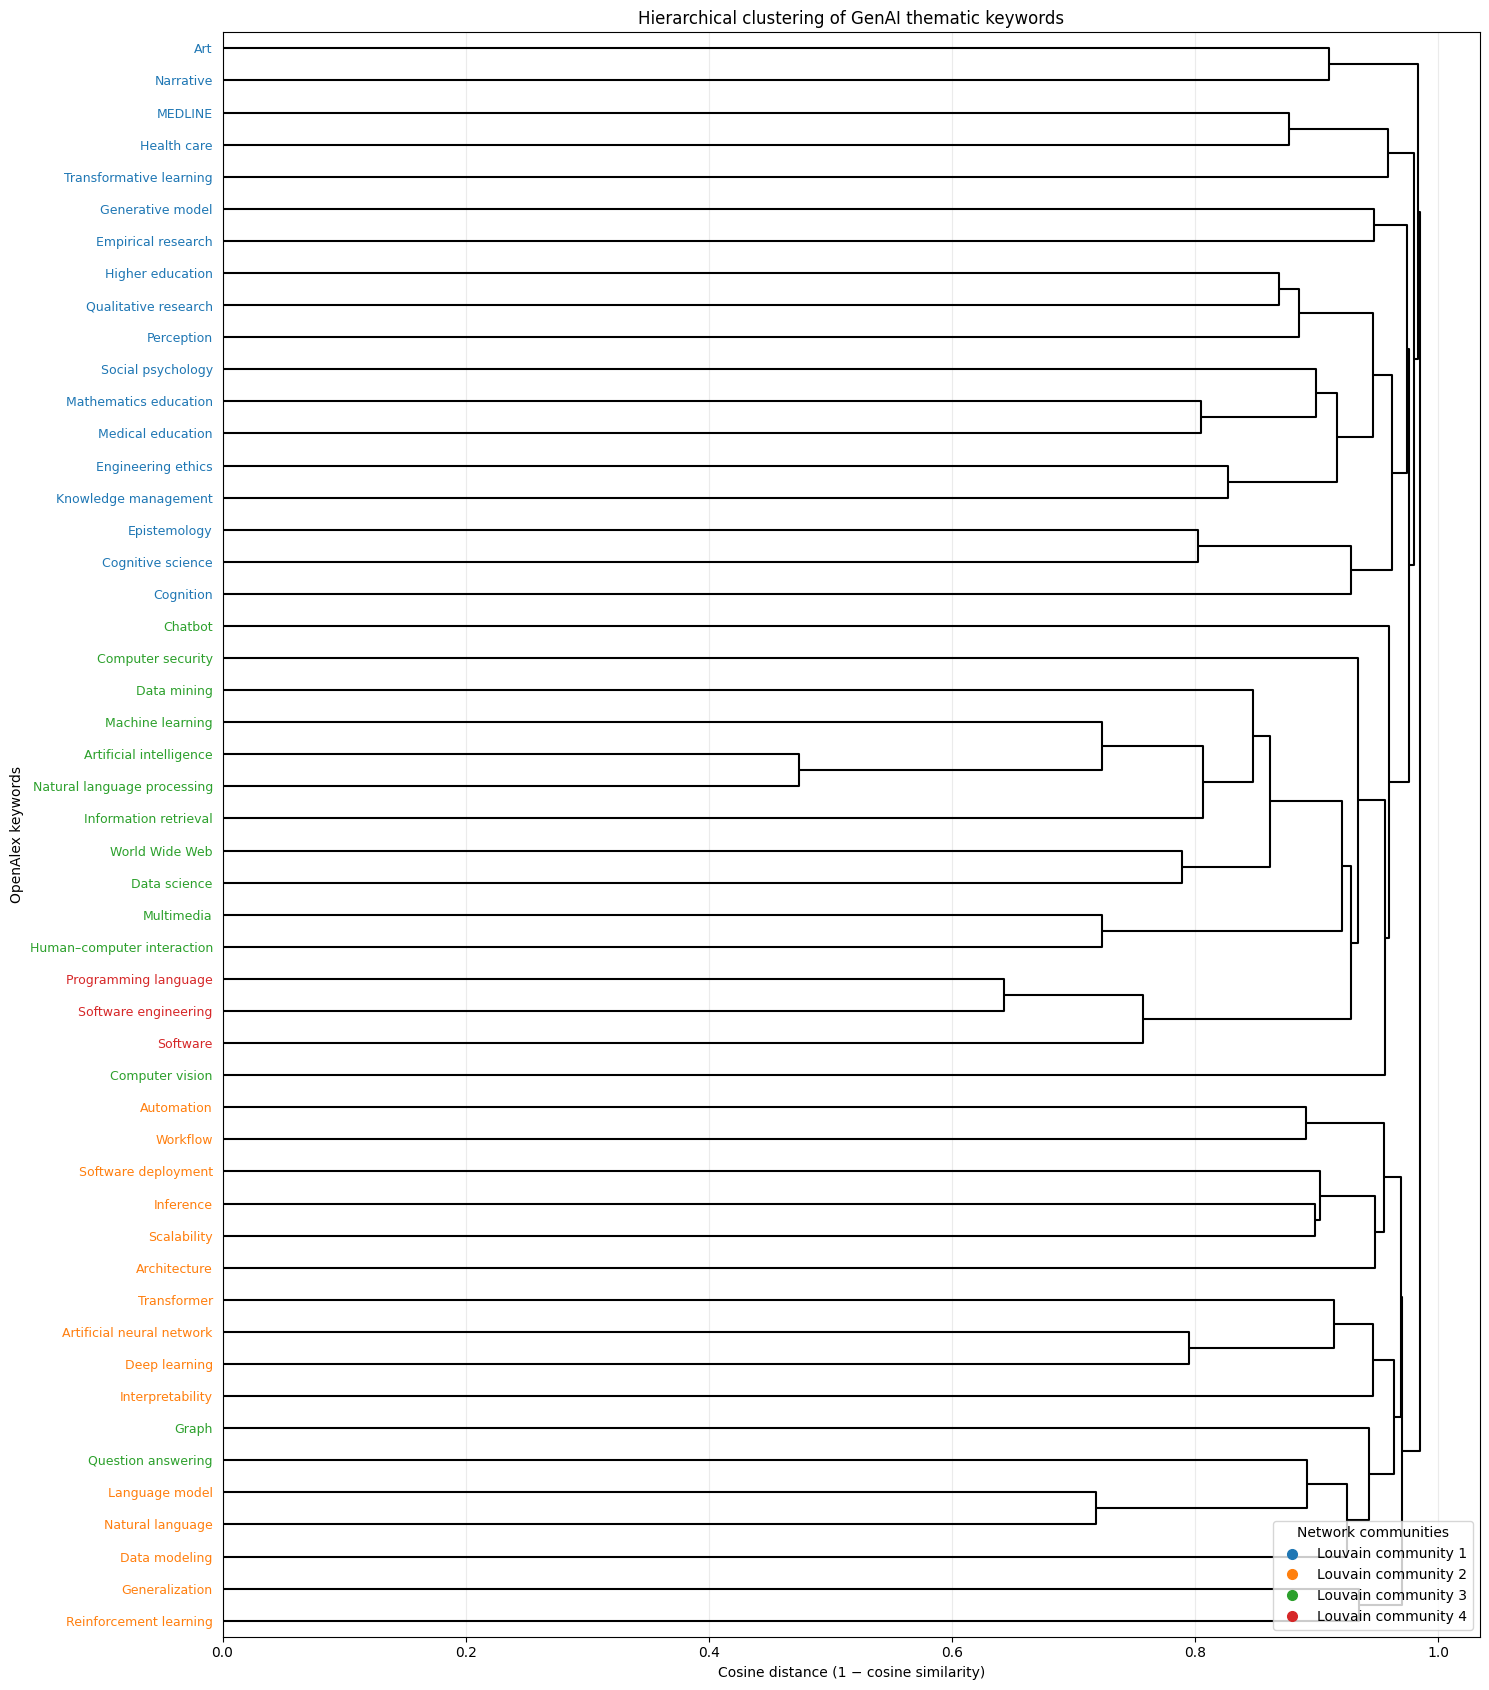

=== FINAL DENDROGRAM CONCORDANCE ===

Cluster-number sensitivity:
 requested_k  actual_clusters  silhouette_score  minimum_cluster_size  maximum_cluster_size                          cluster_sizes
           2                2          0.027188                    17                    33                                17 | 33
           3                3          0.025950                     2                    31                            17 | 31 | 2
           4                4          0.024821                     2                    28                        17 | 28 | 3 | 2
           5                5          0.035418                     2                    17                   17 | 15 | 13 | 3 | 2
           6                6          0.034990                     2                    17               17 | 15 | 11 | 2 | 3 | 2
           7                7          0.033757                     2                    15           2 | 15 | 15 | 11 | 2 | 3 | 2
           8     

In [ ]:
# ============================================================
# FINAL DENDROGRAM AND CONCORDANCE ANALYSIS
# Hierarchical clusters versus Louvain communities
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    cophenet,
    fcluster,
)
from scipy.spatial.distance import squareform
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
DISTANCE_MATRIX_FILE = (
    "semantic_dendrogram_cosine_distance_matrix.csv"
)

FINAL_TERM_LIST_FILE = (
    "semantic_network_final_term_list.csv"
)

OUTPUT_CLUSTER_SENSITIVITY = (
    "semantic_dendrogram_cluster_number_sensitivity.csv"
)

OUTPUT_CONCORDANCE = (
    "semantic_dendrogram_louvain_concordance.csv"
)

OUTPUT_CROSSTAB = (
    "semantic_dendrogram_louvain_crosstab.csv"
)

OUTPUT_MEMBERSHIP = (
    "semantic_dendrogram_final_membership.csv"
)

OUTPUT_FIGURE_PNG = (
    "semantic_dendrogram_final_louvain_labels.png"
)

OUTPUT_FIGURE_PDF = (
    "semantic_dendrogram_final_louvain_labels.pdf"
)

OUTPUT_AUDIT = (
    "semantic_dendrogram_final_audit.csv"
)

LINKAGE_METHOD = "average"

# Four clusters retained only for direct comparison with Louvain.
COMPARISON_K = 4

# Evaluate whether another hierarchical cut is more natural.
K_VALUES = range(2, 11)

FIGURE_WIDTH = 15
FIGURE_HEIGHT = 17
FIGURE_DPI = 300

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
distance_df = pd.read_csv(
    DISTANCE_MATRIX_FILE,
    index_col=0,
)

term_list = pd.read_csv(
    FINAL_TERM_LIST_FILE,
    low_memory=False,
)

required_columns = {
    "term_normalized",
    "label",
    "document_frequency",
    "community",
}

missing_columns = required_columns.difference(
    term_list.columns
)

if missing_columns:
    raise ValueError(
        "Faltan columnas en la lista final de términos: "
        f"{sorted(missing_columns)}"
    )

# ------------------------------------------------------------
# CLEAN TERM DATA
# ------------------------------------------------------------
term_list["term_normalized"] = (
    term_list["term_normalized"]
    .astype(str)
    .str.strip()
    .str.lower()
)

term_list["label"] = (
    term_list["label"]
    .astype(str)
    .str.strip()
)

term_list["community"] = pd.to_numeric(
    term_list["community"],
    errors="raise",
).astype(int)

if "network_order" in term_list.columns:
    term_list = term_list.sort_values(
        "network_order"
    )

term_list = (
    term_list
    .drop_duplicates(
        subset=["term_normalized"]
    )
    .reset_index(drop=True)
)

selected_terms = term_list[
    "term_normalized"
].tolist()

selected_labels = term_list[
    "label"
].tolist()

# ------------------------------------------------------------
# ALIGN DISTANCE MATRIX TO TERM LIST
# ------------------------------------------------------------
# The prior distance file uses representative labels as rows
# and columns. Check and reorder it accordingly.
missing_labels = sorted(
    set(selected_labels)
    .difference(distance_df.index)
)

if missing_labels:
    raise ValueError(
        "Las siguientes etiquetas no aparecen en la matriz "
        f"de distancia: {missing_labels}"
    )

distance_df = distance_df.loc[
    selected_labels,
    selected_labels,
]

distance_matrix = distance_df.to_numpy(
    dtype=float
)

# Numerical safeguards.
distance_matrix = (
    distance_matrix
    + distance_matrix.T
) / 2.0

distance_matrix = np.clip(
    distance_matrix,
    0.0,
    1.0,
)

np.fill_diagonal(
    distance_matrix,
    0.0,
)

condensed_distance = squareform(
    distance_matrix,
    checks=True,
)

# ------------------------------------------------------------
# AVERAGE-LINKAGE SOLUTION
# ------------------------------------------------------------
Z = linkage(
    condensed_distance,
    method=LINKAGE_METHOD,
    optimal_ordering=True,
)

cophenetic_correlation, _ = cophenet(
    Z,
    condensed_distance,
)

# ------------------------------------------------------------
# SENSITIVITY TO NUMBER OF HIERARCHICAL CLUSTERS
# ------------------------------------------------------------
cluster_sensitivity_rows = []

for k in K_VALUES:
    hierarchical_labels = fcluster(
        Z,
        t=k,
        criterion="maxclust",
    )

    actual_clusters = np.unique(
        hierarchical_labels
    ).size

    cluster_sizes = (
        pd.Series(
            hierarchical_labels
        )
        .value_counts()
        .sort_index()
        .tolist()
    )

    if actual_clusters >= 2:
        silhouette = silhouette_score(
            distance_matrix,
            hierarchical_labels,
            metric="precomputed",
        )
    else:
        silhouette = np.nan

    cluster_sensitivity_rows.append(
        {
            "requested_k": k,
            "actual_clusters": actual_clusters,
            "silhouette_score": silhouette,
            "minimum_cluster_size": min(
                cluster_sizes
            ),
            "maximum_cluster_size": max(
                cluster_sizes
            ),
            "cluster_sizes": " | ".join(
                str(value)
                for value in cluster_sizes
            ),
        }
    )

cluster_sensitivity = pd.DataFrame(
    cluster_sensitivity_rows
)

best_k_row = (
    cluster_sensitivity
    .sort_values(
        [
            "silhouette_score",
            "requested_k",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .iloc[0]
)

best_k = int(
    best_k_row["requested_k"]
)

# ------------------------------------------------------------
# FOUR-CLUSTER COMPARISON WITH LOUVAIN
# ------------------------------------------------------------
hierarchical_four = fcluster(
    Z,
    t=COMPARISON_K,
    criterion="maxclust",
)

louvain_labels = term_list[
    "community"
].to_numpy()

ari = adjusted_rand_score(
    louvain_labels,
    hierarchical_four,
)

nmi = normalized_mutual_info_score(
    louvain_labels,
    hierarchical_four,
)

crosstab = pd.crosstab(
    pd.Series(
        hierarchical_four,
        name="hierarchical_cluster",
    ),
    pd.Series(
        louvain_labels,
        name="louvain_community",
    ),
    margins=True,
)

membership = term_list[
    [
        "term_normalized",
        "label",
        "document_frequency",
        "community",
    ]
].copy()

membership = membership.rename(
    columns={
        "community": "louvain_community",
    }
)

membership[
    "hierarchical_cluster_k4"
] = hierarchical_four

# Best-silhouette solution for sensitivity only.
membership[
    f"hierarchical_cluster_k{best_k}"
] = fcluster(
    Z,
    t=best_k,
    criterion="maxclust",
)

membership = membership.sort_values(
    [
        "hierarchical_cluster_k4",
        "louvain_community",
        "document_frequency",
    ],
    ascending=[
        True,
        True,
        False,
    ],
).reset_index(drop=True)

concordance = pd.DataFrame(
    [
        {
            "hierarchical_method": (
                LINKAGE_METHOD
            ),
            "distance_metric": (
                "1 - cosine similarity"
            ),
            "number_of_terms": len(
                term_list
            ),
            "louvain_communities": (
                np.unique(
                    louvain_labels
                ).size
            ),
            "hierarchical_clusters_compared": (
                np.unique(
                    hierarchical_four
                ).size
            ),
            "adjusted_rand_index": ari,
            "normalized_mutual_information": nmi,
            "best_silhouette_k": best_k,
            "best_silhouette_score": float(
                best_k_row[
                    "silhouette_score"
                ]
            ),
        }
    ]
)

# ------------------------------------------------------------
# DENDROGRAM
# Labels colored by Louvain community
# ------------------------------------------------------------
# Use Matplotlib's default categorical cycle without defining
# manual colors.
community_ids = sorted(
    term_list[
        "community"
    ].unique()
)

default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

community_color = {
    community_id: default_colors[
        index % len(default_colors)
    ]
    for index, community_id in enumerate(
        community_ids
    )
}

label_to_community = dict(
    zip(
        term_list["label"],
        term_list["community"],
    )
)

fig, ax = plt.subplots(
    figsize=(
        FIGURE_WIDTH,
        FIGURE_HEIGHT,
    )
)

dendrogram_result = dendrogram(
    Z,
    labels=selected_labels,
    orientation="right",
    leaf_font_size=9,
    color_threshold=0,
    above_threshold_color="black",
    distance_sort=False,
    count_sort=False,
    ax=ax,
)

# Color only the leaf labels according to Louvain communities.
for tick_label in ax.get_yticklabels():
    label = tick_label.get_text()
    community = label_to_community[
        label
    ]

    tick_label.set_color(
        community_color[
            community
        ]
    )

ax.set_title(
    "Hierarchical clustering of GenAI thematic keywords"
)

ax.set_xlabel(
    "Cosine distance (1 − cosine similarity)"
)

ax.set_ylabel(
    "OpenAlex keywords"
)

ax.grid(
    axis="x",
    alpha=0.25,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        label=(
            f"Louvain community "
            f"{community_id}"
        ),
        markerfacecolor=(
            community_color[
                community_id
            ]
        ),
        markeredgecolor=(
            community_color[
                community_id
            ]
        ),
        markersize=7,
    )
    for community_id in community_ids
]

ax.legend(
    handles=legend_handles,
    title="Network communities",
    loc="lower right",
    frameon=True,
)

plt.tight_layout()

fig.savefig(
    OUTPUT_FIGURE_PNG,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_FIGURE_PDF,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# LEAF ORDER
# ------------------------------------------------------------
leaf_indices = dendrogram_result[
    "leaves"
]

leaf_order_lookup = {
    original_index: position
    for position, original_index in enumerate(
        leaf_indices,
        start=1,
    )
}

membership["leaf_position"] = (
    membership.index.map(
        leaf_order_lookup
    )
)

# Because membership was sorted after cluster assignment,
# reconstruct leaf positions directly by term.
term_leaf_position = {
    selected_terms[index]: position
    for position, index in enumerate(
        leaf_indices,
        start=1,
    )
}

membership["leaf_position"] = (
    membership["term_normalized"]
    .map(term_leaf_position)
)

# ------------------------------------------------------------
# AUDIT
# ------------------------------------------------------------
audit = pd.DataFrame(
    [
        {
            "number_of_terms": len(
                term_list
            ),
            "linkage_method": (
                LINKAGE_METHOD
            ),
            "distance_metric": (
                "1 - cosine similarity"
            ),
            "optimal_leaf_ordering": True,
            "cophenetic_correlation": float(
                cophenetic_correlation
            ),
            "comparison_clusters": (
                COMPARISON_K
            ),
            "adjusted_rand_index": ari,
            "normalized_mutual_information": nmi,
            "best_silhouette_k": best_k,
            "best_silhouette_score": float(
                best_k_row[
                    "silhouette_score"
                ]
            ),
            "figure_branch_encoding": (
                "black hierarchical branches"
            ),
            "figure_label_encoding": (
                "Louvain community"
            ),
        }
    ]
)

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------
print("=== FINAL DENDROGRAM CONCORDANCE ===")

print("\nCluster-number sensitivity:")
print(
    cluster_sensitivity.to_string(
        index=False
    )
)

print("\nLouvain–hierarchical concordance:")
print(
    concordance.to_string(
        index=False
    )
)

print("\nCross-tabulation:")
print(
    crosstab.to_string()
)

print("\nFinal dendrogram audit:")
print(
    audit.to_string(
        index=False
    )
)

print("\nMembership:")
print(
    membership.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
cluster_sensitivity.to_csv(
    OUTPUT_CLUSTER_SENSITIVITY,
    index=False,
)

concordance.to_csv(
    OUTPUT_CONCORDANCE,
    index=False,
)

crosstab.to_csv(
    OUTPUT_CROSSTAB
)

membership.to_csv(
    OUTPUT_MEMBERSHIP,
    index=False,
)

audit.to_csv(
    OUTPUT_AUDIT,
    index=False,
)

print("\nFiles saved:")
print(f"- {OUTPUT_CLUSTER_SENSITIVITY}")
print(f"- {OUTPUT_CONCORDANCE}")
print(f"- {OUTPUT_CROSSTAB}")
print(f"- {OUTPUT_MEMBERSHIP}")
print(f"- {OUTPUT_FIGURE_PNG}")
print(f"- {OUTPUT_FIGURE_PDF}")
print(f"- {OUTPUT_AUDIT}")

In [ ]:
# ============================================================
# REVIEWER RESPONSE ANALYSES
# Additional validation and sensitivity analyses
# September 2026
# ============================================================

In [ ]:
# ============================================================
# R1. ORIGINAL CLASSIFIER VALIDATION — REPRODUCIBILITY AUDIT
# Reviewer 1, Comments 1–2
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

VALIDATION_FILE = "validation_sample_labeled.csv"

# ------------------------------------------------------------
# LOAD ORIGINAL VALIDATION FILE
# ------------------------------------------------------------

validation = pd.read_csv(
    VALIDATION_FILE,
    sep=";",
    low_memory=False
)

print("=" * 70)
print("ORIGINAL MANUAL VALIDATION AUDIT")
print("=" * 70)

print(f"\nTotal rows in file: {len(validation):,}")
print(f"Total columns: {validation.shape[1]}")

# ------------------------------------------------------------
# CLEAN MANUAL REFERENCE LABEL
# ------------------------------------------------------------

validation["manual_label"] = pd.to_numeric(
    validation["manual_label"],
    errors="coerce"
)

n_missing = validation["manual_label"].isna().sum()

validation_valid = (
    validation
    .dropna(subset=["manual_label"])
    .copy()
)

validation_valid["manual_label"] = (
    validation_valid["manual_label"]
    .astype(int)
)

print(f"\nRecords without valid manual label: {n_missing}")
print(f"Valid manually coded records: {len(validation_valid):,}")

print("\nManual reference distribution:")
print(
    validation_valid["manual_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# VERIFY REQUIRED CLASSIFIER VARIABLES
# ------------------------------------------------------------

required_cols = [
    "is_genai_strict",
    "is_genai_broad",
    "manual_label"
]

missing_cols = [
    c for c in required_cols
    if c not in validation_valid.columns
]

if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}"
    )

# Convert classifier predictions robustly to 0/1
for col in ["is_genai_strict", "is_genai_broad"]:

    if validation_valid[col].dtype == "object":
        validation_valid[col] = (
            validation_valid[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0
            })
        )
    else:
        validation_valid[col] = (
            validation_valid[col]
            .astype(int)
        )

# Check for conversion problems
for col in ["is_genai_strict", "is_genai_broad"]:
    if validation_valid[col].isna().any():
        raise ValueError(
            f"Some values in '{col}' could not be converted to 0/1."
        )

# ------------------------------------------------------------
# FUNCTION TO CALCULATE VALIDATION METRICS
# ------------------------------------------------------------

def classifier_metrics(y_true, y_pred, classifier_name):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    prevalence = y_true.mean()

    predicted_positive_rate = y_pred.mean()

    metrics = {
        "classifier": classifier_name,
        "N": len(y_true),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "accuracy": accuracy,
        "precision_PPV": precision,
        "recall_sensitivity": recall,
        "specificity": specificity,
        "NPV": npv,
        "F1": f1,
        "manual_positive_prevalence": prevalence,
        "predicted_positive_rate": predicted_positive_rate
    }

    return metrics, cm

# ------------------------------------------------------------
# STRICT CLASSIFIER
# ------------------------------------------------------------

strict_metrics, strict_cm = classifier_metrics(
    validation_valid["manual_label"],
    validation_valid["is_genai_strict"],
    "Strict"
)

# ------------------------------------------------------------
# EXPANDED CLASSIFIER
# ------------------------------------------------------------

broad_metrics, broad_cm = classifier_metrics(
    validation_valid["manual_label"],
    validation_valid["is_genai_broad"],
    "Expanded"
)

# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

metrics_df = pd.DataFrame([
    strict_metrics,
    broad_metrics
])

print("\n" + "=" * 70)
print("CLASSIFIER PERFORMANCE")
print("=" * 70)

display(
    metrics_df.round(4)
)

# ------------------------------------------------------------
# CONFUSION MATRICES
# ------------------------------------------------------------

strict_cm_df = pd.DataFrame(
    strict_cm,
    index=[
        "Manual: Not GenAI",
        "Manual: GenAI"
    ],
    columns=[
        "Predicted: Not GenAI",
        "Predicted: GenAI"
    ]
)

broad_cm_df = pd.DataFrame(
    broad_cm,
    index=[
        "Manual: Not GenAI",
        "Manual: GenAI"
    ],
    columns=[
        "Predicted: Not GenAI",
        "Predicted: GenAI"
    ]
)

print("\nSTRICT CLASSIFIER — CONFUSION MATRIX")
display(strict_cm_df)

print("\nEXPANDED CLASSIFIER — CONFUSION MATRIX")
display(broad_cm_df)

# ------------------------------------------------------------
# EXPECTED VALUES FROM MANUSCRIPT
# ------------------------------------------------------------

expected = {
    "Strict": {
        "TP": 51,
        "FP": 23,
        "FN": 17,
        "TN": 208
    },
    "Expanded": {
        "TP": 53,
        "FP": 26,
        "FN": 15,
        "TN": 205
    }
}

print("\n" + "=" * 70)
print("REPRODUCIBILITY CHECK AGAINST MANUSCRIPT")
print("=" * 70)

for row in [strict_metrics, broad_metrics]:

    name = row["classifier"]

    ok = all(
        row[k] == expected[name][k]
        for k in ["TP", "FP", "FN", "TN"]
    )

    print(
        f"{name}: "
        f"{'MATCHES MANUSCRIPT' if ok else 'CHECK REQUIRED'}"
    )

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

metrics_df.to_csv(
    "reviewer_R1_original_validation_metrics.csv",
    index=False
)

strict_cm_df.to_csv(
    "reviewer_R1_strict_confusion_matrix.csv"
)

broad_cm_df.to_csv(
    "reviewer_R1_expanded_confusion_matrix.csv"
)

print("\nFiles exported:")
print(" - reviewer_R1_original_validation_metrics.csv")
print(" - reviewer_R1_strict_confusion_matrix.csv")
print(" - reviewer_R1_expanded_confusion_matrix.csv")

ORIGINAL MANUAL VALIDATION AUDIT

Total rows in file: 300
Total columns: 42

Records without valid manual label: 1
Valid manually coded records: 299

Manual reference distribution:
manual_label
0    231
1     68
Name: count, dtype: int64

CLASSIFIER PERFORMANCE


,classifier,N,TP,FP,FN,TN,accuracy,precision_PPV,recall_sensitivity,specificity,NPV,F1,manual_positive_prevalence,predicted_positive_rate
0,Strict,299,51,23,17,208,0.8662,0.6892,0.7500,0.9004,0.9244,0.7183,0.2274,0.2475
1,Expanded,299,53,26,15,205,0.8629,0.6709,0.7794,0.8874,0.9318,0.7211,0.2274,0.2642



STRICT CLASSIFIER — CONFUSION MATRIX


,Predicted: Not GenAI,Predicted: GenAI
Manual: Not GenAI,208,23
Manual: GenAI,17,51



EXPANDED CLASSIFIER — CONFUSION MATRIX


,Predicted: Not GenAI,Predicted: GenAI
Manual: Not GenAI,205,26
Manual: GenAI,15,53



REPRODUCIBILITY CHECK AGAINST MANUSCRIPT
Strict: MATCHES MANUSCRIPT
Expanded: MATCHES MANUSCRIPT

Files exported:
 - reviewer_R1_original_validation_metrics.csv
 - reviewer_R1_strict_confusion_matrix.csv
 - reviewer_R1_expanded_confusion_matrix.csv


In [ ]:
# ============================================================
# R2. BLINDED RANDOM SUBSAMPLE FOR SECOND INDEPENDENT CODER
# Reviewer 1, Comment 1
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

RANDOM_SEED = 20260903
SECOND_CODER_N = 100

MASTER_OUTPUT = "reviewer_R2_second_coder_MASTER_100.csv"
BLINDED_CSV_OUTPUT = "reviewer_R2_second_coder_BLINDED_100.csv"
BLINDED_XLSX_OUTPUT = "reviewer_R2_second_coder_BLINDED_100.xlsx"
AUDIT_OUTPUT = "reviewer_R2_second_coder_sampling_audit.csv"

# ------------------------------------------------------------
# REQUIRE R1 OUTPUT IN MEMORY
# ------------------------------------------------------------

if "validation_valid" not in globals():
    raise RuntimeError(
        "Run Cell R1 first. "
        "The object 'validation_valid' is not available."
    )

if len(validation_valid) != 299:
    raise ValueError(
        f"Expected 299 valid validation records, "
        f"but found {len(validation_valid)}."
    )

# ------------------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required = [
    "manual_label",
    "is_genai_strict",
    "is_genai_broad",
    "title",
    "abstract"
]

missing = [
    c for c in required
    if c not in validation_valid.columns
]

if missing:
    raise ValueError(
        f"Required columns missing: {missing}"
    )

# ------------------------------------------------------------
# SIMPLE RANDOM SAMPLE WITHOUT REPLACEMENT
# ------------------------------------------------------------

second_coder_master = (
    validation_valid
    .sample(
        n=SECOND_CODER_N,
        replace=False,
        random_state=RANDOM_SEED
    )
    .copy()
)

# Randomize presentation order independently
second_coder_master = (
    second_coder_master
    .sample(
        frac=1,
        random_state=RANDOM_SEED + 1
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# CREATE ANONYMOUS STUDY ID
# ------------------------------------------------------------

second_coder_master.insert(
    0,
    "study_id",
    [
        f"SC_{i:03d}"
        for i in range(1, SECOND_CODER_N + 1)
    ]
)

# ------------------------------------------------------------
# SAVE INTERNAL MASTER
# DO NOT SEND TO SECOND CODER
# ------------------------------------------------------------

priority_master_cols = [
    "study_id",
    "openalex_id",
    "title",
    "abstract",
    "manual_label",
    "is_genai_strict",
    "is_genai_broad",
    "semantic_label"
]

priority_master_cols = [
    c for c in priority_master_cols
    if c in second_coder_master.columns
]

other_cols = [
    c for c in second_coder_master.columns
    if c not in priority_master_cols
]

second_coder_master = second_coder_master[
    priority_master_cols + other_cols
]

second_coder_master.to_csv(
    MASTER_OUTPUT,
    index=False
)

# ------------------------------------------------------------
# CREATE BLINDED FILE
# ------------------------------------------------------------

blinded_cols = [
    "study_id",
    "title",
    "abstract"
]

second_coder_blinded = (
    second_coder_master[
        blinded_cols
    ]
    .copy()
)

second_coder_blinded["second_coder_label"] = ""
second_coder_blinded["second_coder_notes"] = ""

# ------------------------------------------------------------
# VERIFY THAT NO CLASSIFICATION INFORMATION LEAKS
# ------------------------------------------------------------

forbidden_terms = [
    "manual",
    "strict",
    "broad",
    "semantic_label",
    "prediction",
    "genai_hits"
]

leaked_columns = [
    col for col in second_coder_blinded.columns
    if any(
        term in col.lower()
        for term in forbidden_terms
    )
]

if leaked_columns:
    raise RuntimeError(
        f"BLINDING FAILURE. "
        f"Potentially revealing columns found: {leaked_columns}"
    )

# ------------------------------------------------------------
# CODING INSTRUCTIONS
# ------------------------------------------------------------

instructions = pd.DataFrame(
    {
        "Item": [
            "Purpose",
            "Unit of assessment",
            "Code 1",
            "Code 0",
            "Evidence",
            "Incidental mentions",
            "Uncertain cases",
            "Independence"
        ],
        "Instruction": [
            (
                "Independently determine whether each publication "
                "substantively addresses generative artificial intelligence."
            ),
            (
                "Evaluate each record as an individual scholarly publication."
            ),
            (
                "Enter 1 if the publication substantively addresses "
                "generative artificial intelligence."
            ),
            (
                "Enter 0 if the publication does not substantively address "
                "generative artificial intelligence."
            ),
            (
                "Base the judgment on the title and abstract provided."
            ),
            (
                "Do not assign 1 solely because AI-related terminology "
                "appears incidentally or without substantive relevance."
            ),
            (
                "If the case is difficult, assign the best binary judgment "
                "and briefly describe the uncertainty in second_coder_notes."
            ),
            (
                "The coding must be performed independently. "
                "The original human labels and classifier predictions "
                "have intentionally been withheld."
            )
        ]
    }
)

# ------------------------------------------------------------
# EXPORT BLINDED FILES
# ------------------------------------------------------------

second_coder_blinded.to_csv(
    BLINDED_CSV_OUTPUT,
    index=False
)

with pd.ExcelWriter(
    BLINDED_XLSX_OUTPUT,
    engine="openpyxl"
) as writer:

    second_coder_blinded.to_excel(
        writer,
        sheet_name="Coding_sample",
        index=False
    )

    instructions.to_excel(
        writer,
        sheet_name="Instructions",
        index=False
    )

# ------------------------------------------------------------
# INTERNAL SAMPLING AUDIT
# ------------------------------------------------------------

audit_rows = []

def add_audit(variable, category, full_n, sample_n):
    audit_rows.append(
        {
            "variable": variable,
            "category": category,
            "full_validation_N": full_n,
            "second_coder_sample_N": sample_n,
            "full_validation_pct": (
                full_n / len(validation_valid) * 100
            ),
            "second_coder_sample_pct": (
                sample_n / len(second_coder_master) * 100
            )
        }
    )

# Manual labels
for value in [0, 1]:
    add_audit(
        "manual_label",
        str(value),
        int(
            (validation_valid["manual_label"] == value).sum()
        ),
        int(
            (second_coder_master["manual_label"] == value).sum()
        )
    )

# Strict predictions
for value in [0, 1]:
    add_audit(
        "is_genai_strict",
        str(value),
        int(
            (validation_valid["is_genai_strict"] == value).sum()
        ),
        int(
            (second_coder_master["is_genai_strict"] == value).sum()
        )
    )

# Broad predictions
for value in [0, 1]:
    add_audit(
        "is_genai_broad",
        str(value),
        int(
            (validation_valid["is_genai_broad"] == value).sum()
        ),
        int(
            (second_coder_master["is_genai_broad"] == value).sum()
        )
    )

sampling_audit = pd.DataFrame(audit_rows)

sampling_audit.to_csv(
    AUDIT_OUTPUT,
    index=False
)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("SECOND-CODER BLINDED SAMPLE")
print("=" * 70)

print(f"\nRandom seed: {RANDOM_SEED}")
print(f"Validation population: {len(validation_valid)}")
print(f"Second-coder sample: {len(second_coder_master)}")
print(
    f"Sampling fraction: "
    f"{len(second_coder_master) / len(validation_valid):.2%}"
)

print("\nINTERNAL AUDIT — manual reference labels:")
print(
    second_coder_master["manual_label"]
    .value_counts()
    .sort_index()
)

print("\nINTERNAL AUDIT — strict classifier:")
print(
    second_coder_master["is_genai_strict"]
    .value_counts()
    .sort_index()
)

print("\nINTERNAL AUDIT — expanded classifier:")
print(
    second_coder_master["is_genai_broad"]
    .value_counts()
    .sort_index()
)

print("\nSampling comparison:")
display(
    sampling_audit.round(2)
)

print("\nBlinding check: PASSED")

print("\nFiles created:")
print(f" INTERNAL ONLY: {MASTER_OUTPUT}")
print(f" INTERNAL ONLY: {AUDIT_OUTPUT}")
print(f" SEND TO SECOND CODER: {BLINDED_XLSX_OUTPUT}")
print(f" Optional CSV: {BLINDED_CSV_OUTPUT}")

SECOND-CODER BLINDED SAMPLE

Random seed: 20260903
Validation population: 299
Second-coder sample: 100
Sampling fraction: 33.44%

INTERNAL AUDIT — manual reference labels:
manual_label
0    80
1    20
Name: count, dtype: int64

INTERNAL AUDIT — strict classifier:
is_genai_strict
0    79
1    21
Name: count, dtype: int64

INTERNAL AUDIT — expanded classifier:
is_genai_broad
0    80
1    20
Name: count, dtype: int64

Sampling comparison:


,variable,category,full_validation_N,second_coder_sample_N,full_validation_pct,second_coder_sample_pct
0,manual_label,0,231,80,77.26,80.0
1,manual_label,1,68,20,22.74,20.0
2,is_genai_strict,0,225,79,75.25,79.0
3,is_genai_strict,1,74,21,24.75,21.0
4,is_genai_broad,0,220,80,73.58,80.0
5,is_genai_broad,1,79,20,26.42,20.0



Blinding check: PASSED

Files created:
 INTERNAL ONLY: reviewer_R2_second_coder_MASTER_100.csv
 INTERNAL ONLY: reviewer_R2_second_coder_sampling_audit.csv
 SEND TO SECOND CODER: reviewer_R2_second_coder_BLINDED_100.xlsx
 Optional CSV: reviewer_R2_second_coder_BLINDED_100.csv


In [ ]:
# ============================================================
# OPTIONAL R2B. ADD CONFIDENCE FIELD TO BLINDED CODING FILE
# ============================================================

import pandas as pd

INPUT_FILE = "reviewer_R2_second_coder_BLINDED_100.xlsx"
OUTPUT_FILE = "reviewer_R2_second_coder_BLINDED_100_FINAL.xlsx"

coding = pd.read_excel(
    INPUT_FILE,
    sheet_name="Coding_sample"
)

instructions = pd.read_excel(
    INPUT_FILE,
    sheet_name="Instructions"
)

# Add confidence field
if "second_coder_confidence" not in coding.columns:
    coding["second_coder_confidence"] = ""

# Reorder columns
coding = coding[
    [
        "study_id",
        "title",
        "abstract",
        "second_coder_label",
        "second_coder_confidence",
        "second_coder_notes"
    ]
]

# Add instruction
extra_instruction = pd.DataFrame({
    "Item": ["Confidence"],
    "Instruction": [
        "Optionally indicate confidence in the classification as High, Moderate, or Low."
    ]
})

instructions = pd.concat(
    [instructions, extra_instruction],
    ignore_index=True
)

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    coding.to_excel(
        writer,
        sheet_name="Coding_sample",
        index=False
    )

    instructions.to_excel(
        writer,
        sheet_name="Instructions",
        index=False
    )

print(f"Final blinded coding file created: {OUTPUT_FILE}")

Final blinded coding file created: reviewer_R2_second_coder_BLINDED_100_FINAL.xlsx


In [ ]:
# ============================================================
# R3. INTER-RATER RELIABILITY ANALYSIS
# Reviewer 1, Comment 1
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    cohen_kappa_score,
    accuracy_score
)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

MASTER_FILE = "reviewer_R2_second_coder_MASTER_100.csv"
SECOND_CODER_FILE = "reviewer_R2_second_coder_BLINDED_100_FINAL.xlsx"

BOOTSTRAP_ITERATIONS = 10000
RANDOM_SEED = 20260903

# ------------------------------------------------------------
# LOAD FILES
# ------------------------------------------------------------

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

second = pd.read_excel(
    SECOND_CODER_FILE,
    sheet_name="Coding_sample"
)

print("=" * 75)
print("INTER-RATER RELIABILITY AUDIT")
print("=" * 75)

print(f"\nMaster records: {len(master)}")
print(f"Second-coder records: {len(second)}")

# ------------------------------------------------------------
# BASIC INTEGRITY CHECKS
# ------------------------------------------------------------

if master["study_id"].duplicated().any():
    raise ValueError(
        "Duplicated study_id values detected in MASTER file."
    )

if second["study_id"].duplicated().any():
    raise ValueError(
        "Duplicated study_id values detected in second-coder file."
    )

# Convert labels robustly
master["manual_label"] = pd.to_numeric(
    master["manual_label"],
    errors="coerce"
)

second["second_coder_label"] = pd.to_numeric(
    second["second_coder_label"],
    errors="coerce"
)

# ------------------------------------------------------------
# MERGE
# ------------------------------------------------------------

merged = master.merge(
    second[
        [
            "study_id",
            "second_coder_label",
            "second_coder_confidence",
            "second_coder_notes"
        ]
    ],
    on="study_id",
    how="inner",
    validate="one_to_one"
)

print(f"\nSuccessfully matched records: {len(merged)}")

if len(merged) != 100:
    raise ValueError(
        f"Expected 100 matched records, obtained {len(merged)}."
    )

# ------------------------------------------------------------
# VALID LABEL CHECK
# ------------------------------------------------------------

analysis = merged.dropna(
    subset=[
        "manual_label",
        "second_coder_label"
    ]
).copy()

analysis["manual_label"] = (
    analysis["manual_label"].astype(int)
)

analysis["second_coder_label"] = (
    analysis["second_coder_label"].astype(int)
)

valid_values = {0, 1}

if not set(
    analysis["manual_label"].unique()
).issubset(valid_values):
    raise ValueError(
        "Invalid values detected in manual_label."
    )

if not set(
    analysis["second_coder_label"].unique()
).issubset(valid_values):
    raise ValueError(
        "Invalid values detected in second_coder_label."
    )

print(f"Valid paired ratings: {len(analysis)}")

# ------------------------------------------------------------
# DISTRIBUTIONS
# ------------------------------------------------------------

print("\nFIRST CODER distribution:")
print(
    analysis["manual_label"]
    .value_counts()
    .sort_index()
)

print("\nSECOND CODER distribution:")
print(
    analysis["second_coder_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# CONFUSION / AGREEMENT MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    analysis["manual_label"],
    analysis["second_coder_label"],
    labels=[0, 1]
)

# Here:
# a = both coders say 0
# b = coder 1 says 0, coder 2 says 1
# c = coder 1 says 1, coder 2 says 0
# d = both coders say 1

a, b, c, d = cm.ravel()

agreement_matrix = pd.DataFrame(
    cm,
    index=[
        "First coder: 0",
        "First coder: 1"
    ],
    columns=[
        "Second coder: 0",
        "Second coder: 1"
    ]
)

print("\n" + "=" * 75)
print("AGREEMENT MATRIX")
print("=" * 75)

display(agreement_matrix)

# ------------------------------------------------------------
# OBSERVED AGREEMENT
# ------------------------------------------------------------

observed_agreement = accuracy_score(
    analysis["manual_label"],
    analysis["second_coder_label"]
)

# ------------------------------------------------------------
# COHEN'S KAPPA
# ------------------------------------------------------------

kappa = cohen_kappa_score(
    analysis["manual_label"],
    analysis["second_coder_label"]
)

# ------------------------------------------------------------
# POSITIVE AND NEGATIVE AGREEMENT
#
# Positive agreement:
# 2d / (2d + b + c)
#
# Negative agreement:
# 2a / (2a + b + c)
# ------------------------------------------------------------

positive_agreement = (
    (2 * d) / (2 * d + b + c)
    if (2 * d + b + c) > 0
    else np.nan
)

negative_agreement = (
    (2 * a) / (2 * a + b + c)
    if (2 * a + b + c) > 0
    else np.nan
)

# ------------------------------------------------------------
# BOOTSTRAP 95% CI FOR COHEN'S KAPPA
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

y1 = analysis["manual_label"].to_numpy()
y2 = analysis["second_coder_label"].to_numpy()

n = len(analysis)

bootstrap_kappas = []

for _ in range(BOOTSTRAP_ITERATIONS):

    idx = rng.integers(
        low=0,
        high=n,
        size=n
    )

    sample_y1 = y1[idx]
    sample_y2 = y2[idx]

    # Cohen's kappa can be undefined in rare bootstrap
    # samples containing only one category
    try:
        k = cohen_kappa_score(
            sample_y1,
            sample_y2
        )

        if np.isfinite(k):
            bootstrap_kappas.append(k)

    except Exception:
        pass

bootstrap_kappas = np.array(
    bootstrap_kappas
)

kappa_ci_low = np.percentile(
    bootstrap_kappas,
    2.5
)

kappa_ci_high = np.percentile(
    bootstrap_kappas,
    97.5
)

# ------------------------------------------------------------
# DISAGREEMENTS
# ------------------------------------------------------------

analysis["agreement"] = (
    analysis["manual_label"]
    == analysis["second_coder_label"]
)

disagreements = (
    analysis[
        ~analysis["agreement"]
    ]
    .copy()
)

# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------

summary = pd.DataFrame(
    {
        "Metric": [
            "N paired records",
            "Observed agreement",
            "Cohen's kappa",
            "Kappa 95% CI lower",
            "Kappa 95% CI upper",
            "Positive agreement",
            "Negative agreement",
            "Total agreements",
            "Total disagreements"
        ],
        "Value": [
            len(analysis),
            observed_agreement,
            kappa,
            kappa_ci_low,
            kappa_ci_high,
            positive_agreement,
            negative_agreement,
            int(analysis["agreement"].sum()),
            int((~analysis["agreement"]).sum())
        ]
    }
)

print("\n" + "=" * 75)
print("INTER-RATER RELIABILITY RESULTS")
print("=" * 75)

display(
    summary.round(4)
)

print(
    f"\nObserved agreement: "
    f"{observed_agreement:.3f} "
    f"({observed_agreement*100:.1f}%)"
)

print(
    f"Cohen's kappa: "
    f"{kappa:.3f}"
)

print(
    f"Bootstrap 95% CI: "
    f"[{kappa_ci_low:.3f}, {kappa_ci_high:.3f}]"
)

print(
    f"Positive agreement: "
    f"{positive_agreement:.3f}"
)

print(
    f"Negative agreement: "
    f"{negative_agreement:.3f}"
)

print(
    f"Agreements: "
    f"{analysis['agreement'].sum()}"
)

print(
    f"Disagreements: "
    f"{(~analysis['agreement']).sum()}"
)

# ------------------------------------------------------------
# DISAGREEMENT TYPES
# ------------------------------------------------------------

disagreement_types = pd.DataFrame(
    {
        "Type": [
            "Both coded 0",
            "First coder 0 / Second coder 1",
            "First coder 1 / Second coder 0",
            "Both coded 1"
        ],
        "N": [
            a,
            b,
            c,
            d
        ]
    }
)

print("\nAgreement/disagreement pattern:")
display(disagreement_types)

# ------------------------------------------------------------
# EXPORT RESULTS
# ------------------------------------------------------------

summary.to_csv(
    "reviewer_R3_interrater_reliability_summary.csv",
    index=False
)

agreement_matrix.to_csv(
    "reviewer_R3_interrater_agreement_matrix.csv"
)

disagreements.to_csv(
    "reviewer_R3_disagreement_cases_INTERNAL.csv",
    index=False
)

disagreement_types.to_csv(
    "reviewer_R3_agreement_patterns.csv",
    index=False
)

print("\nFiles exported:")
print(
    " - reviewer_R3_interrater_reliability_summary.csv"
)
print(
    " - reviewer_R3_interrater_agreement_matrix.csv"
)
print(
    " - reviewer_R3_disagreement_cases_INTERNAL.csv"
)
print(
    " - reviewer_R3_agreement_patterns.csv"
)

INTER-RATER RELIABILITY AUDIT

Master records: 100
Second-coder records: 100

Successfully matched records: 100
Valid paired ratings: 100

FIRST CODER distribution:
manual_label
0    80
1    20
Name: count, dtype: int64

SECOND CODER distribution:
second_coder_label
0    59
1    41
Name: count, dtype: int64

AGREEMENT MATRIX


,Second coder: 0,Second coder: 1
First coder: 0,59,21
First coder: 1,0,20



INTER-RATER RELIABILITY RESULTS


,Metric,Value
0,N paired records,100.0000
1,Observed agreement,0.7900
2,Cohen's kappa,0.5291
3,Kappa 95% CI lower,0.3668
4,Kappa 95% CI upper,0.6807
5,Positive agreement,0.6557
6,Negative agreement,0.8489
7,Total agreements,79.0000
8,Total disagreements,21.0000



Observed agreement: 0.790 (79.0%)
Cohen's kappa: 0.529
Bootstrap 95% CI: [0.367, 0.681]
Positive agreement: 0.656
Negative agreement: 0.849
Agreements: 79
Disagreements: 21

Agreement/disagreement pattern:


,Type,N
0,Both coded 0,59
1,First coder 0 / Second coder 1,21
2,First coder 1 / Second coder 0,0
3,Both coded 1,20



Files exported:
 - reviewer_R3_interrater_reliability_summary.csv
 - reviewer_R3_interrater_agreement_matrix.csv
 - reviewer_R3_disagreement_cases_INTERNAL.csv
 - reviewer_R3_agreement_patterns.csv


In [ ]:
# ============================================================
# R3B. DIAGNOSTIC ANALYSIS OF INTER-RATER DISAGREEMENTS
# Reviewer 1, Comment 1
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from statsmodels.stats.contingency_tables import mcnemar

# ------------------------------------------------------------
# REQUIRE R3 OBJECT
# ------------------------------------------------------------

if "analysis" not in globals():
    raise RuntimeError(
        "Run Cell R3 first. "
        "The object 'analysis' is not available."
    )

# ------------------------------------------------------------
# VERIFY CLASSIFIER VARIABLES
# ------------------------------------------------------------

required_cols = [
    "manual_label",
    "second_coder_label",
    "is_genai_strict",
    "is_genai_broad"
]

missing = [
    c for c in required_cols
    if c not in analysis.columns
]

if missing:
    raise ValueError(
        f"Required columns missing: {missing}"
    )

# ------------------------------------------------------------
# NORMALIZE CLASSIFIER VARIABLES
# ------------------------------------------------------------

for col in [
    "is_genai_strict",
    "is_genai_broad"
]:

    analysis[col] = pd.to_numeric(
        analysis[col],
        errors="coerce"
    ).astype(int)

# ------------------------------------------------------------
# IDENTIFY DISAGREEMENTS
# ------------------------------------------------------------

analysis["coder_agreement"] = (
    analysis["manual_label"]
    == analysis["second_coder_label"]
)

disagreement_cases = (
    analysis[
        ~analysis["coder_agreement"]
    ]
    .copy()
)

print("=" * 75)
print("DIAGNOSTIC ANALYSIS OF CODER DISAGREEMENTS")
print("=" * 75)

print(
    f"\nTotal paired records: {len(analysis)}"
)

print(
    f"Agreements: "
    f"{analysis['coder_agreement'].sum()}"
)

print(
    f"Disagreements: "
    f"{len(disagreement_cases)}"
)

# ------------------------------------------------------------
# McNEMAR TEST
#
# Tests whether the disagreement is symmetric:
# coder 1 = 0 / coder 2 = 1
# versus
# coder 1 = 1 / coder 2 = 0
# ------------------------------------------------------------

table = pd.crosstab(
    analysis["manual_label"],
    analysis["second_coder_label"]
)

table = table.reindex(
    index=[0, 1],
    columns=[0, 1],
    fill_value=0
)

mc_result = mcnemar(
    table.values,
    exact=True
)

print("\n" + "-" * 75)
print("McNEMAR EXACT TEST")
print("-" * 75)

print(table)

print(
    f"\nExact McNemar p-value: "
    f"{mc_result.pvalue:.6g}"
)

# ------------------------------------------------------------
# CLASSIFIER STATUS AMONG THE 21 DISAGREEMENTS
# ------------------------------------------------------------

print("\n" + "-" * 75)
print("STRICT CLASSIFIER AMONG DISAGREEMENTS")
print("-" * 75)

strict_disagreement = (
    disagreement_cases[
        "is_genai_strict"
    ]
    .value_counts()
    .sort_index()
)

print(strict_disagreement)

print("\n" + "-" * 75)
print("EXPANDED CLASSIFIER AMONG DISAGREEMENTS")
print("-" * 75)

broad_disagreement = (
    disagreement_cases[
        "is_genai_broad"
    ]
    .value_counts()
    .sort_index()
)

print(broad_disagreement)

# ------------------------------------------------------------
# CROSS-TAB:
# HUMAN DISAGREEMENTS × CLASSIFIER
# ------------------------------------------------------------

strict_cross = pd.crosstab(
    [
        disagreement_cases["manual_label"],
        disagreement_cases["second_coder_label"]
    ],
    disagreement_cases["is_genai_strict"],
    margins=True
)

broad_cross = pd.crosstab(
    [
        disagreement_cases["manual_label"],
        disagreement_cases["second_coder_label"]
    ],
    disagreement_cases["is_genai_broad"],
    margins=True
)

print("\nSTRICT classifier × disagreement:")
display(strict_cross)

print("\nEXPANDED classifier × disagreement:")
display(broad_cross)

# ------------------------------------------------------------
# FUNCTION:
# CLASSIFIER PERFORMANCE AGAINST EACH HUMAN CODER
# ------------------------------------------------------------

def compare_classifier_to_reference(
    data,
    reference_col,
    prediction_col,
    reference_name,
    classifier_name
):

    y_true = data[reference_col].astype(int)
    y_pred = data[prediction_col].astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    return {
        "human_reference": reference_name,
        "classifier": classifier_name,
        "N": len(data),

        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,

        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision_PPV": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall_sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "specificity": specificity,

        "NPV": npv,

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

# ------------------------------------------------------------
# COMPARE BOTH CLASSIFIERS AGAINST BOTH HUMAN CODERS
# ------------------------------------------------------------

comparison_results = []

for ref_col, ref_name in [
    ("manual_label", "First coder"),
    ("second_coder_label", "Second coder")
]:

    comparison_results.append(
        compare_classifier_to_reference(
            analysis,
            ref_col,
            "is_genai_strict",
            ref_name,
            "Strict"
        )
    )

    comparison_results.append(
        compare_classifier_to_reference(
            analysis,
            ref_col,
            "is_genai_broad",
            ref_name,
            "Expanded"
        )
    )

classifier_by_coder = pd.DataFrame(
    comparison_results
)

print("\n" + "=" * 75)
print("CLASSIFIER PERFORMANCE BY HUMAN REFERENCE")
print("=" * 75)

display(
    classifier_by_coder.round(4)
)

# ------------------------------------------------------------
# CLASSIFICATION PATTERNS FOR THE 21 DISAGREEMENTS
# ------------------------------------------------------------

pattern_table = (
    disagreement_cases
    .groupby(
        [
            "manual_label",
            "second_coder_label",
            "is_genai_strict",
            "is_genai_broad"
        ]
    )
    .size()
    .reset_index(name="N")
    .sort_values(
        "N",
        ascending=False
    )
)

print("\n" + "=" * 75)
print("PATTERNS AMONG DISAGREEMENT CASES")
print("=" * 75)

display(pattern_table)

# ------------------------------------------------------------
# INTERNAL CASE LIST FOR ADJUDICATION
# ------------------------------------------------------------

case_columns = [
    "study_id",
    "title",
    "abstract",
    "manual_label",
    "second_coder_label",
    "is_genai_strict",
    "is_genai_broad",
    "semantic_label"
]

case_columns = [
    c for c in case_columns
    if c in disagreement_cases.columns
]

adjudication_file = (
    disagreement_cases[
        case_columns
    ]
    .copy()
)

adjudication_file["consensus_label"] = ""
adjudication_file["adjudication_notes"] = ""

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

classifier_by_coder.to_csv(
    "reviewer_R3B_classifier_performance_by_coder.csv",
    index=False
)

pattern_table.to_csv(
    "reviewer_R3B_disagreement_patterns.csv",
    index=False
)

adjudication_file.to_excel(
    "reviewer_R3B_disagreement_cases_FOR_ADJUDICATION.xlsx",
    index=False
)

print("\nFiles exported:")
print(
    " - reviewer_R3B_classifier_performance_by_coder.csv"
)
print(
    " - reviewer_R3B_disagreement_patterns.csv"
)
print(
    " - reviewer_R3B_disagreement_cases_FOR_ADJUDICATION.xlsx"
)

DIAGNOSTIC ANALYSIS OF CODER DISAGREEMENTS

Total paired records: 100
Agreements: 79
Disagreements: 21

---------------------------------------------------------------------------
McNEMAR EXACT TEST
---------------------------------------------------------------------------
second_coder_label   0   1
manual_label              
0                   59  21
1                    0  20

Exact McNemar p-value: 9.53674e-07

---------------------------------------------------------------------------
STRICT CLASSIFIER AMONG DISAGREEMENTS
---------------------------------------------------------------------------
is_genai_strict
0    18
1     3
Name: count, dtype: int64

---------------------------------------------------------------------------
EXPANDED CLASSIFIER AMONG DISAGREEMENTS
---------------------------------------------------------------------------
is_genai_broad
0    18
1     3
Name: count, dtype: int64

STRICT classifier × disagreement:


,is_genai_strict,0,1,All
manual_label,second_coder_label,,,
0,1,18,3,21
All,,18,3,21



EXPANDED classifier × disagreement:


,is_genai_broad,0,1,All
manual_label,second_coder_label,,,
0,1,18,3,21
All,,18,3,21



CLASSIFIER PERFORMANCE BY HUMAN REFERENCE


,human_reference,classifier,N,TP,FP,FN,TN,accuracy,precision_PPV,recall_sensitivity,specificity,NPV,F1
0,First coder,Strict,100,14,7,6,73,0.87,0.6667,0.7000,0.9125,0.9241,0.6829
1,First coder,Expanded,100,14,6,6,74,0.88,0.7000,0.7000,0.9250,0.9250,0.7000
2,Second coder,Strict,100,17,4,24,55,0.72,0.8095,0.4146,0.9322,0.6962,0.5484
3,Second coder,Expanded,100,17,3,24,56,0.73,0.8500,0.4146,0.9492,0.7000,0.5574



PATTERNS AMONG DISAGREEMENT CASES


,manual_label,second_coder_label,is_genai_strict,is_genai_broad,N
0,0,1,0,0,18
1,0,1,1,1,3



Files exported:
 - reviewer_R3B_classifier_performance_by_coder.csv
 - reviewer_R3B_disagreement_patterns.csv
 - reviewer_R3B_disagreement_cases_FOR_ADJUDICATION.xlsx


In [ ]:
# ============================================================
# R3C-1. CREATE BLINDED DISAGREEMENT FILE FOR ADJUDICATION
# Reviewer 1, Comment 1
# ============================================================

import pandas as pd

INPUT_FILE = "reviewer_R3B_disagreement_cases_FOR_ADJUDICATION.xlsx"

OUTPUT_FILE = (
    "reviewer_R3C_disagreement_cases_BLINDED_FOR_ADJUDICATION.xlsx"
)

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

df_adj = pd.read_excel(INPUT_FILE)

print("=" * 75)
print("ADJUDICATION FILE PREPARATION")
print("=" * 75)

print(f"\nDisagreement cases: {len(df_adj)}")

if len(df_adj) != 21:
    print(
        f"WARNING: expected 21 disagreement cases, "
        f"found {len(df_adj)}."
    )

# ------------------------------------------------------------
# KEEP ONLY INFORMATION NEEDED FOR HUMAN ADJUDICATION
# ------------------------------------------------------------

required = [
    "study_id",
    "title",
    "abstract"
]

missing = [
    c for c in required
    if c not in df_adj.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

adjudication_blinded = df_adj[
    required
].copy()

# ------------------------------------------------------------
# EMPTY CONSENSUS FIELDS
# ------------------------------------------------------------

adjudication_blinded["consensus_label"] = ""
adjudication_blinded["adjudication_notes"] = ""

# ------------------------------------------------------------
# INSTRUCTIONS
# ------------------------------------------------------------

instructions = pd.DataFrame(
    {
        "Item": [
            "Purpose",
            "Code 1",
            "Code 0",
            "Substantive relevance",
            "Incidental terminology",
            "Decision rule",
            "Important"
        ],
        "Instruction": [
            (
                "Resolve cases for which the two independent coders "
                "assigned different binary labels."
            ),
            (
                "Assign 1 when the publication substantively addresses "
                "generative artificial intelligence."
            ),
            (
                "Assign 0 when the publication does not substantively "
                "address generative artificial intelligence."
            ),
            (
                "GenAI should form a substantive component of the "
                "research question, object, method, application, "
                "analysis, or discussion."
            ),
            (
                "Do not assign 1 solely because an AI-, LLM-, "
                "transformer-, or ChatGPT-related expression occurs "
                "incidentally or outside a substantive GenAI context."
            ),
            (
                "Discuss each disagreement using the predefined "
                "operational criteria and record the agreed binary "
                "classification."
            ),
            (
                "Classifier predictions are intentionally hidden "
                "during adjudication."
            )
        ]
    }
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    adjudication_blinded.to_excel(
        writer,
        sheet_name="Adjudication",
        index=False
    )

    instructions.to_excel(
        writer,
        sheet_name="Instructions",
        index=False
    )

print(f"\nCreated: {OUTPUT_FILE}")

print("\nColumns provided for adjudication:")
print(adjudication_blinded.columns.tolist())

print(
    "\nIMPORTANT: classifier predictions and previous "
    "human labels are not included."
)

ADJUDICATION FILE PREPARATION

Disagreement cases: 21

Created: reviewer_R3C_disagreement_cases_BLINDED_FOR_ADJUDICATION.xlsx

Columns provided for adjudication:
['study_id', 'title', 'abstract', 'consensus_label', 'adjudication_notes']

IMPORTANT: classifier predictions and previous human labels are not included.


In [ ]:
# ============================================================
# R3C-2. ADJUDICATED REFERENCE AND CLASSIFIER PERFORMANCE
# Reviewer 1, Comment 1
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

MASTER_FILE = "reviewer_R2_second_coder_MASTER_100.csv"

SECOND_CODER_FILE = (
    "reviewer_R2_second_coder_BLINDED_100_FINAL.xlsx"
)

ADJUDICATION_FILE = (
    "reviewer_R3C_disagreement_cases_BLINDED_FOR_ADJUDICATION.xlsx"
)

# ------------------------------------------------------------
# LOAD FILES
# ------------------------------------------------------------

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

second = pd.read_excel(
    SECOND_CODER_FILE,
    sheet_name="Coding_sample"
)

adjudication = pd.read_excel(
    ADJUDICATION_FILE,
    sheet_name="Adjudication"
)

print("=" * 78)
print("ADJUDICATED REFERENCE AUDIT")
print("=" * 78)

print(f"\nMaster records: {len(master)}")
print(f"Second-coder records: {len(second)}")
print(f"Adjudicated disagreement cases: {len(adjudication)}")

# ------------------------------------------------------------
# CLEAN LABELS
# ------------------------------------------------------------

master["manual_label"] = pd.to_numeric(
    master["manual_label"],
    errors="coerce"
)

second["second_coder_label"] = pd.to_numeric(
    second["second_coder_label"],
    errors="coerce"
)

adjudication["consensus_label"] = pd.to_numeric(
    adjudication["consensus_label"],
    errors="coerce"
)

# ------------------------------------------------------------
# INTEGRITY CHECKS
# ------------------------------------------------------------

if master["study_id"].duplicated().any():
    raise ValueError("Duplicate study_id in master file.")

if second["study_id"].duplicated().any():
    raise ValueError("Duplicate study_id in second-coder file.")

if adjudication["study_id"].duplicated().any():
    raise ValueError("Duplicate study_id in adjudication file.")

if adjudication["consensus_label"].isna().any():
    raise ValueError(
        "Missing consensus_label values in adjudication file."
    )

if not set(
    adjudication["consensus_label"].astype(int).unique()
).issubset({0, 1}):
    raise ValueError(
        "consensus_label must contain only 0 or 1."
    )

if len(adjudication) != 21:
    raise ValueError(
        f"Expected 21 adjudicated cases, found {len(adjudication)}."
    )

# ------------------------------------------------------------
# MERGE FIRST AND SECOND CODER
# ------------------------------------------------------------

data = master.merge(
    second[
        [
            "study_id",
            "second_coder_label"
        ]
    ],
    on="study_id",
    how="inner",
    validate="one_to_one"
)

if len(data) != 100:
    raise ValueError(
        f"Expected 100 merged records, found {len(data)}."
    )

# ------------------------------------------------------------
# IDENTIFY ORIGINAL DISAGREEMENTS
# ------------------------------------------------------------

data["original_disagreement"] = (
    data["manual_label"].astype(int)
    !=
    data["second_coder_label"].astype(int)
)

print(
    f"\nOriginal disagreements: "
    f"{data['original_disagreement'].sum()}"
)

# ------------------------------------------------------------
# MERGE CONSENSUS LABELS
# ------------------------------------------------------------

data = data.merge(
    adjudication[
        [
            "study_id",
            "consensus_label"
        ]
    ],
    on="study_id",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# VERIFY CONSENSUS ONLY APPLIES TO DISAGREEMENTS
# ------------------------------------------------------------

unexpected_consensus = data[
    data["consensus_label"].notna()
    &
    (~data["original_disagreement"])
]

if len(unexpected_consensus) > 0:
    raise ValueError(
        "Consensus labels found for records that were not disagreements."
    )

# ------------------------------------------------------------
# CREATE ADJUDICATED REFERENCE
# ------------------------------------------------------------
# Agreements keep the original shared human label.
# Disagreements receive the adjudicated consensus label.

data["adjudicated_label"] = data["manual_label"].astype(int)

mask = data["consensus_label"].notna()

data.loc[
    mask,
    "adjudicated_label"
] = (
    data.loc[
        mask,
        "consensus_label"
    ].astype(int)
)

data["adjudicated_label"] = (
    data["adjudicated_label"].astype(int)
)

# ------------------------------------------------------------
# SUMMARY OF ADJUDICATION
# ------------------------------------------------------------

print("\n" + "-" * 78)
print("ADJUDICATION OUTCOMES")
print("-" * 78)

print(
    adjudication["consensus_label"]
    .astype(int)
    .value_counts()
    .sort_index()
)

print("\nFinal adjudicated reference distribution:")

print(
    data["adjudicated_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# HOW MANY ORIGINAL LABELS CHANGED?
# ------------------------------------------------------------

data["changed_from_first_coder"] = (
    data["manual_label"].astype(int)
    !=
    data["adjudicated_label"]
)

data["changed_from_second_coder"] = (
    data["second_coder_label"].astype(int)
    !=
    data["adjudicated_label"]
)

print(
    "\nLabels changed relative to first coder:",
    int(data["changed_from_first_coder"].sum())
)

print(
    "Labels changed relative to second coder:",
    int(data["changed_from_second_coder"].sum())
)

# ------------------------------------------------------------
# CLASSIFIER METRICS FUNCTION
# ------------------------------------------------------------

def classifier_metrics(
    y_true,
    y_pred,
    classifier_name
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    return {
        "classifier": classifier_name,
        "N": len(y_true),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision_PPV": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall_sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "specificity": specificity,
        "NPV": npv,
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

# ------------------------------------------------------------
# NORMALIZE CLASSIFIER VARIABLES
# ------------------------------------------------------------

for col in [
    "is_genai_strict",
    "is_genai_broad"
]:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    ).astype(int)

# ------------------------------------------------------------
# PERFORMANCE AGAINST ADJUDICATED REFERENCE
# ------------------------------------------------------------

strict_adj = classifier_metrics(
    data["adjudicated_label"],
    data["is_genai_strict"],
    "Strict"
)

expanded_adj = classifier_metrics(
    data["adjudicated_label"],
    data["is_genai_broad"],
    "Expanded"
)

adjudicated_metrics = pd.DataFrame(
    [
        strict_adj,
        expanded_adj
    ]
)

print("\n" + "=" * 78)
print("CLASSIFIER PERFORMANCE AGAINST ADJUDICATED REFERENCE")
print("=" * 78)

display(
    adjudicated_metrics.round(4)
)

# ------------------------------------------------------------
# CONFUSION MATRICES
# ------------------------------------------------------------

strict_cm = confusion_matrix(
    data["adjudicated_label"],
    data["is_genai_strict"],
    labels=[0, 1]
)

expanded_cm = confusion_matrix(
    data["adjudicated_label"],
    data["is_genai_broad"],
    labels=[0, 1]
)

strict_cm_df = pd.DataFrame(
    strict_cm,
    index=[
        "Adjudicated: Not GenAI",
        "Adjudicated: GenAI"
    ],
    columns=[
        "Predicted: Not GenAI",
        "Predicted: GenAI"
    ]
)

expanded_cm_df = pd.DataFrame(
    expanded_cm,
    index=[
        "Adjudicated: Not GenAI",
        "Adjudicated: GenAI"
    ],
    columns=[
        "Predicted: Not GenAI",
        "Predicted: GenAI"
    ]
)

print("\nSTRICT — adjudicated confusion matrix")
display(strict_cm_df)

print("\nEXPANDED — adjudicated confusion matrix")
display(expanded_cm_df)

# ------------------------------------------------------------
# COMPARE ORIGINAL VS ADJUDICATED REFERENCE
# WITHIN THESE SAME 100 RECORDS
# ------------------------------------------------------------

original_strict = classifier_metrics(
    data["manual_label"].astype(int),
    data["is_genai_strict"],
    "Strict"
)

original_expanded = classifier_metrics(
    data["manual_label"].astype(int),
    data["is_genai_broad"],
    "Expanded"
)

comparison = pd.concat(
    [
        pd.DataFrame(
            [original_strict, original_expanded]
        ).assign(reference="Original first coder"),

        adjudicated_metrics.assign(
            reference="Adjudicated consensus"
        )
    ],
    ignore_index=True
)

comparison = comparison[
    [
        "reference",
        "classifier",
        "N",
        "TP",
        "FP",
        "FN",
        "TN",
        "accuracy",
        "precision_PPV",
        "recall_sensitivity",
        "specificity",
        "NPV",
        "F1"
    ]
]

print("\n" + "=" * 78)
print("ORIGINAL VS ADJUDICATED PERFORMANCE")
print("=" * 78)

display(
    comparison.round(4)
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

data.to_csv(
    "reviewer_R3C_adjudicated_reference_100_INTERNAL.csv",
    index=False
)

adjudicated_metrics.to_csv(
    "reviewer_R3C_classifier_metrics_adjudicated.csv",
    index=False
)

strict_cm_df.to_csv(
    "reviewer_R3C_strict_confusion_matrix_adjudicated.csv"
)

expanded_cm_df.to_csv(
    "reviewer_R3C_expanded_confusion_matrix_adjudicated.csv"
)

comparison.to_csv(
    "reviewer_R3C_original_vs_adjudicated_metrics.csv",
    index=False
)

print("\nFiles exported:")
print(
    " - reviewer_R3C_adjudicated_reference_100_INTERNAL.csv"
)
print(
    " - reviewer_R3C_classifier_metrics_adjudicated.csv"
)
print(
    " - reviewer_R3C_strict_confusion_matrix_adjudicated.csv"
)
print(
    " - reviewer_R3C_expanded_confusion_matrix_adjudicated.csv"
)
print(
    " - reviewer_R3C_original_vs_adjudicated_metrics.csv"
)

ADJUDICATED REFERENCE AUDIT

Master records: 100
Second-coder records: 100
Adjudicated disagreement cases: 21

Original disagreements: 21

------------------------------------------------------------------------------
ADJUDICATION OUTCOMES
------------------------------------------------------------------------------
consensus_label
0     5
1    16
Name: count, dtype: int64

Final adjudicated reference distribution:
adjudicated_label
0    64
1    36
Name: count, dtype: int64

Labels changed relative to first coder: 16
Labels changed relative to second coder: 5

CLASSIFIER PERFORMANCE AGAINST ADJUDICATED REFERENCE


,classifier,N,TP,FP,FN,TN,accuracy,precision_PPV,recall_sensitivity,specificity,NPV,F1
0,Strict,100,17,4,19,60,0.77,0.8095,0.4722,0.9375,0.7595,0.5965
1,Expanded,100,17,3,19,61,0.78,0.8500,0.4722,0.9531,0.7625,0.6071



STRICT — adjudicated confusion matrix


,Predicted: Not GenAI,Predicted: GenAI
Adjudicated: Not GenAI,60,4
Adjudicated: GenAI,19,17



EXPANDED — adjudicated confusion matrix


,Predicted: Not GenAI,Predicted: GenAI
Adjudicated: Not GenAI,61,3
Adjudicated: GenAI,19,17



ORIGINAL VS ADJUDICATED PERFORMANCE


,reference,classifier,N,TP,FP,FN,TN,accuracy,precision_PPV,recall_sensitivity,specificity,NPV,F1
0,Original first coder,Strict,100,14,7,6,73,0.87,0.6667,0.7000,0.9125,0.9241,0.6829
1,Original first coder,Expanded,100,14,6,6,74,0.88,0.7000,0.7000,0.9250,0.9250,0.7000
2,Adjudicated consensus,Strict,100,17,4,19,60,0.77,0.8095,0.4722,0.9375,0.7595,0.5965
3,Adjudicated consensus,Expanded,100,17,3,19,61,0.78,0.8500,0.4722,0.9531,0.7625,0.6071



Files exported:
 - reviewer_R3C_adjudicated_reference_100_INTERNAL.csv
 - reviewer_R3C_classifier_metrics_adjudicated.csv
 - reviewer_R3C_strict_confusion_matrix_adjudicated.csv
 - reviewer_R3C_expanded_confusion_matrix_adjudicated.csv
 - reviewer_R3C_original_vs_adjudicated_metrics.csv


In [ ]:
# ============================================================
# R4. CLASSIFICATION-ERROR SENSITIVITY ANALYSIS FOR ITS
# Reviewer 1, Comment 2
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from google.colab import drive

drive.mount("/content/drive")

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

INPUT_FILE = (
    "/content/drive/MyDrive/UNIVALLE/2026-1/Articulos/"
    "Nuevo articulo chatgpt LLM/Bases de datos/"
    "openalex_semantic_classified_v2.csv"
)

SERIES_START = pd.Timestamp("2019-08-01")
SERIES_END = pd.Timestamp("2026-03-01")
FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

HAC_MAXLAGS = 3

OUTPUT_MONTHLY = (
    "reviewer_R4_ITS_classification_error_monthly.csv"
)

OUTPUT_RESULTS = (
    "reviewer_R4_ITS_classification_error_results.csv"
)

# ------------------------------------------------------------
# EMPIRICAL CLASSIFICATION-ERROR SCENARIOS
# ------------------------------------------------------------

SCENARIOS = {
    "Observed classifier": {
        "sensitivity": None,
        "specificity": None
    },

    "Adjusted — original validation N=299": {
        "sensitivity": 0.7500,
        "specificity": 208 / (208 + 23)  # 0.9004
    },

    "Adjusted — adjudicated validation N=100": {
        "sensitivity": 17 / (17 + 19),   # 0.4722
        "specificity": 60 / (60 + 4)    # 0.9375
    }
}

# ------------------------------------------------------------
# LOAD CORPUS
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df = df.loc[
    df["publication_date"].notna()
].copy()

df["month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# ------------------------------------------------------------
# COMPLETE MONTHLY CORPUS SERIES
# ------------------------------------------------------------

complete_months = pd.date_range(
    start=SERIES_START,
    end=SERIES_END,
    freq="MS"
)

# Total retrieved corpus records per month
monthly_total = (
    df.groupby("month")
    .size()
    .reindex(
        complete_months,
        fill_value=0
    )
    .rename("total_corpus")
)

# Strict-classified records per month
monthly_strict = (
    df.loc[
        df["semantic_label"].eq(
            "treatment_strict"
        )
    ]
    .groupby("month")
    .size()
    .reindex(
        complete_months,
        fill_value=0
    )
    .rename("strict_observed")
)

monthly = pd.concat(
    [
        monthly_total,
        monthly_strict
    ],
    axis=1
).reset_index()

monthly = monthly.rename(
    columns={"index": "month"}
)

# ------------------------------------------------------------
# CHECK SERIES
# ------------------------------------------------------------

if len(monthly) != 80:
    raise ValueError(
        f"Expected 80 monthly observations; "
        f"found {len(monthly)}."
    )

if (monthly["total_corpus"] <= 0).any():
    bad_months = monthly.loc[
        monthly["total_corpus"] <= 0,
        "month"
    ].tolist()

    raise ValueError(
        "At least one month has zero total corpus records: "
        f"{bad_months}"
    )

print("=" * 78)
print("ITS CLASSIFICATION-ERROR SENSITIVITY")
print("=" * 78)

print(
    f"\nPeriod: "
    f"{monthly['month'].min().date()} "
    f"to {monthly['month'].max().date()}"
)

print(
    f"Monthly observations: {len(monthly)}"
)

print(
    f"Total corpus records: "
    f"{monthly['total_corpus'].sum():,}"
)

print(
    f"Observed strict records: "
    f"{monthly['strict_observed'].sum():,}"
)

# ------------------------------------------------------------
# OBSERVED MONTHLY PREVALENCE
# ------------------------------------------------------------

monthly["strict_observed_prevalence"] = (
    monthly["strict_observed"]
    / monthly["total_corpus"]
)

# ------------------------------------------------------------
# ITS DESIGN VARIABLES
# ------------------------------------------------------------

monthly["time"] = np.arange(
    len(monthly),
    dtype=float
)

monthly["post"] = (
    monthly["month"] >= FIRST_POST_MONTH
).astype(int)

first_post_index = int(
    monthly.index[
        monthly["post"].eq(1)
    ].min()
)

monthly["time_after"] = np.where(
    monthly["post"].eq(1),
    monthly["time"] - first_post_index,
    0.0
)

X = sm.add_constant(
    monthly[
        [
            "time",
            "post",
            "time_after"
        ]
    ],
    has_constant="add"
)

# ------------------------------------------------------------
# MISCLASSIFICATION CORRECTION FUNCTION
# ------------------------------------------------------------

def corrected_prevalence(
    p_obs,
    sensitivity,
    specificity
):
    """
    Rogan-Gladen correction:

    p_true = (p_obs + Sp - 1) / (Se + Sp - 1)
    """

    denominator = (
        sensitivity
        + specificity
        - 1
    )

    if denominator <= 0:
        raise ValueError(
            "Invalid sensitivity/specificity combination: "
            "Se + Sp must exceed 1."
        )

    raw = (
        p_obs
        + specificity
        - 1
    ) / denominator

    clipped = np.clip(
        raw,
        0,
        1
    )

    return raw, clipped

# ------------------------------------------------------------
# NB2 FIT FUNCTION
# ------------------------------------------------------------

def fit_nb2_hac(y, X):
    """
    Fit the same NB2 segmented model used in the manuscript,
    with HAC/Newey-West inference.
    """

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        result = sm.NegativeBinomial(
            y,
            X,
            loglike_method="nb2"
        ).fit(
            method="bfgs",
            maxiter=2000,
            disp=False,
            cov_type="HAC",
            cov_kwds={
                "maxlags": HAC_MAXLAGS,
                "kernel": "bartlett"
            },
            use_t=False
        )

    converged = bool(
        result.mle_retvals.get(
            "converged",
            False
        )
    )

    finite = (
        np.all(
            np.isfinite(
                np.asarray(
                    result.params,
                    dtype=float
                )
            )
        )
        and np.isfinite(result.llf)
        and np.isfinite(result.aic)
    )

    if not converged or not finite:
        raise RuntimeError(
            "NB2 model did not converge to a finite solution."
        )

    return result

# ------------------------------------------------------------
# EXTRACT RESULTS
# ------------------------------------------------------------

def extract_key_results(
    result,
    scenario_name,
    correction_info
):

    ci = result.conf_int()

    rows = []

    for variable in [
        "time",
        "post",
        "time_after",
        "alpha"
    ]:

        beta = float(
            result.params[variable]
        )

        se = float(
            result.bse[variable]
        )

        p = float(
            result.pvalues[variable]
        )

        ci_low = float(
            ci.loc[variable, 0]
        )

        ci_high = float(
            ci.loc[variable, 1]
        )

        rows.append(
            {
                "scenario": scenario_name,
                "variable": variable,
                "beta": beta,
                "hac_se": se,
                "p": p,
                "ci_beta_low": ci_low,
                "ci_beta_high": ci_high,

                "irr": (
                    np.exp(beta)
                    if variable != "alpha"
                    else np.nan
                ),

                "ci_irr_low": (
                    np.exp(ci_low)
                    if variable != "alpha"
                    else np.nan
                ),

                "ci_irr_high": (
                    np.exp(ci_high)
                    if variable != "alpha"
                    else np.nan
                ),

                "log_likelihood": result.llf,
                "aic": result.aic,

                "sensitivity": correction_info[
                    "sensitivity"
                ],

                "specificity": correction_info[
                    "specificity"
                ],

                "months_clipped_low": correction_info[
                    "months_clipped_low"
                ],

                "months_clipped_high": correction_info[
                    "months_clipped_high"
                ]
            }
        )

    return rows

# ------------------------------------------------------------
# FIT ALL SCENARIOS
# ------------------------------------------------------------

all_results = []

for scenario_name, pars in SCENARIOS.items():

    print("\n" + "-" * 78)
    print(scenario_name)
    print("-" * 78)

    if pars["sensitivity"] is None:

        monthly[
            "count_" + scenario_name
        ] = monthly[
            "strict_observed"
        ].astype(float)

        y = monthly[
            "strict_observed"
        ].astype(float)

        correction_info = {
            "sensitivity": np.nan,
            "specificity": np.nan,
            "months_clipped_low": 0,
            "months_clipped_high": 0
        }

    else:

        raw_p, corrected_p = corrected_prevalence(
            monthly[
                "strict_observed_prevalence"
            ].to_numpy(),
            pars["sensitivity"],
            pars["specificity"]
        )

        months_clipped_low = int(
            (raw_p < 0).sum()
        )

        months_clipped_high = int(
            (raw_p > 1).sum()
        )

        corrected_counts = (
            corrected_p
            * monthly["total_corpus"]
        )

        corrected_counts_integer = (
            np.rint(
                corrected_counts
            )
            .astype(int)
        )

        safe_name = (
            scenario_name
            .replace(" ", "_")
            .replace("—", "")
            .replace("=", "")
        )

        monthly[
            f"raw_corrected_prevalence_{safe_name}"
        ] = raw_p

        monthly[
            f"corrected_prevalence_{safe_name}"
        ] = corrected_p

        monthly[
            f"corrected_count_{safe_name}"
        ] = corrected_counts_integer

        y = pd.Series(
            corrected_counts_integer,
            index=monthly.index
        )

        correction_info = {
            "sensitivity": pars["sensitivity"],
            "specificity": pars["specificity"],
            "months_clipped_low": months_clipped_low,
            "months_clipped_high": months_clipped_high
        }

        print(
            f"Sensitivity: "
            f"{pars['sensitivity']:.4f}"
        )

        print(
            f"Specificity: "
            f"{pars['specificity']:.4f}"
        )

        print(
            f"Months clipped at 0: "
            f"{months_clipped_low}"
        )

        print(
            f"Months clipped at 1: "
            f"{months_clipped_high}"
        )

        print(
            f"Adjusted total strict-equivalent count: "
            f"{y.sum():,.0f}"
        )

    result = fit_nb2_hac(
        y,
        X
    )

    all_results.extend(
        extract_key_results(
            result,
            scenario_name,
            correction_info
        )
    )

    print(
        f"Post IRR: "
        f"{np.exp(result.params['post']):.3f}"
    )

    print(
        f"Post p: "
        f"{result.pvalues['post']:.6g}"
    )

    print(
        f"Time-after IRR: "
        f"{np.exp(result.params['time_after']):.3f}"
    )

    print(
        f"Time-after p: "
        f"{result.pvalues['time_after']:.6g}"
    )

# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

results = pd.DataFrame(
    all_results
)

key_results = results.loc[
    results["variable"].isin(
        [
            "time",
            "post",
            "time_after"
        ]
    )
].copy()

print("\n" + "=" * 78)
print("COMPARATIVE ITS RESULTS")
print("=" * 78)

display(
    key_results[
        [
            "scenario",
            "variable",
            "beta",
            "hac_se",
            "p",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "sensitivity",
            "specificity",
            "months_clipped_low",
            "months_clipped_high"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

monthly.to_csv(
    OUTPUT_MONTHLY,
    index=False
)

results.to_csv(
    OUTPUT_RESULTS,
    index=False
)

print("\nFiles exported:")
print(f" - {OUTPUT_MONTHLY}")
print(f" - {OUTPUT_RESULTS}")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

!mkdir -p "/content/drive/MyDrive/GenAI_OpenAlex_Backup_2026_09_03"
!rsync -ah --info=progress2 --exclude="drive/" --exclude=".config/" --exclude="sample_data/" /content/ "/content/drive/MyDrive/GenAI_OpenAlex_Backup_2026_09_03/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
        459.28K  17%    6.56MB/s    0:00:00 (xfr#6, to-chk=0/24)


In [ ]:
# ============================================================
# R4. CLASSIFICATION-ERROR SENSITIVITY ANALYSIS FOR ITS
# Reviewer 1, Comment 2
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from google.colab import drive

drive.mount("/content/drive")

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

INPUT_FILE = (
    "openalex_semantic_classified_v2.csv"
)

SERIES_START = pd.Timestamp("2019-08-01")
SERIES_END = pd.Timestamp("2026-03-01")
FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

HAC_MAXLAGS = 3

OUTPUT_MONTHLY = (
    "reviewer_R4_ITS_classification_error_monthly.csv"
)

OUTPUT_RESULTS = (
    "reviewer_R4_ITS_classification_error_results.csv"
)

# ------------------------------------------------------------
# EMPIRICAL CLASSIFICATION-ERROR SCENARIOS
# ------------------------------------------------------------

SCENARIOS = {
    "Observed classifier": {
        "sensitivity": None,
        "specificity": None
    },

    "Adjusted — original validation N=299": {
        "sensitivity": 0.7500,
        "specificity": 208 / (208 + 23)  # 0.9004
    },

    "Adjusted — adjudicated validation N=100": {
        "sensitivity": 17 / (17 + 19),   # 0.4722
        "specificity": 60 / (60 + 4)    # 0.9375
    }
}

# ------------------------------------------------------------
# LOAD CORPUS
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df = df.loc[
    df["publication_date"].notna()
].copy()

df["month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# ------------------------------------------------------------
# COMPLETE MONTHLY CORPUS SERIES
# ------------------------------------------------------------

complete_months = pd.date_range(
    start=SERIES_START,
    end=SERIES_END,
    freq="MS"
)

# Total retrieved corpus records per month
monthly_total = (
    df.groupby("month")
    .size()
    .reindex(
        complete_months,
        fill_value=0
    )
    .rename("total_corpus")
)

# Strict-classified records per month
monthly_strict = (
    df.loc[
        df["semantic_label"].eq(
            "treatment_strict"
        )
    ]
    .groupby("month")
    .size()
    .reindex(
        complete_months,
        fill_value=0
    )
    .rename("strict_observed")
)

monthly = pd.concat(
    [
        monthly_total,
        monthly_strict
    ],
    axis=1
).reset_index()

monthly = monthly.rename(
    columns={"index": "month"}
)

# ------------------------------------------------------------
# CHECK SERIES
# ------------------------------------------------------------

if len(monthly) != 80:
    raise ValueError(
        f"Expected 80 monthly observations; "
        f"found {len(monthly)}."
    )

if (monthly["total_corpus"] <= 0).any():
    bad_months = monthly.loc[
        monthly["total_corpus"] <= 0,
        "month"
    ].tolist()

    raise ValueError(
        "At least one month has zero total corpus records: "
        f"{bad_months}"
    )

print("=" * 78)
print("ITS CLASSIFICATION-ERROR SENSITIVITY")
print("=" * 78)

print(
    f"\nPeriod: "
    f"{monthly['month'].min().date()} "
    f"to {monthly['month'].max().date()}"
)

print(
    f"Monthly observations: {len(monthly)}"
)

print(
    f"Total corpus records: "
    f"{monthly['total_corpus'].sum():,}"
)

print(
    f"Observed strict records: "
    f"{monthly['strict_observed'].sum():,}"
)

# ------------------------------------------------------------
# OBSERVED MONTHLY PREVALENCE
# ------------------------------------------------------------

monthly["strict_observed_prevalence"] = (
    monthly["strict_observed"]
    / monthly["total_corpus"]
)

# ------------------------------------------------------------
# ITS DESIGN VARIABLES
# ------------------------------------------------------------

monthly["time"] = np.arange(
    len(monthly),
    dtype=float
)

monthly["post"] = (
    monthly["month"] >= FIRST_POST_MONTH
).astype(int)

first_post_index = int(
    monthly.index[
        monthly["post"].eq(1)
    ].min()
)

monthly["time_after"] = np.where(
    monthly["post"].eq(1),
    monthly["time"] - first_post_index,
    0.0
)

X = sm.add_constant(
    monthly[
        [
            "time",
            "post",
            "time_after"
        ]
    ],
    has_constant="add"
)

# ------------------------------------------------------------
# MISCLASSIFICATION CORRECTION FUNCTION
# ------------------------------------------------------------

def corrected_prevalence(
    p_obs,
    sensitivity,
    specificity
):
    """
    Rogan-Gladen correction:

    p_true = (p_obs + Sp - 1) / (Se + Sp - 1)
    """

    denominator = (
        sensitivity
        + specificity
        - 1
    )

    if denominator <= 0:
        raise ValueError(
            "Invalid sensitivity/specificity combination: "
            "Se + Sp must exceed 1."
        )

    raw = (
        p_obs
        + specificity
        - 1
    ) / denominator

    clipped = np.clip(
        raw,
        0,
        1
    )

    return raw, clipped

# ------------------------------------------------------------
# NB2 FIT FUNCTION
# ------------------------------------------------------------

def fit_nb2_hac(y, X):
    """
    Fit the same NB2 segmented model used in the manuscript,
    with HAC/Newey-West inference.
    """

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        result = sm.NegativeBinomial(
            y,
            X,
            loglike_method="nb2"
        ).fit(
            method="bfgs",
            maxiter=2000,
            disp=False,
            cov_type="HAC",
            cov_kwds={
                "maxlags": HAC_MAXLAGS,
                "kernel": "bartlett"
            },
            use_t=False
        )

    converged = bool(
        result.mle_retvals.get(
            "converged",
            False
        )
    )

    finite = (
        np.all(
            np.isfinite(
                np.asarray(
                    result.params,
                    dtype=float
                )
            )
        )
        and np.isfinite(result.llf)
        and np.isfinite(result.aic)
    )

    if not converged or not finite:
        raise RuntimeError(
            "NB2 model did not converge to a finite solution."
        )

    return result

# ------------------------------------------------------------
# EXTRACT RESULTS
# ------------------------------------------------------------

def extract_key_results(
    result,
    scenario_name,
    correction_info
):

    ci = result.conf_int()

    rows = []

    for variable in [
        "time",
        "post",
        "time_after",
        "alpha"
    ]:

        beta = float(
            result.params[variable]
        )

        se = float(
            result.bse[variable]
        )

        p = float(
            result.pvalues[variable]
        )

        ci_low = float(
            ci.loc[variable, 0]
        )

        ci_high = float(
            ci.loc[variable, 1]
        )

        rows.append(
            {
                "scenario": scenario_name,
                "variable": variable,
                "beta": beta,
                "hac_se": se,
                "p": p,
                "ci_beta_low": ci_low,
                "ci_beta_high": ci_high,

                "irr": (
                    np.exp(beta)
                    if variable != "alpha"
                    else np.nan
                ),

                "ci_irr_low": (
                    np.exp(ci_low)
                    if variable != "alpha"
                    else np.nan
                ),

                "ci_irr_high": (
                    np.exp(ci_high)
                    if variable != "alpha"
                    else np.nan
                ),

                "log_likelihood": result.llf,
                "aic": result.aic,

                "sensitivity": correction_info[
                    "sensitivity"
                ],

                "specificity": correction_info[
                    "specificity"
                ],

                "months_clipped_low": correction_info[
                    "months_clipped_low"
                ],

                "months_clipped_high": correction_info[
                    "months_clipped_high"
                ]
            }
        )

    return rows

# ------------------------------------------------------------
# FIT ALL SCENARIOS
# ------------------------------------------------------------

all_results = []

for scenario_name, pars in SCENARIOS.items():

    print("\n" + "-" * 78)
    print(scenario_name)
    print("-" * 78)

    if pars["sensitivity"] is None:

        monthly[
            "count_" + scenario_name
        ] = monthly[
            "strict_observed"
        ].astype(float)

        y = monthly[
            "strict_observed"
        ].astype(float)

        correction_info = {
            "sensitivity": np.nan,
            "specificity": np.nan,
            "months_clipped_low": 0,
            "months_clipped_high": 0
        }

    else:

        raw_p, corrected_p = corrected_prevalence(
            monthly[
                "strict_observed_prevalence"
            ].to_numpy(),
            pars["sensitivity"],
            pars["specificity"]
        )

        months_clipped_low = int(
            (raw_p < 0).sum()
        )

        months_clipped_high = int(
            (raw_p > 1).sum()
        )

        corrected_counts = (
            corrected_p
            * monthly["total_corpus"]
        )

        corrected_counts_integer = (
            np.rint(
                corrected_counts
            )
            .astype(int)
        )

        safe_name = (
            scenario_name
            .replace(" ", "_")
            .replace("—", "")
            .replace("=", "")
        )

        monthly[
            f"raw_corrected_prevalence_{safe_name}"
        ] = raw_p

        monthly[
            f"corrected_prevalence_{safe_name}"
        ] = corrected_p

        monthly[
            f"corrected_count_{safe_name}"
        ] = corrected_counts_integer

        y = pd.Series(
            corrected_counts_integer,
            index=monthly.index
        )

        correction_info = {
            "sensitivity": pars["sensitivity"],
            "specificity": pars["specificity"],
            "months_clipped_low": months_clipped_low,
            "months_clipped_high": months_clipped_high
        }

        print(
            f"Sensitivity: "
            f"{pars['sensitivity']:.4f}"
        )

        print(
            f"Specificity: "
            f"{pars['specificity']:.4f}"
        )

        print(
            f"Months clipped at 0: "
            f"{months_clipped_low}"
        )

        print(
            f"Months clipped at 1: "
            f"{months_clipped_high}"
        )

        print(
            f"Adjusted total strict-equivalent count: "
            f"{y.sum():,.0f}"
        )

    result = fit_nb2_hac(
        y,
        X
    )

    all_results.extend(
        extract_key_results(
            result,
            scenario_name,
            correction_info
        )
    )

    print(
        f"Post IRR: "
        f"{np.exp(result.params['post']):.3f}"
    )

    print(
        f"Post p: "
        f"{result.pvalues['post']:.6g}"
    )

    print(
        f"Time-after IRR: "
        f"{np.exp(result.params['time_after']):.3f}"
    )

    print(
        f"Time-after p: "
        f"{result.pvalues['time_after']:.6g}"
    )

# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

results = pd.DataFrame(
    all_results
)

key_results = results.loc[
    results["variable"].isin(
        [
            "time",
            "post",
            "time_after"
        ]
    )
].copy()

print("\n" + "=" * 78)
print("COMPARATIVE ITS RESULTS")
print("=" * 78)

display(
    key_results[
        [
            "scenario",
            "variable",
            "beta",
            "hac_se",
            "p",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "sensitivity",
            "specificity",
            "months_clipped_low",
            "months_clipped_high"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

monthly.to_csv(
    OUTPUT_MONTHLY,
    index=False
)

results.to_csv(
    OUTPUT_RESULTS,
    index=False
)

print("\nFiles exported:")
print(f" - {OUTPUT_MONTHLY}")
print(f" - {OUTPUT_RESULTS}")

Mounted at /content/drive
ITS CLASSIFICATION-ERROR SENSITIVITY

Period: 2019-08-01 to 2026-03-01
Monthly observations: 80
Total corpus records: 487,753
Observed strict records: 139,272

------------------------------------------------------------------------------
Observed classifier
------------------------------------------------------------------------------
Post IRR: 18.041
Post p: 1.22119e-09
Time-after IRR: 1.026
Time-after p: 0.130669

------------------------------------------------------------------------------
Adjusted — original validation N=299
------------------------------------------------------------------------------
Sensitivity: 0.7500
Specificity: 0.9004
Months clipped at 0: 37
Months clipped at 1: 0
Adjusted total strict-equivalent count: 140,179
Post IRR: 31.074
Post p: 0.105012
Time-after IRR: 0.864
Time-after p: 0.208724

------------------------------------------------------------------------------
Adjusted — adjudicated validation N=100
------------------------

,scenario,variable,beta,hac_se,p,irr,ci_irr_low,ci_irr_high,sensitivity,specificity,months_clipped_low,months_clipped_high
0,Observed classifier,time,0.0444,0.0141,0.0016,1.0454,1.0169,1.0746,NaN,NaN,0,0
1,Observed classifier,post,2.8927,0.4760,0.0000,18.0413,7.0978,45.8578,NaN,NaN,0,0
2,Observed classifier,time_after,0.0252,0.0167,0.1307,1.0255,0.9926,1.0596,NaN,NaN,0,0
4,Adjusted — original validation N=299,time,0.2121,0.1160,0.0675,1.2363,0.9849,1.5519,0.7500,0.9004,37,0
5,Adjusted — original validation N=299,post,3.4364,2.1199,0.1050,31.0743,0.4875,1980.8413,0.7500,0.9004,37,0
6,Adjusted — original validation N=299,time_after,-0.1464,0.1165,0.2087,0.8638,0.6875,1.0853,0.7500,0.9004,37,0
8,Adjusted — adjudicated validation N=100,time,0.2506,0.0818,0.0022,1.2848,1.0944,1.5084,0.4722,0.9375,30,0
9,Adjusted — adjudicated validation N=100,post,2.0248,1.4283,0.1563,7.5747,0.4609,124.4950,0.4722,0.9375,30,0
10,Adjusted — adjudicated validation N=100,time_after,-0.1831,0.0822,0.0260,0.8327,0.7088,0.9783,0.4722,0.9375,30,0



Files exported:
 - reviewer_R4_ITS_classification_error_monthly.csv
 - reviewer_R4_ITS_classification_error_results.csv


In [ ]:
print(df["semantic_label"].value_counts(dropna=False))
print(df[["is_genai_strict", "is_genai_broad"]].sum())
print("Total:", len(df))

semantic_label
other               338956
treatment_strict    139272
treatment_broad       9525
Name: count, dtype: int64
is_genai_strict    139272
is_genai_broad     137060
dtype: int64
Total: 487753


In [ ]:
# ============================================================
# R4B. PROBABILISTIC CLASSIFICATION-ERROR SENSITIVITY FOR ITS
# Reviewer 1, Comment 2
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from google.colab import drive

# ------------------------------------------------------------
# GOOGLE DRIVE
# ------------------------------------------------------------

drive.mount("/content/drive")

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

INPUT_FILE = (
    "openalex_semantic_classified_v2.csv"
)

SERIES_START = pd.Timestamp("2019-08-01")
SERIES_END = pd.Timestamp("2026-03-01")
FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

HAC_MAXLAGS = 3

N_SIMULATIONS = 1000
RANDOM_SEED = 20260904

OUTPUT_SIMULATIONS = (
    "reviewer_R4B_ITS_montecarlo_simulations.csv"
)

OUTPUT_SUMMARY = (
    "reviewer_R4B_ITS_montecarlo_summary.csv"
)

OUTPUT_MONTHLY = (
    "reviewer_R4B_ITS_monthly_input.csv"
)

# ------------------------------------------------------------
# EMPIRICAL VALIDATION SCENARIOS
#
# TP, FP, FN, TN refer to classifier performance against
# the corresponding human reference.
# ------------------------------------------------------------

SCENARIOS = {

    "Original validation N=299": {
        "TP": 51,
        "FP": 23,
        "FN": 17,
        "TN": 208
    },

    "Adjudicated validation N=100": {
        "TP": 17,
        "FP": 4,
        "FN": 19,
        "TN": 60
    }
}

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df = df.loc[
    df["publication_date"].notna()
].copy()

df["month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# ------------------------------------------------------------
# COMPLETE MONTHLY SERIES
# ------------------------------------------------------------

complete_months = pd.date_range(
    start=SERIES_START,
    end=SERIES_END,
    freq="MS"
)

monthly_total = (
    df.groupby("month")
    .size()
    .reindex(
        complete_months,
        fill_value=0
    )
    .rename("total_corpus")
)

monthly_strict = (
    df.loc[
        df["semantic_label"].eq(
            "treatment_strict"
        )
    ]
    .groupby("month")
    .size()
    .reindex(
        complete_months,
        fill_value=0
    )
    .rename("strict_observed")
)

monthly = pd.concat(
    [
        monthly_total,
        monthly_strict
    ],
    axis=1
).reset_index()

monthly = monthly.rename(
    columns={"index": "month"}
)

monthly["non_strict_observed"] = (
    monthly["total_corpus"]
    - monthly["strict_observed"]
)

# ------------------------------------------------------------
# AUDIT
# ------------------------------------------------------------

print("=" * 80)
print("R4B. PROBABILISTIC MONTE CARLO ITS SENSITIVITY")
print("=" * 80)

print(
    f"\nPeriod: "
    f"{monthly['month'].min().date()} "
    f"to {monthly['month'].max().date()}"
)

print(
    f"Monthly observations: {len(monthly)}"
)

print(
    f"Total corpus records: "
    f"{monthly['total_corpus'].sum():,}"
)

print(
    f"Observed strict records: "
    f"{monthly['strict_observed'].sum():,}"
)

if len(monthly) != 80:
    raise ValueError(
        f"Expected 80 months; found {len(monthly)}."
    )

if monthly["total_corpus"].sum() != 487753:
    raise ValueError(
        "Corpus total does not match expected N=487,753."
    )

if monthly["strict_observed"].sum() != 139272:
    raise ValueError(
        "Strict count does not match expected N=139,272."
    )

# ------------------------------------------------------------
# ITS DESIGN VARIABLES
# ------------------------------------------------------------

monthly["time"] = np.arange(
    len(monthly),
    dtype=float
)

monthly["post"] = (
    monthly["month"] >= FIRST_POST_MONTH
).astype(int)

first_post_index = int(
    monthly.index[
        monthly["post"].eq(1)
    ].min()
)

monthly["time_after"] = np.where(
    monthly["post"].eq(1),
    monthly["time"] - first_post_index,
    0.0
)

X = sm.add_constant(
    monthly[
        [
            "time",
            "post",
            "time_after"
        ]
    ],
    has_constant="add"
)

# ------------------------------------------------------------
# NB2 + HAC FUNCTION
# ------------------------------------------------------------

def fit_nb2_hac(y, X):

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        result = sm.NegativeBinomial(
            y,
            X,
            loglike_method="nb2"
        ).fit(
            method="bfgs",
            maxiter=2000,
            disp=False,
            cov_type="HAC",
            cov_kwds={
                "maxlags": HAC_MAXLAGS,
                "kernel": "bartlett"
            },
            use_t=False
        )

    converged = bool(
        result.mle_retvals.get(
            "converged",
            False
        )
    )

    finite = (
        np.all(
            np.isfinite(
                np.asarray(
                    result.params,
                    dtype=float
                )
            )
        )
        and
        np.all(
            np.isfinite(
                np.asarray(
                    result.bse,
                    dtype=float
                )
            )
        )
    )

    if not converged or not finite:
        raise RuntimeError(
            "NB2 did not converge to a finite solution."
        )

    return result

# ------------------------------------------------------------
# FIT OBSERVED MODEL
# ------------------------------------------------------------

observed_result = fit_nb2_hac(
    monthly["strict_observed"].astype(int),
    X
)

print("\n" + "-" * 80)
print("OBSERVED ITS")
print("-" * 80)

print(
    f"Post IRR: "
    f"{np.exp(observed_result.params['post']):.4f}"
)

print(
    f"Post p: "
    f"{observed_result.pvalues['post']:.6g}"
)

print(
    f"Time-after IRR: "
    f"{np.exp(observed_result.params['time_after']):.4f}"
)

print(
    f"Time-after p: "
    f"{observed_result.pvalues['time_after']:.6g}"
)

# ------------------------------------------------------------
# RANDOM GENERATOR
# ------------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_SEED
)

simulation_results = []

strict_counts = (
    monthly["strict_observed"]
    .to_numpy(dtype=int)
)

non_strict_counts = (
    monthly["non_strict_observed"]
    .to_numpy(dtype=int)
)

# ------------------------------------------------------------
# MONTE CARLO LOOP
#
# Jeffreys Beta priors (0.5, 0.5) are used to propagate
# uncertainty in the observed validation error rates.
#
# For predicted-positive records:
# P(true GenAI | strict=1) = PPV
#
# For predicted-negative records:
# P(true GenAI | strict=0) = FN / (FN + TN)
# ------------------------------------------------------------

for scenario_name, counts in SCENARIOS.items():

    TP = counts["TP"]
    FP = counts["FP"]
    FN = counts["FN"]
    TN = counts["TN"]

    observed_ppv = (
        TP / (TP + FP)
    )

    observed_p_true_negative = (
        FN / (FN + TN)
    )

    print("\n" + "=" * 80)
    print(scenario_name)
    print("=" * 80)

    print(
        f"\nObserved PPV: "
        f"{observed_ppv:.4f}"
    )

    print(
        "Observed P(true GenAI | strict=0): "
        f"{observed_p_true_negative:.4f}"
    )

    successful = 0
    failed = 0

    for simulation in range(
        1,
        N_SIMULATIONS + 1
    ):

        # ----------------------------------------------------
        # SAMPLE ERROR-RATE UNCERTAINTY
        # ----------------------------------------------------

        ppv_draw = rng.beta(
            TP + 0.5,
            FP + 0.5
        )

        p_true_negative_draw = rng.beta(
            FN + 0.5,
            TN + 0.5
        )

        # ----------------------------------------------------
        # PROBABILISTIC RECLASSIFICATION
        # ----------------------------------------------------

        simulated_true_positives = rng.binomial(
            strict_counts,
            ppv_draw
        )

        simulated_false_negatives = rng.binomial(
            non_strict_counts,
            p_true_negative_draw
        )

        simulated_genai = (
            simulated_true_positives
            + simulated_false_negatives
        )

        # ----------------------------------------------------
        # FIT ITS
        # ----------------------------------------------------

        try:

            result = fit_nb2_hac(
                simulated_genai,
                X
            )

            successful += 1

            simulation_results.append(
                {
                    "scenario": scenario_name,
                    "simulation": simulation,

                    "ppv_draw": ppv_draw,

                    "p_true_given_strict0_draw":
                        p_true_negative_draw,

                    "simulated_total_genai":
                        int(
                            simulated_genai.sum()
                        ),

                    "beta_time":
                        result.params["time"],

                    "p_time":
                        result.pvalues["time"],

                    "irr_time":
                        np.exp(
                            result.params["time"]
                        ),

                    "beta_post":
                        result.params["post"],

                    "p_post":
                        result.pvalues["post"],

                    "irr_post":
                        np.exp(
                            result.params["post"]
                        ),

                    "beta_time_after":
                        result.params["time_after"],

                    "p_time_after":
                        result.pvalues["time_after"],

                    "irr_time_after":
                        np.exp(
                            result.params["time_after"]
                        )
                }
            )

        except Exception:

            failed += 1

        if simulation % 100 == 0:

            print(
                f"Simulation {simulation}/{N_SIMULATIONS} "
                f"| successful={successful} "
                f"| failed={failed}"
            )

    print(
        f"\nSuccessful simulations: {successful}"
    )

    print(
        f"Failed simulations: {failed}"
    )

# ------------------------------------------------------------
# SIMULATION DATAFRAME
# ------------------------------------------------------------

sim_results = pd.DataFrame(
    simulation_results
)

# ------------------------------------------------------------
# SUMMARY FUNCTION
# ------------------------------------------------------------

summary_rows = []

for scenario_name in SCENARIOS.keys():

    sub = sim_results.loc[
        sim_results["scenario"].eq(
            scenario_name
        )
    ].copy()

    if len(sub) == 0:
        continue

    for parameter in [
        "time",
        "post",
        "time_after"
    ]:

        irr_col = f"irr_{parameter}"
        beta_col = f"beta_{parameter}"
        p_col = f"p_{parameter}"

        summary_rows.append(
            {
                "scenario": scenario_name,
                "parameter": parameter,

                "successful_simulations":
                    len(sub),

                "median_beta":
                    sub[
                        beta_col
                    ].median(),

                "beta_p2_5":
                    sub[
                        beta_col
                    ].quantile(0.025),

                "beta_p97_5":
                    sub[
                        beta_col
                    ].quantile(0.975),

                "median_IRR":
                    sub[
                        irr_col
                    ].median(),

                "IRR_p2_5":
                    sub[
                        irr_col
                    ].quantile(0.025),

                "IRR_p97_5":
                    sub[
                        irr_col
                    ].quantile(0.975),

                "proportion_IRR_above_1":
                    (
                        sub[
                            irr_col
                        ] > 1
                    ).mean(),

                "proportion_p_below_0_05":
                    (
                        sub[
                            p_col
                        ] < 0.05
                    ).mean(),

                "median_p":
                    sub[
                        p_col
                    ].median()
            }
        )

summary = pd.DataFrame(
    summary_rows
)

# ------------------------------------------------------------
# ADD ERROR-RATE SUMMARY
# ------------------------------------------------------------

error_rate_summary = (
    sim_results
    .groupby("scenario")
    .agg(
        median_ppv=(
            "ppv_draw",
            "median"
        ),
        ppv_p2_5=(
            "ppv_draw",
            lambda x: x.quantile(0.025)
        ),
        ppv_p97_5=(
            "ppv_draw",
            lambda x: x.quantile(0.975)
        ),
        median_p_true_given_strict0=(
            "p_true_given_strict0_draw",
            "median"
        ),
        p_true_given_strict0_p2_5=(
            "p_true_given_strict0_draw",
            lambda x: x.quantile(0.025)
        ),
        p_true_given_strict0_p97_5=(
            "p_true_given_strict0_draw",
            lambda x: x.quantile(0.975)
        ),
        median_total_genai=(
            "simulated_total_genai",
            "median"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MONTE CARLO ITS SENSITIVITY SUMMARY")
print("=" * 80)

display(
    summary[
        [
            "scenario",
            "parameter",
            "successful_simulations",
            "median_IRR",
            "IRR_p2_5",
            "IRR_p97_5",
            "proportion_IRR_above_1",
            "proportion_p_below_0_05",
            "median_p"
        ]
    ].round(4)
)

print("\n" + "=" * 80)
print("SIMULATED CLASSIFICATION-RATE SUMMARY")
print("=" * 80)

display(
    error_rate_summary.round(4)
)

# ------------------------------------------------------------
# OBSERVED RESULT FOR COMPARISON
# ------------------------------------------------------------

observed_summary = pd.DataFrame(
    {
        "parameter": [
            "time",
            "post",
            "time_after"
        ],

        "observed_IRR": [
            np.exp(
                observed_result.params["time"]
            ),
            np.exp(
                observed_result.params["post"]
            ),
            np.exp(
                observed_result.params["time_after"]
            )
        ],

        "observed_p": [
            observed_result.pvalues["time"],
            observed_result.pvalues["post"],
            observed_result.pvalues["time_after"]
        ]
    }
)

print("\n" + "=" * 80)
print("OBSERVED ITS FOR REFERENCE")
print("=" * 80)

display(
    observed_summary.round(4)
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

monthly.to_csv(
    OUTPUT_MONTHLY,
    index=False
)

sim_results.to_csv(
    OUTPUT_SIMULATIONS,
    index=False
)

summary.to_csv(
    OUTPUT_SUMMARY,
    index=False
)

error_rate_summary.to_csv(
    "reviewer_R4B_classification_rate_summary.csv",
    index=False
)

observed_summary.to_csv(
    "reviewer_R4B_observed_ITS_reference.csv",
    index=False
)

print("\nFiles exported:")

print(
    f" - {OUTPUT_MONTHLY}"
)

print(
    f" - {OUTPUT_SIMULATIONS}"
)

print(
    f" - {OUTPUT_SUMMARY}"
)

print(
    " - reviewer_R4B_classification_rate_summary.csv"
)

print(
    " - reviewer_R4B_observed_ITS_reference.csv"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
R4B. PROBABILISTIC MONTE CARLO ITS SENSITIVITY

Period: 2019-08-01 to 2026-03-01
Monthly observations: 80
Total corpus records: 487,753
Observed strict records: 139,272

--------------------------------------------------------------------------------
OBSERVED ITS
--------------------------------------------------------------------------------
Post IRR: 18.0413
Post p: 1.22119e-09
Time-after IRR: 1.0255
Time-after p: 0.130669

Original validation N=299

Observed PPV: 0.6892
Observed P(true GenAI | strict=0): 0.0756
Simulation 100/1000 | successful=98 | failed=2
Simulation 200/1000 | successful=193 | failed=7
Simulation 300/1000 | successful=290 | failed=10
Simulation 400/1000 | successful=388 | failed=12
Simulation 500/1000 | successful=481 | failed=19
Simulation 600/1000 | successful=572 | failed=28
Simulation 700/1000 | successful=664 | failed=36
Simulation 

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Simulation 400/1000 | successful=364 | failed=36
Simulation 500/1000 | successful=458 | failed=42
Simulation 600/1000 | successful=551 | failed=49
Simulation 700/1000 | successful=643 | failed=57
Simulation 800/1000 | successful=737 | failed=63
Simulation 900/1000 | successful=827 | failed=73
Simulation 1000/1000 | successful=919 | failed=81

Successful simulations: 919
Failed simulations: 81

MONTE CARLO ITS SENSITIVITY SUMMARY


,scenario,parameter,successful_simulations,median_IRR,IRR_p2_5,IRR_p97_5,proportion_IRR_above_1,proportion_p_below_0_05,median_p
0,Original validation N=299,time,947,1.0255,1.0202,1.0314,1.0,0.9208,0.0219
1,Original validation N=299,post,947,10.8128,8.9195,12.9091,1.0,1.0000,0.0000
2,Original validation N=299,time_after,947,1.0478,1.0413,1.0537,1.0,1.0000,0.0010
3,Adjudicated validation N=100,time,919,1.0200,1.0168,1.0237,1.0,0.5201,0.0487
4,Adjudicated validation N=100,post,919,7.2505,6.1409,8.9049,1.0,1.0000,0.0000
5,Adjudicated validation N=100,time_after,919,1.0558,1.0510,1.0597,1.0,1.0000,0.0001



SIMULATED CLASSIFICATION-RATE SUMMARY


,scenario,median_ppv,ppv_p2_5,ppv_p97_5,median_p_true_given_strict0,p_true_given_strict0_p2_5,p_true_given_strict0_p97_5,median_total_genai
0,Adjudicated validation N=100,0.8086,0.6165,0.9359,0.2410,0.1551,0.3361,195367.0
1,Original validation N=299,0.6891,0.5759,0.7896,0.0763,0.0486,0.1144,122781.0



OBSERVED ITS FOR REFERENCE


,parameter,observed_IRR,observed_p
0,time,1.0454,0.0016
1,post,18.0413,0.0000
2,time_after,1.0255,0.1307



Files exported:
 - reviewer_R4B_ITS_monthly_input.csv
 - reviewer_R4B_ITS_montecarlo_simulations.csv
 - reviewer_R4B_ITS_montecarlo_summary.csv
 - reviewer_R4B_classification_rate_summary.csv
 - reviewer_R4B_observed_ITS_reference.csv


In [ ]:
# ============================================================
# R4C. DETERMINISTIC REWEIGHTED ITS SENSITIVITY
# Reviewer 1, Comment 2
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------------------
# REQUIRE OBJECTS FROM R4B
# ------------------------------------------------------------

required_objects = [
    "monthly",
    "X",
    "SCENARIOS"
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"Required object '{obj}' not found. "
            "Run R4B first."
        )

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

HAC_MAXLAGS = 3

OUTPUT_MONTHLY = (
    "reviewer_R4C_ITS_deterministic_reweighted_monthly.csv"
)

OUTPUT_RESULTS = (
    "reviewer_R4C_ITS_deterministic_reweighted_results.csv"
)

# ------------------------------------------------------------
# NB2 + HAC FUNCTION
# ------------------------------------------------------------

def fit_nb2_hac(y, X):

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        result = sm.NegativeBinomial(
            y,
            X,
            loglike_method="nb2"
        ).fit(
            method="bfgs",
            maxiter=2000,
            disp=False,
            cov_type="HAC",
            cov_kwds={
                "maxlags": HAC_MAXLAGS,
                "kernel": "bartlett"
            },
            use_t=False
        )

    converged = bool(
        result.mle_retvals.get(
            "converged",
            False
        )
    )

    finite = (
        np.all(
            np.isfinite(
                np.asarray(
                    result.params,
                    dtype=float
                )
            )
        )
        and
        np.all(
            np.isfinite(
                np.asarray(
                    result.bse,
                    dtype=float
                )
            )
        )
    )

    if not converged or not finite:
        raise RuntimeError(
            "NB2 did not converge to a finite solution."
        )

    return result

# ------------------------------------------------------------
# OBSERVED MODEL
# ------------------------------------------------------------

observed_result = fit_nb2_hac(
    monthly["strict_observed"].astype(int),
    X
)

# ------------------------------------------------------------
# RESULTS CONTAINER
# ------------------------------------------------------------

results_rows = []

# Observed scenario
for variable in [
    "time",
    "post",
    "time_after"
]:

    ci = observed_result.conf_int()

    beta = float(
        observed_result.params[variable]
    )

    ci_low = float(
        ci.loc[variable, 0]
    )

    ci_high = float(
        ci.loc[variable, 1]
    )

    results_rows.append(
        {
            "scenario": "Observed classifier",
            "variable": variable,
            "beta": beta,
            "hac_se": float(
                observed_result.bse[variable]
            ),
            "p": float(
                observed_result.pvalues[variable]
            ),
            "irr": np.exp(beta),
            "ci_irr_low": np.exp(ci_low),
            "ci_irr_high": np.exp(ci_high),
            "PPV": np.nan,
            "P_true_given_strict0": np.nan,
            "expected_total_genai": int(
                monthly[
                    "strict_observed"
                ].sum()
            )
        }
    )

# ------------------------------------------------------------
# DETERMINISTIC REWEIGHTING
# ------------------------------------------------------------

print("=" * 80)
print("R4C. DETERMINISTIC REWEIGHTED ITS")
print("=" * 80)

print(
    f"\nObserved strict total: "
    f"{monthly['strict_observed'].sum():,}"
)

for scenario_name, counts in SCENARIOS.items():

    TP = counts["TP"]
    FP = counts["FP"]
    FN = counts["FN"]
    TN = counts["TN"]

    # Predictive probabilities
    PPV = (
        TP / (TP + FP)
    )

    P_TRUE_GIVEN_STRICT0 = (
        FN / (FN + TN)
    )

    # Expected monthly true GenAI count
    expected_count = (
        PPV
        * monthly["strict_observed"]
        +
        P_TRUE_GIVEN_STRICT0
        * monthly["non_strict_observed"]
    )

    # NB likelihood requires integer-like counts
    expected_count_int = (
        np.rint(
            expected_count
        )
        .astype(int)
    )

    safe_name = (
        scenario_name
        .replace(" ", "_")
        .replace("=", "")
    )

    monthly[
        f"expected_genai_{safe_name}"
    ] = expected_count

    monthly[
        f"expected_genai_integer_{safe_name}"
    ] = expected_count_int

    print("\n" + "-" * 80)
    print(scenario_name)
    print("-" * 80)

    print(
        f"PPV: "
        f"{PPV:.4f}"
    )

    print(
        "P(true GenAI | strict=0): "
        f"{P_TRUE_GIVEN_STRICT0:.4f}"
    )

    print(
        f"Expected total GenAI: "
        f"{expected_count.sum():,.1f}"
    )

    result = fit_nb2_hac(
        expected_count_int,
        X
    )

    ci = result.conf_int()

    for variable in [
        "time",
        "post",
        "time_after"
    ]:

        beta = float(
            result.params[variable]
        )

        ci_low = float(
            ci.loc[variable, 0]
        )

        ci_high = float(
            ci.loc[variable, 1]
        )

        results_rows.append(
            {
                "scenario": scenario_name,
                "variable": variable,
                "beta": beta,
                "hac_se": float(
                    result.bse[variable]
                ),
                "p": float(
                    result.pvalues[variable]
                ),
                "irr": np.exp(beta),
                "ci_irr_low": np.exp(ci_low),
                "ci_irr_high": np.exp(ci_high),
                "PPV": PPV,
                "P_true_given_strict0":
                    P_TRUE_GIVEN_STRICT0,
                "expected_total_genai":
                    int(
                        expected_count_int.sum()
                    )
            }
        )

    print(
        f"\nPost IRR: "
        f"{np.exp(result.params['post']):.4f}"
    )

    print(
        f"Post p: "
        f"{result.pvalues['post']:.6g}"
    )

    print(
        f"Time-after IRR: "
        f"{np.exp(result.params['time_after']):.4f}"
    )

    print(
        f"Time-after p: "
        f"{result.pvalues['time_after']:.6g}"
    )

# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

results = pd.DataFrame(
    results_rows
)

print("\n" + "=" * 80)
print("DETERMINISTIC ITS SENSITIVITY SUMMARY")
print("=" * 80)

display(
    results[
        [
            "scenario",
            "variable",
            "beta",
            "hac_se",
            "p",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "PPV",
            "P_true_given_strict0",
            "expected_total_genai"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# COMPACT COMPARISON
# ------------------------------------------------------------

compact = results.loc[
    results["variable"].isin(
        [
            "post",
            "time_after"
        ]
    )
].copy()

print("\n" + "=" * 80)
print("COMPACT COMPARISON")
print("=" * 80)

display(
    compact[
        [
            "scenario",
            "variable",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "p"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

monthly.to_csv(
    OUTPUT_MONTHLY,
    index=False
)

results.to_csv(
    OUTPUT_RESULTS,
    index=False
)

print("\nFiles exported:")
print(f" - {OUTPUT_MONTHLY}")
print(f" - {OUTPUT_RESULTS}")

R4C. DETERMINISTIC REWEIGHTED ITS

Observed strict total: 139,272

--------------------------------------------------------------------------------
Original validation N=299
--------------------------------------------------------------------------------
PPV: 0.6892
P(true GenAI | strict=0): 0.0756
Expected total GenAI: 122,314.4

Post IRR: 10.7997
Post p: 1.89053e-09
Time-after IRR: 1.0476
Time-after p: 0.000914296

--------------------------------------------------------------------------------
Adjudicated validation N=100
--------------------------------------------------------------------------------
PPV: 0.8095
P(true GenAI | strict=0): 0.2405
Expected total GenAI: 196,555.9

Post IRR: 7.3173
Post p: 1.20499e-07
Time-after IRR: 1.0557
Time-after p: 4.99883e-05

DETERMINISTIC ITS SENSITIVITY SUMMARY


,scenario,variable,beta,hac_se,p,irr,ci_irr_low,ci_irr_high,PPV,P_true_given_strict0,expected_total_genai
0,Observed classifier,time,0.0444,0.0141,0.0016,1.0454,1.0169,1.0746,NaN,NaN,139272
1,Observed classifier,post,2.8927,0.4760,0.0000,18.0413,7.0978,45.8578,NaN,NaN,139272
2,Observed classifier,time_after,0.0252,0.0167,0.1307,1.0255,0.9926,1.0596,NaN,NaN,139272
3,Original validation N=299,time,0.0253,0.0108,0.0198,1.0256,1.0040,1.0476,0.6892,0.0756,122317
4,Original validation N=299,post,2.3795,0.3961,0.0000,10.7997,4.9685,23.4745,0.6892,0.0756,122317
5,Original validation N=299,time_after,0.0465,0.0140,0.0009,1.0476,1.0192,1.0768,0.6892,0.0756,122317
6,Adjudicated validation N=100,time,0.0198,0.0099,0.0464,1.0200,1.0003,1.0401,0.8095,0.2405,196556
7,Adjudicated validation N=100,post,1.9902,0.3760,0.0000,7.3173,3.5016,15.2909,0.8095,0.2405,196556
8,Adjudicated validation N=100,time_after,0.0542,0.0134,0.0000,1.0557,1.0284,1.0837,0.8095,0.2405,196556



COMPACT COMPARISON


,scenario,variable,irr,ci_irr_low,ci_irr_high,p
1,Observed classifier,post,18.0413,7.0978,45.8578,0.0000
2,Observed classifier,time_after,1.0255,0.9926,1.0596,0.1307
4,Original validation N=299,post,10.7997,4.9685,23.4745,0.0000
5,Original validation N=299,time_after,1.0476,1.0192,1.0768,0.0009
7,Adjudicated validation N=100,post,7.3173,3.5016,15.2909,0.0000
8,Adjudicated validation N=100,time_after,1.0557,1.0284,1.0837,0.0000



Files exported:
 - reviewer_R4C_ITS_deterministic_reweighted_monthly.csv
 - reviewer_R4C_ITS_deterministic_reweighted_results.csv


In [ ]:
# ============================================================
# R5A. CATEGORY-SPECIFIC CLASSIFICATION AUDIT
# FOR CITATION SENSITIVITY ANALYSIS
# Reviewer 1, Comment 2
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------

ORIGINAL_VALIDATION_FILE = "validation_sample_labeled.csv"

ADJUDICATED_FILE = (
    "reviewer_R3C_adjudicated_reference_100_INTERNAL.csv"
)

# ------------------------------------------------------------
# LOAD ORIGINAL VALIDATION
# ------------------------------------------------------------

original = pd.read_csv(
    ORIGINAL_VALIDATION_FILE,
    sep=";",
    low_memory=False
)

original["manual_label"] = pd.to_numeric(
    original["manual_label"],
    errors="coerce"
)

original = original.loc[
    original["manual_label"].notna()
].copy()

original["manual_label"] = (
    original["manual_label"]
    .astype(int)
)

# ------------------------------------------------------------
# LOAD ADJUDICATED REFERENCE
# ------------------------------------------------------------

adjudicated = pd.read_csv(
    ADJUDICATED_FILE,
    low_memory=False
)

adjudicated["adjudicated_label"] = pd.to_numeric(
    adjudicated["adjudicated_label"],
    errors="coerce"
)

adjudicated = adjudicated.loc[
    adjudicated["adjudicated_label"].notna()
].copy()

adjudicated["adjudicated_label"] = (
    adjudicated["adjudicated_label"]
    .astype(int)
)

# ------------------------------------------------------------
# NORMALIZE SEMANTIC CATEGORIES
# ------------------------------------------------------------

def semantic_group(label):

    if label == "treatment_strict":
        return "strict"

    elif label == "treatment_broad":
        return "expanded_only"

    else:
        return "classifier_negative"


original["semantic_group"] = (
    original["semantic_label"]
    .apply(semantic_group)
)

adjudicated["semantic_group"] = (
    adjudicated["semantic_label"]
    .apply(semantic_group)
)

# ------------------------------------------------------------
# SUMMARY FUNCTION
# ------------------------------------------------------------

def category_summary(
    data,
    reference_col,
    reference_name
):

    rows = []

    for category in [
        "strict",
        "expanded_only",
        "classifier_negative"
    ]:

        subset = data.loc[
            data["semantic_group"].eq(category)
        ].copy()

        n = len(subset)

        if n == 0:
            true_positive = 0
            true_negative = 0
            p_true = np.nan

        else:
            true_positive = int(
                subset[reference_col].sum()
            )

            true_negative = (
                n - true_positive
            )

            p_true = (
                true_positive / n
            )

        rows.append(
            {
                "reference": reference_name,
                "semantic_group": category,
                "N": n,
                "human_GenAI": true_positive,
                "human_not_GenAI": true_negative,
                "P_true_GenAI_given_category":
                    p_true
            }
        )

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# ORIGINAL VALIDATION N=299
# ------------------------------------------------------------

summary_original = category_summary(
    original,
    "manual_label",
    "Original validation N=299"
)

# ------------------------------------------------------------
# ADJUDICATED VALIDATION N=100
# ------------------------------------------------------------

summary_adjudicated = category_summary(
    adjudicated,
    "adjudicated_label",
    "Adjudicated validation N=100"
)

# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

summary = pd.concat(
    [
        summary_original,
        summary_adjudicated
    ],
    ignore_index=True
)

print("=" * 80)
print("R5A. CATEGORY-SPECIFIC CLASSIFICATION AUDIT")
print("=" * 80)

display(
    summary.round(4)
)

# ------------------------------------------------------------
# CROSS-TABS FOR TRANSPARENCY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ORIGINAL VALIDATION — CROSS-TAB")
print("=" * 80)

original_crosstab = pd.crosstab(
    original["semantic_group"],
    original["manual_label"],
    margins=True
)

display(original_crosstab)

print("\n" + "=" * 80)
print("ADJUDICATED VALIDATION — CROSS-TAB")
print("=" * 80)

adjudicated_crosstab = pd.crosstab(
    adjudicated["semantic_group"],
    adjudicated["adjudicated_label"],
    margins=True
)

display(adjudicated_crosstab)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

summary.to_csv(
    "reviewer_R5A_category_specific_validation_rates.csv",
    index=False
)

original_crosstab.to_csv(
    "reviewer_R5A_original_validation_crosstab.csv"
)

adjudicated_crosstab.to_csv(
    "reviewer_R5A_adjudicated_validation_crosstab.csv"
)

print("\nFiles exported:")
print(
    " - reviewer_R5A_category_specific_validation_rates.csv"
)
print(
    " - reviewer_R5A_original_validation_crosstab.csv"
)
print(
    " - reviewer_R5A_adjudicated_validation_crosstab.csv"
)

R5A. CATEGORY-SPECIFIC CLASSIFICATION AUDIT


,reference,semantic_group,N,human_GenAI,human_not_GenAI,P_true_GenAI_given_category
0,Original validation N=299,strict,74,51,23,0.6892
1,Original validation N=299,expanded_only,6,2,4,0.3333
2,Original validation N=299,classifier_negative,219,15,204,0.0685
3,Adjudicated validation N=100,strict,21,17,4,0.8095
4,Adjudicated validation N=100,expanded_only,0,0,0,NaN
5,Adjudicated validation N=100,classifier_negative,79,19,60,0.2405



ORIGINAL VALIDATION — CROSS-TAB


manual_label,0,1,All
semantic_group,,,
classifier_negative,204,15,219
expanded_only,4,2,6
strict,23,51,74
All,231,68,299



ADJUDICATED VALIDATION — CROSS-TAB


adjudicated_label,0,1,All
semantic_group,,,
classifier_negative,60,19,79
strict,4,17,21
All,64,36,100



Files exported:
 - reviewer_R5A_category_specific_validation_rates.csv
 - reviewer_R5A_original_validation_crosstab.csv
 - reviewer_R5A_adjudicated_validation_crosstab.csv


In [ ]:
# ============================================================
# R5B. MEMORY-EFFICIENT CLASSIFICATION-ERROR SENSITIVITY
# FOR CITATION MODELS
# Reviewer 1, Comment 2
# ============================================================

import gc
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.stats import norm
from statsmodels.stats.sandwich_covariance import cov_cluster
from google.colab import drive

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

INPUT_FILE = (
    "openalex_semantic_classified_v2.csv"
)

FIRST_POST_MONTH = pd.Timestamp("2022-12-01")

OUTPUT_RESULTS = (
    "reviewer_R5B_citation_classification_sensitivity.csv"
)

OUTPUT_SUMMARY = (
    "reviewer_R5B_citation_classification_sensitivity_summary.csv"
)

# ------------------------------------------------------------
# CLASSIFICATION PROBABILITIES
# ------------------------------------------------------------

SCENARIOS = {

    "Original validation N=299": {
        "strict": 51 / 74,
        "expanded_only": 2 / 6,
        "classifier_negative": 15 / 219
    },

    "Adjudicated hybrid N=100": {
        "strict": 17 / 21,
        "expanded_only": 2 / 6,
        "classifier_negative": 19 / 79
    }
}

# ------------------------------------------------------------
# LOAD ONLY REQUIRED COLUMNS
# ------------------------------------------------------------

usecols = [
    "publication_date",
    "cited_by_count",
    "semantic_label"
]

df = pd.read_csv(
    INPUT_FILE,
    usecols=usecols,
    low_memory=False
)

# ------------------------------------------------------------
# CLEAN
# ------------------------------------------------------------

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df["cited_by_count"] = pd.to_numeric(
    df["cited_by_count"],
    errors="coerce",
    downcast="integer"
)

df = df.loc[
    df["publication_date"].notna()
    & df["cited_by_count"].notna()
    & df["cited_by_count"].ge(0)
].copy()

df["publication_month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .astype(str)
    .astype("category")
)

df["post_chatgpt"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
    .ge(FIRST_POST_MONTH)
    .astype(np.int8)
)

# ------------------------------------------------------------
# SEMANTIC GROUP
# ------------------------------------------------------------

def semantic_group(label):

    if label == "treatment_strict":
        return "strict"

    elif label == "treatment_broad":
        return "expanded_only"

    else:
        return "classifier_negative"


df["semantic_group"] = (
    df["semantic_label"]
    .map(semantic_group)
    .astype("category")
)

df["strict_indicator"] = (
    df["semantic_group"]
    .eq("strict")
    .astype(np.int8)
)

df["genai_indicator"] = (
    df["semantic_group"]
    .isin(
        [
            "strict",
            "expanded_only"
        ]
    )
    .astype(np.int8)
)

df["genai_x_post"] = (
    df["genai_indicator"]
    * df["post_chatgpt"]
).astype(np.int8)

df["month_cluster"] = (
    df["publication_month"]
    .cat.codes
    .astype(np.int16)
)

print("=" * 80)
print("R5B. CITATION CLASSIFICATION-ERROR SENSITIVITY")
print("=" * 80)

print(f"\nRecords: {len(df):,}")

print(
    "Publication-month clusters:",
    df["month_cluster"].nunique()
)

print("\nSemantic groups:")
print(
    df["semantic_group"]
    .value_counts()
)

# We no longer need this original string column
df.drop(
    columns=["semantic_label"],
    inplace=True
)

gc.collect()

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def make_month_dummies(data):

    return pd.get_dummies(
        data["publication_month"],
        prefix="month",
        drop_first=True,
        dtype=np.float32
    )


def fit_discrete_nb(y, X):

    X = sm.add_constant(
        X,
        has_constant="add"
    )

    X = X.astype(np.float32)
    y = y.astype(np.float64)

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        poisson = sm.GLM(
            y,
            X,
            family=sm.families.Poisson()
        ).fit(
            maxiter=300,
            disp=False
        )

        mu = np.clip(
            poisson.predict(X),
            1e-8,
            None
        )

        alpha_start = (
            np.sum(
                (np.asarray(y) - mu) ** 2
                - mu
            )
            /
            np.sum(mu ** 2)
        )

        if (
            not np.isfinite(alpha_start)
            or alpha_start <= 0
        ):
            alpha_start = 1.0

        alpha_start = float(
            np.clip(
                alpha_start,
                1e-4,
                10
            )
        )

        start_params = np.concatenate(
            [
                np.asarray(
                    poisson.params,
                    dtype=float
                ),
                [alpha_start]
            ]
        )

        del poisson, mu
        gc.collect()

        result = sm.NegativeBinomial(
            y,
            X,
            loglike_method="nb2"
        ).fit(
            start_params=start_params,
            method="bfgs",
            maxiter=2000,
            disp=False,
            use_t=False
        )

    return result


def result_table(
    result,
    clusters,
    scenario,
    model
):

    covariance = cov_cluster(
        result,
        clusters,
        use_correction=True
    )

    se = np.sqrt(
        np.clip(
            np.diag(covariance),
            0,
            None
        )
    )

    beta = np.asarray(
        result.params,
        dtype=float
    )

    z = beta / se

    p = 2 * norm.sf(
        np.abs(z)
    )

    lower = beta - 1.96 * se
    upper = beta + 1.96 * se

    names = result.params.index

    out = pd.DataFrame(
        {
            "scenario": scenario,
            "model": model,
            "variable": names,
            "beta": beta,
            "cluster_se": se,
            "p": p,
            "ci_beta_low": lower,
            "ci_beta_high": upper
        }
    )

    out["irr"] = np.where(
        out["variable"].eq("alpha"),
        np.nan,
        np.exp(out["beta"])
    )

    out["ci_irr_low"] = np.where(
        out["variable"].eq("alpha"),
        np.nan,
        np.exp(out["ci_beta_low"])
    )

    out["ci_irr_high"] = np.where(
        out["variable"].eq("alpha"),
        np.nan,
        np.exp(out["ci_beta_high"])
    )

    out["alpha"] = float(
        result.params.get(
            "alpha",
            np.nan
        )
    )

    out["n"] = int(
        result.nobs
    )

    out["n_clusters"] = len(
        np.unique(clusters)
    )

    return out


all_results = []

# ============================================================
# MODEL 1
# STRICT VS EXPANDED-ONLY
# ============================================================

print("\n" + "=" * 80)
print("MODEL 1 — STRICT VS EXPANDED-ONLY")
print("=" * 80)

sample1 = df.loc[
    df["semantic_group"].isin(
        [
            "strict",
            "expanded_only"
        ]
    ),
    [
        "cited_by_count",
        "publication_month",
        "month_cluster",
        "strict_indicator",
        "semantic_group"
    ]
].copy()

print(
    f"N Model 1: {len(sample1):,}"
)

# ------------------------------------------------------------
# OBSERVED MODEL 1
# ------------------------------------------------------------

month_dummies = make_month_dummies(
    sample1
)

X = pd.concat(
    [
        sample1[
            ["strict_indicator"]
        ].astype(np.float32),
        month_dummies
    ],
    axis=1
)

del month_dummies
gc.collect()

result = fit_discrete_nb(
    sample1["cited_by_count"],
    X
)

alpha_model1 = float(
    result.params["alpha"]
)

tab = result_table(
    result,
    sample1["month_cluster"].to_numpy(),
    "Observed classifier",
    "Strict vs expanded-only"
)

all_results.append(tab)

key = tab.loc[
    tab["variable"].eq(
        "strict_indicator"
    )
]

print("\nObserved classifier:")
display(
    key[
        [
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "p"
        ]
    ].round(4)
)

del result, tab, X
gc.collect()

# ------------------------------------------------------------
# ADJUSTED MODEL 1
# ------------------------------------------------------------

for scenario_name, probs in SCENARIOS.items():

    print("\n" + "-" * 80)
    print(scenario_name)
    print("-" * 80)

    weights = (
        sample1["semantic_group"]
        .map(
            {
                "strict":
                    probs["strict"],

                "expanded_only":
                    probs["expanded_only"]
            }
        )
        .astype(np.float32)
    )

    month_dummies = make_month_dummies(
        sample1
    )

    X = pd.concat(
        [
            sample1[
                ["strict_indicator"]
            ].astype(np.float32),
            month_dummies
        ],
        axis=1
    )

    del month_dummies
    gc.collect()

    X = sm.add_constant(
        X,
        has_constant="add"
    ).astype(np.float32)

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        result = sm.GLM(
            sample1[
                "cited_by_count"
            ].astype(np.float64),
            X,
            family=sm.families.NegativeBinomial(
                alpha=alpha_model1
            ),
            freq_weights=weights
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups":
                    sample1[
                        "month_cluster"
                    ].to_numpy()
            },
            use_t=False,
            maxiter=300
        )

    ci = result.conf_int()

    tab = pd.DataFrame(
        {
            "scenario": scenario_name,
            "model":
                "Strict vs expanded-only",
            "variable":
                result.params.index,
            "beta":
                result.params.values,
            "cluster_se":
                result.bse.values,
            "p":
                result.pvalues.values,
            "ci_beta_low":
                ci.iloc[:, 0].values,
            "ci_beta_high":
                ci.iloc[:, 1].values
        }
    )

    tab["irr"] = np.exp(
        tab["beta"]
    )

    tab["ci_irr_low"] = np.exp(
        tab["ci_beta_low"]
    )

    tab["ci_irr_high"] = np.exp(
        tab["ci_beta_high"]
    )

    tab["alpha"] = alpha_model1
    tab["n"] = len(sample1)
    tab["n_clusters"] = (
        sample1[
            "month_cluster"
        ].nunique()
    )

    all_results.append(tab)

    key = tab.loc[
        tab["variable"].eq(
            "strict_indicator"
        )
    ]

    display(
        key[
            [
                "irr",
                "ci_irr_low",
                "ci_irr_high",
                "p"
            ]
        ].round(4)
    )

    del result, tab, X, weights, ci
    gc.collect()

# MODEL 1 no longer required
del sample1
gc.collect()

# ============================================================
# MODEL 2
# GENAI × POST
# ============================================================

print("\n" + "=" * 80)
print("MODEL 2 — GENAI CLASSIFICATION × POST")
print("=" * 80)

# ------------------------------------------------------------
# OBSERVED MODEL 2
# ------------------------------------------------------------

month_dummies = make_month_dummies(
    df
)

X = pd.concat(
    [
        df[
            [
                "genai_indicator",
                "genai_x_post"
            ]
        ].astype(np.float32),
        month_dummies
    ],
    axis=1
)

del month_dummies
gc.collect()

result = fit_discrete_nb(
    df["cited_by_count"],
    X
)

alpha_model2 = float(
    result.params["alpha"]
)

tab = result_table(
    result,
    df["month_cluster"].to_numpy(),
    "Observed classifier",
    "GenAI classification × post"
)

all_results.append(tab)

print("\nObserved classifier:")

display(
    tab.loc[
        tab["variable"].isin(
            [
                "genai_indicator",
                "genai_x_post"
            ]
        ),
        [
            "variable",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "p"
        ]
    ].round(4)
)

del result, tab, X
gc.collect()

# ------------------------------------------------------------
# ADJUSTED MODEL 2
# ------------------------------------------------------------

for scenario_name, probs in SCENARIOS.items():

    print("\n" + "-" * 80)
    print(scenario_name)
    print("-" * 80)

    p_true = (
        df["semantic_group"]
        .map(
            {
                "strict":
                    probs["strict"],

                "expanded_only":
                    probs["expanded_only"],

                "classifier_negative":
                    probs[
                        "classifier_negative"
                    ]
            }
        )
        .astype(np.float32)
    )

    p_true_post = (
        p_true
        *
        df["post_chatgpt"]
        .astype(np.float32)
    )

    month_dummies = make_month_dummies(
        df
    )

    X = pd.concat(
        [
            pd.DataFrame(
                {
                    "p_true_genai":
                        p_true,

                    "p_true_genai_x_post":
                        p_true_post
                },
                index=df.index
            ),
            month_dummies
        ],
        axis=1
    )

    del month_dummies
    del p_true
    del p_true_post
    gc.collect()

    X = sm.add_constant(
        X,
        has_constant="add"
    ).astype(np.float32)

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        result = sm.GLM(
            df[
                "cited_by_count"
            ].astype(np.float64),
            X,
            family=sm.families.NegativeBinomial(
                alpha=alpha_model2
            )
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups":
                    df[
                        "month_cluster"
                    ].to_numpy()
            },
            use_t=False,
            maxiter=300
        )

    ci = result.conf_int()

    tab = pd.DataFrame(
        {
            "scenario": scenario_name,
            "model":
                "GenAI classification × post",
            "variable":
                result.params.index,
            "beta":
                result.params.values,
            "cluster_se":
                result.bse.values,
            "p":
                result.pvalues.values,
            "ci_beta_low":
                ci.iloc[:, 0].values,
            "ci_beta_high":
                ci.iloc[:, 1].values
        }
    )

    tab["irr"] = np.exp(
        tab["beta"]
    )

    tab["ci_irr_low"] = np.exp(
        tab["ci_beta_low"]
    )

    tab["ci_irr_high"] = np.exp(
        tab["ci_beta_high"]
    )

    tab["alpha"] = alpha_model2
    tab["n"] = len(df)
    tab["n_clusters"] = (
        df[
            "month_cluster"
        ].nunique()
    )

    all_results.append(tab)

    display(
        tab.loc[
            tab["variable"].isin(
                [
                    "p_true_genai",
                    "p_true_genai_x_post"
                ]
            ),
            [
                "variable",
                "irr",
                "ci_irr_low",
                "ci_irr_high",
                "p"
            ]
        ].round(4)
    )

    del result, tab, X, ci
    gc.collect()

# ------------------------------------------------------------
# FINAL RESULTS
# ------------------------------------------------------------

results = pd.concat(
    all_results,
    ignore_index=True
)

summary = results.loc[
    results["variable"].isin(
        [
            "strict_indicator",
            "genai_indicator",
            "genai_x_post",
            "p_true_genai",
            "p_true_genai_x_post"
        ]
    )
].copy()

print("\n" + "=" * 80)
print("R5B. CITATION SENSITIVITY SUMMARY")
print("=" * 80)

display(
    summary[
        [
            "scenario",
            "model",
            "variable",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "p",
            "alpha",
            "n",
            "n_clusters"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

results.to_csv(
    OUTPUT_RESULTS,
    index=False
)

summary.to_csv(
    OUTPUT_SUMMARY,
    index=False
)

print("\nFiles exported:")
print(f" - {OUTPUT_RESULTS}")
print(f" - {OUTPUT_SUMMARY}")

R5B. CITATION CLASSIFICATION-ERROR SENSITIVITY

Records: 487,753
Publication-month clusters: 80

Semantic groups:
semantic_group
classifier_negative    338956
strict                 139272
expanded_only            9525
Name: count, dtype: int64

MODEL 1 — STRICT VS EXPANDED-ONLY
N Model 1: 148,797

Observed classifier:


,irr,ci_irr_low,ci_irr_high,p
1,1.3797,1.2117,1.5709,0.0



--------------------------------------------------------------------------------
Original validation N=299
--------------------------------------------------------------------------------


,irr,ci_irr_low,ci_irr_high,p
1,1.3782,1.2108,1.5687,0.0



--------------------------------------------------------------------------------
Adjudicated hybrid N=100
--------------------------------------------------------------------------------


...


--------------------------------------------------------------------------------
Adjudicated hybrid N=100
--------------------------------------------------------------------------------


,variable,irr,ci_irr_low,ci_irr_high,p
1,p_true_genai,3.9191,2.3222,6.6142,0.0000
2,p_true_genai_x_post,0.4826,0.2760,0.8436,0.0106



R5B. CITATION SENSITIVITY SUMMARY


,scenario,model,variable,irr,ci_irr_low,ci_irr_high,p,alpha,n,n_clusters
1,Observed classifier,Strict vs expanded-only,strict_indicator,1.3797,1.2117,1.5709,0.0000,3.5894,148797,80
83,Original validation N=299,Strict vs expanded-only,strict_indicator,1.3782,1.2108,1.5687,0.0000,3.5894,148797,80
164,Adjudicated hybrid N=100,Strict vs expanded-only,strict_indicator,1.3777,1.2103,1.5681,0.0000,3.5894,148797,80
245,Observed classifier,GenAI classification × post,genai_indicator,2.0214,1.5324,2.6665,0.0000,3.4429,487753,80
246,Observed classifier,GenAI classification × post,genai_x_post,0.6976,0.5173,0.9407,0.0182,3.4429,487753,80
328,Original validation N=299,GenAI classification × post,p_true_genai,3.4547,2.1544,5.5397,0.0000,3.4429,487753,80
329,Original validation N=299,GenAI classification × post,p_true_genai_x_post,0.5175,0.3121,0.8582,0.0107,3.4429,487753,80
410,Adjudicated hybrid N=100,GenAI classification × post,p_true_genai,3.9191,2.3222,6.6142,0.0000,3.4429,487753,80
411,Adjudicated hybrid N=100,GenAI classification × post,p_true_genai_x_post,0.4826,0.2760,0.8436,0.0106,3.4429,487753,80



Files exported:
 - reviewer_R5B_citation_classification_sensitivity.csv
 - reviewer_R5B_citation_classification_sensitivity_summary.csv


In [ ]:
# ============================================================
# R6A. AUDIT OF OPENALEX DATE / INDEXING METADATA
# Reviewer 1, Comment 5
# ============================================================

import pandas as pd
from google.colab import drive

INPUT_FILE = (
    "openalex_semantic_classified_v2.csv"
)

# Read header only
cols = pd.read_csv(
    INPUT_FILE,
    nrows=0
).columns.tolist()

print("=" * 80)
print("R6A. OPENALEX DATE / INDEXING METADATA AUDIT")
print("=" * 80)

print(f"\nTotal columns: {len(cols)}")

date_candidates = [
    c for c in cols
    if any(
        term in c.lower()
        for term in [
            "date",
            "created",
            "updated",
            "index",
            "publish"
        ]
    )
]

print("\nPotentially relevant date/indexing columns:")
for c in date_candidates:
    print(" -", c)

print("\nAll columns:")
for c in cols:
    print(" -", c)

R6A. OPENALEX DATE / INDEXING METADATA AUDIT

Total columns: 38

Potentially relevant date/indexing columns:
 - publication_date
 - publisher_or_host_org

All columns:
 - series
 - openalex_id
 - doi
 - pmid
 - pmcid
 - title
 - display_name
 - publication_date
 - publication_year
 - type
 - language
 - cited_by_count
 - is_oa
 - oa_status
 - journal
 - journal_type
 - publisher_or_host_org
 - best_oa_source
 - landing_page_url
 - pdf_url
 - authors
 - institutions
 - countries
 - topics
 - fields
 - domains
 - concepts
 - keywords
 - abstract
 - text_full
 - has_exclusion
 - genai_hits_strict
 - genai_hits_broad
 - is_genai_strict
 - is_genai_broad
 - semantic_label
 - publication_month
 - post_chatgpt


In [ ]:
# ============================================================
# R6B. PRE-INTERVENTION PLACEBO ITS
# Reviewer 1, Comment 5
# FULL CORRECTED SCRIPT
# ============================================================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.stats import norm
from google.colab import drive

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

INPUT_FILE = (
    "openalex_semantic_classified_v2.csv"
)

# Last month before the primary late-2022 intervention
PRE_END = pd.Timestamp("2022-11-01")

# Placebo intervention months entirely within the pre-period
PLACEBO_CUTOFFS = [
    pd.Timestamp("2020-08-01"),
    pd.Timestamp("2021-02-01"),
    pd.Timestamp("2021-08-01"),
    pd.Timestamp("2022-02-01"),
]

HAC_LAG = 3

OUTPUT_FULL = "reviewer_R6B_placebo_ITS_full.csv"
OUTPUT_SUMMARY = "reviewer_R6B_placebo_ITS_summary.csv"

# ------------------------------------------------------------
# LOAD REQUIRED DATA ONLY
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_FILE,
    usecols=[
        "publication_date",
        "semantic_label"
    ],
    low_memory=False
)

# ------------------------------------------------------------
# CLEAN DATES
# ------------------------------------------------------------

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df = df.loc[
    df["publication_date"].notna()
].copy()

# Convert every publication date to calendar month
df["publication_month"] = (
    df["publication_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# ------------------------------------------------------------
# STRICT CLASSIFICATION INDICATOR
# ------------------------------------------------------------

df["strict"] = (
    df["semantic_label"]
    .eq("treatment_strict")
    .astype(int)
)

# ------------------------------------------------------------
# MONTHLY STRICT COUNTS
# ------------------------------------------------------------

monthly = (
    df.groupby(
        "publication_month",
        as_index=False
    )["strict"]
    .sum()
    .rename(
        columns={
            "strict": "y"
        }
    )
)

# Ensure chronological order
monthly = monthly.sort_values(
    "publication_month"
).reset_index(drop=True)

# ------------------------------------------------------------
# RESTRICT TO PRE-INTERVENTION PERIOD
# ------------------------------------------------------------

monthly_pre = monthly.loc[
    monthly["publication_month"]
    <= PRE_END
].copy()

monthly_pre = (
    monthly_pre
    .sort_values("publication_month")
    .reset_index(drop=True)
)

# Continuous time index
monthly_pre["time"] = np.arange(
    len(monthly_pre)
)

# ------------------------------------------------------------
# BASIC AUDIT
# ------------------------------------------------------------

print("=" * 80)
print("R6B. PRE-INTERVENTION PLACEBO ITS")
print("=" * 80)

print(
    f"\nMonths in placebo period: "
    f"{len(monthly_pre)}"
)

print(
    "Range:",
    monthly_pre["publication_month"]
    .min()
    .date(),
    "to",
    monthly_pre["publication_month"]
    .max()
    .date()
)

print("\nMonthly strict-count summary:")

print(
    monthly_pre["y"]
    .describe()
    .round(2)
)

# ------------------------------------------------------------
# CHECK MONTH CONTINUITY
# ------------------------------------------------------------

expected_months = pd.date_range(
    monthly_pre["publication_month"].min(),
    monthly_pre["publication_month"].max(),
    freq="MS"
)

missing_months = expected_months.difference(
    monthly_pre["publication_month"]
)

print("\nMissing months:")

if len(missing_months) == 0:
    print("None")
else:
    for m in missing_months:
        print(" -", m.strftime("%Y-%m"))

# ------------------------------------------------------------
# FIT FUNCTION
# ------------------------------------------------------------

def fit_placebo_its(data, cutoff):

    d = data.copy()

    # --------------------------------------------------------
    # PLACEBO POST INDICATOR
    # --------------------------------------------------------

    d["post"] = (
        d["publication_month"]
        >= cutoff
    ).astype(int)

    # Locate the placebo cutoff month in the time index
    cutoff_index = d.loc[
        d["publication_month"].eq(cutoff),
        "time"
    ]

    if cutoff_index.empty:

        print(
            f"WARNING: cutoff "
            f"{cutoff.strftime('%Y-%m')} "
            f"not found."
        )

        return None

    t0 = int(
        cutoff_index.iloc[0]
    )

    # --------------------------------------------------------
    # CENTERED POST-INTERVENTION TIME
    #
    # 0 before the placebo cutoff
    # 0 in the first placebo-post month
    # 1, 2, 3... thereafter
    # --------------------------------------------------------

    d["time_after"] = np.where(
        d["time"] >= t0,
        d["time"] - t0,
        0
    )

    # --------------------------------------------------------
    # DESIGN MATRIX
    # --------------------------------------------------------

    X = d[
        [
            "time",
            "post",
            "time_after"
        ]
    ].astype(float)

    X = sm.add_constant(
        X,
        has_constant="add"
    )

    y = d["y"].astype(float)

    # --------------------------------------------------------
    # POISSON INITIALIZATION
    # --------------------------------------------------------

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        poisson = sm.GLM(
            y,
            X,
            family=sm.families.Poisson()
        ).fit(
            maxiter=500,
            disp=False
        )

    mu = np.clip(
        poisson.predict(X),
        1e-8,
        None
    )

    # Moment-based starting estimate for alpha
    alpha_start = (
        np.sum(
            (np.asarray(y) - mu) ** 2
            - mu
        )
        /
        np.sum(mu ** 2)
    )

    if (
        not np.isfinite(alpha_start)
        or alpha_start <= 0
    ):
        alpha_start = 1.0

    alpha_start = float(
        np.clip(
            alpha_start,
            1e-4,
            10.0
        )
    )

    start_params = np.concatenate(
        [
            np.asarray(
                poisson.params,
                dtype=float
            ),
            [alpha_start]
        ]
    )

    # --------------------------------------------------------
    # NEGATIVE BINOMIAL NB2
    # HAC COVARIANCE ESTIMATED DIRECTLY IN .fit()
    # --------------------------------------------------------

    try:

        with warnings.catch_warnings():

            warnings.simplefilter("ignore")

            model = sm.NegativeBinomial(
                y,
                X,
                loglike_method="nb2"
            )

            result = model.fit(
                start_params=start_params,
                method="bfgs",
                maxiter=3000,
                disp=False,
                use_t=False,
                cov_type="HAC",
                cov_kwds={
                    "maxlags": HAC_LAG
                }
            )

    except Exception as e:

        print(
            f"MODEL FAILED for "
            f"{cutoff.strftime('%Y-%m')}: "
            f"{repr(e)}"
        )

        return None

    # --------------------------------------------------------
    # EXTRACT RESULTS
    # --------------------------------------------------------

    names = result.params.index.tolist()

    beta = pd.Series(
        np.asarray(
            result.params,
            dtype=float
        ),
        index=names
    )

    se = pd.Series(
        np.asarray(
            result.bse,
            dtype=float
        ),
        index=names
    )

    z = beta / se

    p = pd.Series(
        2 * norm.sf(
            np.abs(z)
        ),
        index=names
    )

    ci_low = (
        beta
        - 1.96 * se
    )

    ci_high = (
        beta
        + 1.96 * se
    )

    # --------------------------------------------------------
    # RESULT TABLE
    # --------------------------------------------------------

    out = pd.DataFrame(
        {
            "cutoff":
                cutoff.strftime("%Y-%m"),

            "variable":
                names,

            "beta":
                beta.values,

            "hac_se":
                se.values,

            "z":
                z.values,

            "p":
                p.values,

            "ci_beta_low":
                ci_low.values,

            "ci_beta_high":
                ci_high.values
        }
    )

    # --------------------------------------------------------
    # IRR
    # --------------------------------------------------------

    out["irr"] = np.where(
        out["variable"].eq("alpha"),
        np.nan,
        np.exp(
            out["beta"]
        )
    )

    out["ci_irr_low"] = np.where(
        out["variable"].eq("alpha"),
        np.nan,
        np.exp(
            out["ci_beta_low"]
        )
    )

    out["ci_irr_high"] = np.where(
        out["variable"].eq("alpha"),
        np.nan,
        np.exp(
            out["ci_beta_high"]
        )
    )

    # --------------------------------------------------------
    # MODEL DIAGNOSTICS
    # --------------------------------------------------------

    alpha_est = result.params.get(
        "alpha",
        np.nan
    )

    converged = bool(
        result.mle_retvals.get(
            "converged",
            False
        )
    )

    out["alpha"] = alpha_est
    out["n_months"] = len(d)
    out["converged"] = converged

    try:

        out["log_likelihood"] = float(
            result.llf
        )

    except Exception:

        out["log_likelihood"] = np.nan

    try:

        out["aic"] = float(
            result.aic
        )

    except Exception:

        out["aic"] = np.nan

    # Number of months before and after placebo cutoff
    out["n_pre_months"] = int(
        (d["publication_month"] < cutoff)
        .sum()
    )

    out["n_post_months"] = int(
        (d["publication_month"] >= cutoff)
        .sum()
    )

    return out


# ------------------------------------------------------------
# RUN PLACEBO MODELS
# ------------------------------------------------------------

tables = []

for cutoff in PLACEBO_CUTOFFS:

    print("\n" + "-" * 80)

    print(
        "Placebo cutoff:",
        cutoff.strftime("%Y-%m")
    )

    print("-" * 80)

    out = fit_placebo_its(
        monthly_pre,
        cutoff
    )

    if out is None:
        continue

    tables.append(
        out
    )

    key = out.loc[
        out["variable"].isin(
            [
                "time",
                "post",
                "time_after"
            ]
        )
    ].copy()

    display(
        key[
            [
                "cutoff",
                "variable",
                "irr",
                "ci_irr_low",
                "ci_irr_high",
                "p",
                "alpha",
                "n_pre_months",
                "n_post_months",
                "converged"
            ]
        ].round(4)
    )


# ------------------------------------------------------------
# COMBINE ALL PLACEBO RESULTS
# ------------------------------------------------------------

if len(tables) == 0:

    raise RuntimeError(
        "No placebo model was successfully estimated."
    )

results = pd.concat(
    tables,
    ignore_index=True
)

# ------------------------------------------------------------
# KEY SUMMARY
# ------------------------------------------------------------

summary = results.loc[
    results["variable"].isin(
        [
            "time",
            "post",
            "time_after"
        ]
    )
].copy()

print("\n" + "=" * 80)
print("R6B. PLACEBO ITS SUMMARY")
print("=" * 80)

display(
    summary[
        [
            "cutoff",
            "variable",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "p",
            "alpha",
            "n_pre_months",
            "n_post_months",
            "converged"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# POST-EFFECT-ONLY SUMMARY
# ------------------------------------------------------------

post_summary = summary.loc[
    summary["variable"].eq("post")
].copy()

print("\n" + "=" * 80)
print("R6B. PLACEBO LEVEL-SHIFT SUMMARY")
print("=" * 80)

display(
    post_summary[
        [
            "cutoff",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "p",
            "alpha",
            "n_pre_months",
            "n_post_months",
            "converged"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# COMPARE AGAINST PRIMARY DECEMBER 2022 RESULT
# ------------------------------------------------------------

PRIMARY_POST_IRR = 18.0413

post_summary[
    "primary_dec2022_post_irr"
] = PRIMARY_POST_IRR

post_summary[
    "placebo_to_primary_ratio"
] = (
    post_summary["irr"]
    /
    PRIMARY_POST_IRR
)

print("\n" + "=" * 80)
print("PLACEBO VS PRIMARY DECEMBER 2022 LEVEL SHIFT")
print("=" * 80)

display(
    post_summary[
        [
            "cutoff",
            "irr",
            "ci_irr_low",
            "ci_irr_high",
            "p",
            "primary_dec2022_post_irr",
            "placebo_to_primary_ratio"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

results.to_csv(
    OUTPUT_FULL,
    index=False
)

summary.to_csv(
    OUTPUT_SUMMARY,
    index=False
)

post_summary.to_csv(
    "reviewer_R6B_placebo_level_shift_summary.csv",
    index=False
)

print("\nFiles exported:")

print(
    f" - {OUTPUT_FULL}"
)

print(
    f" - {OUTPUT_SUMMARY}"
)

print(
    " - reviewer_R6B_placebo_level_shift_summary.csv"
)

R6B. PRE-INTERVENTION PLACEBO ITS

Months in placebo period: 40
Range: 2019-08-01 to 2022-11-01

Monthly strict-count summary:
count     40.00
mean      16.88
std       27.50
min        3.00
25%        7.75
50%        9.00
75%       16.75
max      177.00
Name: y, dtype: float64

Missing months:
None

--------------------------------------------------------------------------------
Placebo cutoff: 2020-08
--------------------------------------------------------------------------------


,cutoff,variable,irr,ci_irr_low,ci_irr_high,p,alpha,n_pre_months,n_post_months,converged
1,2020-08,time,1.0424,0.9408,1.1550,0.4275,0.5214,12,28,True
2,2020-08,post,0.9191,0.4145,2.0381,0.8355,0.5214,12,28,True
3,2020-08,time_after,1.0073,0.9022,1.1246,0.8977,0.5214,12,28,True



--------------------------------------------------------------------------------
Placebo cutoff: 2021-02
--------------------------------------------------------------------------------


,cutoff,variable,irr,ci_irr_low,ci_irr_high,p,alpha,n_pre_months,n_post_months,converged
1,2021-02,time,1.0627,0.9969,1.1328,0.0623,0.514,18,22,True
2,2021-02,post,0.6411,0.2029,2.0258,0.4488,0.514,18,22,True
3,2021-02,time_after,1.0014,0.9288,1.0798,0.9701,0.514,18,22,True



--------------------------------------------------------------------------------
Placebo cutoff: 2021-08
--------------------------------------------------------------------------------


...


R6B. PLACEBO LEVEL-SHIFT SUMMARY


,cutoff,irr,ci_irr_low,ci_irr_high,p,alpha,n_pre_months,n_post_months,converged
2,2020-08,0.9191,0.4145,2.0381,0.8355,0.5214,12,28,True
7,2021-02,0.6411,0.2029,2.0258,0.4488,0.5140,18,22,True
12,2021-08,1.7698,0.3829,8.1806,0.4649,0.5061,24,16,True
17,2022-02,0.3359,0.1102,1.0236,0.0550,0.4448,30,10,True



PLACEBO VS PRIMARY DECEMBER 2022 LEVEL SHIFT


,cutoff,irr,ci_irr_low,ci_irr_high,p,primary_dec2022_post_irr,placebo_to_primary_ratio
2,2020-08,0.9191,0.4145,2.0381,0.8355,18.0413,0.0509
7,2021-02,0.6411,0.2029,2.0258,0.4488,18.0413,0.0355
12,2021-08,1.7698,0.3829,8.1806,0.4649,18.0413,0.0981
17,2022-02,0.3359,0.1102,1.0236,0.0550,18.0413,0.0186



Files exported:
 - reviewer_R6B_placebo_ITS_full.csv
 - reviewer_R6B_placebo_ITS_summary.csv
 - reviewer_R6B_placebo_level_shift_summary.csv
